# Classification de Variants Génétiques — Prédiction de la Pathogénicité

> **Projet Machine Learning — M1 DTA/IA**  
> **Auteur** : Mahé Begnis  
> **Date** : Mars 2026

---

## Contexte et problème

Lors du séquençage du génome d'un patient, on identifie des milliers de **variants génétiques** (mutations). Ces variants sont soumis à des laboratoires cliniques qui les classifient selon les guidelines ACMG/AMP :
- **Pathogenic** / **Likely Pathogenic** — cause probable de maladie
- **Benign** / **Likely Benign** — probablement sans impact
- **VUS** (Variant of Uncertain Significance) — insuffisamment de preuves

**Objectif** : Prédire si un variant génétique est **pathogène** ou **bénin** à partir de ses caractéristiques génomiques (scores de conservation, fréquence allélique, type de conséquence, etc.).

**Stratégie de construction du label** : on ne conserve que les variants pour lesquels les laboratoires sont **concordants** (CLASS=0 dans ClinVar), avec une classification claire Pathogenic/Likely_Pathogenic ou Benign/Likely_Benign. Les variants conflictuels (CLASS=1) et les VUS sont exclus de l'entraînement — ils pourront être prédits par le modèle final.

**Variable cible** : `PATHOGENIC` ∈ {0, 1}
- `0` = Benign ou Likely Benign (concordant entre laboratoires)
- `1` = Pathogenic ou Likely Pathogenic (concordant entre laboratoires)

**Sources des données** :
- [ClinVar Conflicting Classifications](https://www.kaggle.com/datasets/kevinarvai/clinvar-conflicting) (Kaggle, 65k variants avec features)
- [ClinVar variant_summary](https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/) (NCBI, pour récupérer la classification clinique)

## 1. Imports et configuration

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

# Style graphique
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.dpi': 100,
})
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK")

Imports OK


## 2. Chargement, jointure ClinVar et construction du label

### 2.1 Chargement des deux sources de données

In [2]:
# ============================================================
# CHARGEMENT DES DONNEES
# ============================================================

# --- Source 1 : dataset Kaggle (features + CLASS conflictuel) ---
df_raw = pd.read_csv('data/clinvar_conflicting.csv', low_memory=False)
print(f"Source 1 (Kaggle) : {df_raw.shape[0]} variants x {df_raw.shape[1]} colonnes")

# --- Source 2 : ClinVar variant_summary (classification clinique) ---
print("Chargement de variant_summary.txt.gz (GRCh37 uniquement)...")
vs_cols = ['ClinicalSignificance', 'Assembly', 'Chromosome',
           'Start', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']
vs = pd.read_csv('data/variant_summary.txt.gz', sep='\t', compression='gzip',
                  usecols=vs_cols, dtype=str, low_memory=False)
vs = vs[vs['Assembly'] == 'GRCh37']
print(f"Source 2 (ClinVar variant_summary, GRCh37) : {len(vs)} lignes")

# --- Jointure sur (chromosome, position, ref, alt) ---
df_raw['join_key'] = (df_raw['CHROM'].astype(str) + '_' + df_raw['POS'].astype(str)
                      + '_' + df_raw['REF'] + '_' + df_raw['ALT'])
vs['join_key'] = (vs['Chromosome'] + '_' + vs['Start'] + '_'
                  + vs['ReferenceAlleleVCF'] + '_' + vs['AlternateAlleleVCF'])

df_merged = df_raw.merge(vs[['join_key', 'ClinicalSignificance']],
                         on='join_key', how='left')
n_matched = df_merged['ClinicalSignificance'].notna().sum()
print(f"\nJointure : {n_matched} / {len(df_raw)} variants matches ({n_matched/len(df_raw)*100:.1f}%)")

# --- Construction du label pathogene/benin ---
def classify_clinsig(sig):
    if pd.isna(sig):
        return 'unmatched'
    sig_lower = sig.lower()
    if 'conflicting' in sig_lower:
        return 'conflicting'
    if 'pathogenic' in sig_lower and 'benign' not in sig_lower:
        return 'pathogenic'
    if 'benign' in sig_lower and 'pathogenic' not in sig_lower:
        return 'benign'
    return 'other'

df_merged['clinsig_label'] = df_merged['ClinicalSignificance'].apply(classify_clinsig)

print(f"\nDistribution ClinicalSignificance (tous les variants) :")
print(df_merged['clinsig_label'].value_counts())

# --- Filtrer : concordants (CLASS=0) avec label clair P/LP ou B/LB ---
df_pathogenic = df_merged[
    (df_merged['CLASS'] == 0) &
    (df_merged['clinsig_label'].isin(['pathogenic', 'benign']))
].copy()

df_pathogenic['PATHOGENIC'] = (df_pathogenic['clinsig_label'] == 'pathogenic').astype(int)

print(f"\n{'='*60}")
print(f"DATASET FINAL : variants concordants avec label clair")
print(f"{'='*60}")
print(f"  Total          : {len(df_pathogenic)}")
print(f"  Pathogene (P+LP): {(df_pathogenic['PATHOGENIC']==1).sum()} ({(df_pathogenic['PATHOGENIC']==1).mean()*100:.1f}%)")
print(f"  Benin (B+LB)   : {(df_pathogenic['PATHOGENIC']==0).sum()} ({(df_pathogenic['PATHOGENIC']==0).mean()*100:.1f}%)")
print(f"  Ratio B/P      : {(df_pathogenic['PATHOGENIC']==0).sum()/(df_pathogenic['PATHOGENIC']==1).sum():.2f}:1")

# Remplacer df_raw par le dataset filtre pour la suite du notebook
df_raw = df_pathogenic.copy()
del vs, df_merged, df_pathogenic  # liberer memoire

Source 1 (Kaggle) : 65188 variants x 46 colonnes
Chargement de variant_summary.txt.gz (GRCh37 uniquement)...
Source 2 (ClinVar variant_summary, GRCh37) : 4474219 lignes

Jointure : 62597 / 65188 variants matches (96.0%)

Distribution ClinicalSignificance (tous les variants) :
clinsig_label
benign         27220
conflicting    21890
other           6981
pathogenic      6506
unmatched       2591
Name: count, dtype: int64

DATASET FINAL : variants concordants avec label clair
  Total          : 28546
  Pathogene (P+LP): 5620 (19.7%)
  Benin (B+LB)   : 22926 (80.3%)
  Ratio B/P      : 4.08:1


**Audit de la jointure et du filtrage :**

1. **Taux de jointure 96.0%** (62 597 / 65 188) : les 4% non matchés correspondent à des variants dont la notation HGVS diffère entre le dataset Kaggle (2020) et le variant_summary actuel (2026), ou à des variants retirés de ClinVar entre-temps. Ce taux est excellent pour une jointure cross-base.

2. **Impact du filtrage sur la composition du dataset** :
   - **Avant** (65 188) : 48.2% missense, 27.1% synonymous → les missense dominaient
   - **Après** (28 546) : **41.6% synonymous, 28.7% missense** → les synonymous dominent désormais
   
   Ce renversement est logique : les variants synonymous sont quasi-toujours classés bénins de manière concordante (pas de changement d'acide aminé → consensus facile entre labos). En filtrant les concordants B/LB, on en retient massivement. Les missense, plus ambigus, sont plus souvent conflictuels → filtrés en partie.

3. **Perte de la catégorie Deletion** dans CLNVC : les 2 509 délétions du dataset complet étaient principalement conflictuelles ou classées VUS. Le dataset filtré est à **97% SNV** — quasi-monomorphe en type de variant. La feature CLNVC aura peu de pouvoir discriminant.

4. **Ratio 4.08:1** (B/P) : cohérent avec la biologie — la majorité des variants sont bénins. Ce ratio impose `class_weight='balanced'` ou `scale_pos_weight = 4.08` pour les modèles.

### 2.2 Classification des variables et sélection des features pertinentes

**Principe méthodologique** (cf. cours Modélisation Statistiques, Chap. 1) : avant toute analyse, il faut **classifier chaque variable** selon sa nature (quantitative continue, qualitative nominale/ordinale) car les outils statistiques en dépendent.

On distingue 3 blocs de colonnes :
1. **Identifiants / metadata** (CHROM, POS, REF, ALT, CLNHGVS, etc.) → non utilisées comme features
2. **Features numériques** → scores de conservation, fréquences alléliques, scores de prédiction
3. **Features catégorielles** → type de variant, conséquence, impact, gène

**Colonnes à exclure** (>99% de NaN ou redondantes) :
- `CLNDISDBINCL`, `CLNDNINCL`, `CLNSIGINCL`, `SSR`, `DISTANCE` → >99% NaN
- `MOTIF_NAME`, `MOTIF_POS`, `HIGH_INF_POS`, `MOTIF_SCORE_CHANGE` → ~100% NaN
- `BAM_EDIT` → 51% NaN, pas une feature génomique
- `CLNDISDB`, `CLNDN`, `CLNHGVS`, `CLNVI` → identifiants cliniques, pas des features prédictives
- `Feature`, `Feature_type` → identifiants de transcript, pas des features

In [3]:
# ============================================================
# SELECTION DES COLONNES PERTINENTES
# ============================================================

# Colonnes a exclure : identifiants, metadata, >95% NaN, colonnes de jointure
cols_to_drop = [
    # Identifiants / metadata clinique
    'POS', 'REF', 'ALT', 'CLNDISDB', 'CLNDISDBINCL', 'CLNDN', 'CLNDNINCL',
    'CLNHGVS', 'CLNSIGINCL', 'CLNVI', 'Allele', 'Codons',
    'Feature', 'Feature_type', 'cDNA_position', 'CDS_position', 'Protein_position',
    # >95% NaN
    'SSR', 'DISTANCE', 'MOTIF_NAME', 'MOTIF_POS', 'HIGH_INF_POS', 'MOTIF_SCORE_CHANGE',
    # Redondant ou non informatif
    'BAM_EDIT',
    # Colonnes de jointure / ancien target
    'join_key', 'ClinicalSignificance', 'clinsig_label', 'CLASS',
]

df = df_raw.drop(columns=cols_to_drop, errors='ignore').copy()

print(f"Dimensions apres selection : {df.shape[0]} x {df.shape[1]}")
print(f"\nColonnes conservees ({df.shape[1]}) :")
for col in df.columns:
    print(f"  - {col}")

# ============================================================
# CLASSIFICATION DES VARIABLES
# ============================================================
QUANT_FEATURES = ['AF_ESP', 'AF_EXAC', 'AF_TGP', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62', 'LoFtool']
NOMINAL_FEATURES = ['CHROM', 'CLNVC', 'MC', 'Consequence', 'IMPACT', 'SYMBOL', 'BIOTYPE', 'Amino_acids']
ORDINAL_FEATURES = ['ORIGIN']
TEXT_TO_ENCODE = ['SIFT', 'PolyPhen']
STRUCTURAL_FEATURES = ['EXON', 'INTRON', 'STRAND']

TARGET = 'PATHOGENIC'

print(f"\nVariable cible : {TARGET}")
print(f"Quantitatives continues : {len(QUANT_FEATURES)}")
print(f"Qualitatives nominales  : {len(NOMINAL_FEATURES)}")
print(f"Qualitatives ordinales  : {len(ORDINAL_FEATURES)}")
print(f"A encoder (texte)       : {len(TEXT_TO_ENCODE)}")
print(f"Structurelles           : {len(STRUCTURAL_FEATURES)}")

Dimensions apres selection : 28546 x 22

Colonnes conservees (22) :
  - CHROM
  - AF_ESP
  - AF_EXAC
  - AF_TGP
  - CLNVC
  - MC
  - ORIGIN
  - Consequence
  - IMPACT
  - SYMBOL
  - BIOTYPE
  - EXON
  - INTRON
  - Amino_acids
  - STRAND
  - SIFT
  - PolyPhen
  - LoFtool
  - CADD_PHRED
  - CADD_RAW
  - BLOSUM62
  - PATHOGENIC

Variable cible : PATHOGENIC
Quantitatives continues : 7
Qualitatives nominales  : 8
Qualitatives ordinales  : 1
A encoder (texte)       : 2
Structurelles           : 3


### 2.3 Distribution de la variable cible

La variable cible est désormais `PATHOGENIC` : 1 = pathogène (P+LP concordant), 0 = bénin (B+LB concordant).

Distribution de la variable cible PATHOGENIC :
  0 (Benin B+LB)     :  22926 (80.3%)
  1 (Pathogene P+LP) :   5620 (19.7%)

  Ratio majoritaire/minoritaire : 4.08:1


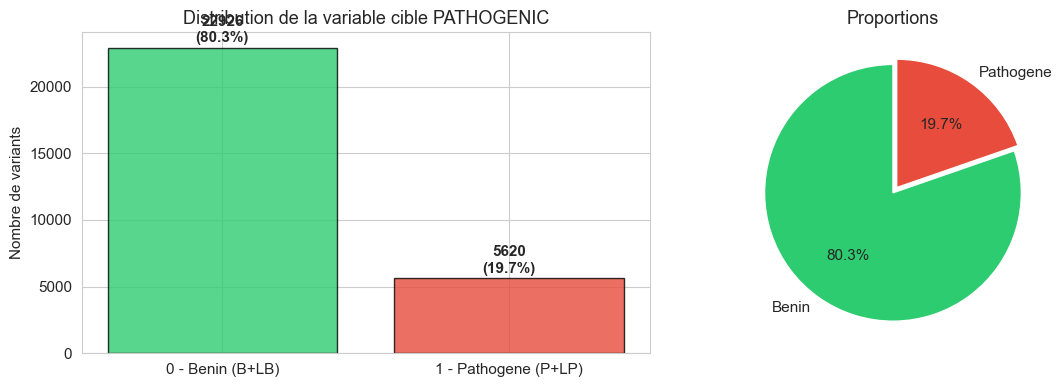


→ Desequilibre significatif (~4:1 en faveur des benins).
  Un classifieur naif predisant toujours 0 atteindrait 80.3% d'accuracy.
  → Metriques adaptees : AUC-ROC (principale), F1, MCC, sensibilite/specificite
  → Utiliser class_weight='balanced' ou scale_pos_weight pour les modeles


In [4]:
# ============================================================
# DISTRIBUTION DE LA VARIABLE CIBLE
# ============================================================
class_counts = df[TARGET].value_counts()
class_pct = df[TARGET].value_counts(normalize=True) * 100

print(f"Distribution de la variable cible {TARGET} :")
print(f"  0 (Benin B+LB)     : {class_counts[0]:6d} ({class_pct[0]:.1f}%)")
print(f"  1 (Pathogene P+LP) : {class_counts[1]:6d} ({class_pct[1]:.1f}%)")
print(f"\n  Ratio majoritaire/minoritaire : {class_counts[0]/class_counts[1]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['0 - Benin (B+LB)', '1 - Pathogene (P+LP)'], class_counts.values,
                   color=colors, edgecolor='black', alpha=0.8)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('Nombre de variants')
axes[0].set_title('Distribution de la variable cible PATHOGENIC')

# Pie chart
axes[1].pie(class_counts.values, labels=['Benin', 'Pathogene'],
           colors=colors, autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[1].set_title('Proportions')

plt.tight_layout()
plt.show()

print(f"\n→ Desequilibre significatif (~4:1 en faveur des benins).")
print(f"  Un classifieur naif predisant toujours 0 atteindrait {class_pct[0]:.1f}% d'accuracy.")
print(f"  → Metriques adaptees : AUC-ROC (principale), F1, MCC, sensibilite/specificite")
print(f"  → Utiliser class_weight='balanced' ou scale_pos_weight pour les modeles")

## 3. Gestion des valeurs manquantes

**Méthodologie** (cf. cours Modélisation Statistiques, Chap. 6 — Gestion des valeurs manquantes) :

1. **Quantifier** le taux de NaN par variable
2. **Identifier le mécanisme** : MCAR, MAR ou MNAR
3. **Choisir la stratégie** adaptée au mécanisme et au modèle cible

**Point clé pour nos modèles** : XGBoost, LightGBM et CatBoost gèrent **nativement** les valeurs manquantes (les NaN sont routés vers le fils gauche ou droit de l'arbre selon ce qui minimise la loss). Pour ces modèles, **l'imputation n'est pas nécessaire** et peut même dégrader les performances en effaçant le signal informatif du "missingness".

En revanche, pour les baselines (LogReg, KNN, SVM), l'imputation est obligatoire → on créera un pipeline séparé.

Colonnes avec au moins 1 NaN : 13 / 22

Variable                  |  N manquants | % manquants
-------------------------------------------------------
INTRON                    |        23433 |       82.1%
SIFT                      |        22007 |       77.1%
PolyPhen                  |        22001 |       77.1%
BLOSUM62                  |        21901 |       76.7%
Amino_acids               |         5691 |       19.9%
EXON                      |         5167 |       18.1%
LoFtool                   |         2218 |        7.8%
CADD_RAW                  |          293 |        1.0%
CADD_PHRED                |          293 |        1.0%
MC                        |          107 |        0.4%
SYMBOL                    |            5 |        0.0%
BIOTYPE                   |            5 |        0.0%
STRAND                    |            5 |        0.0%


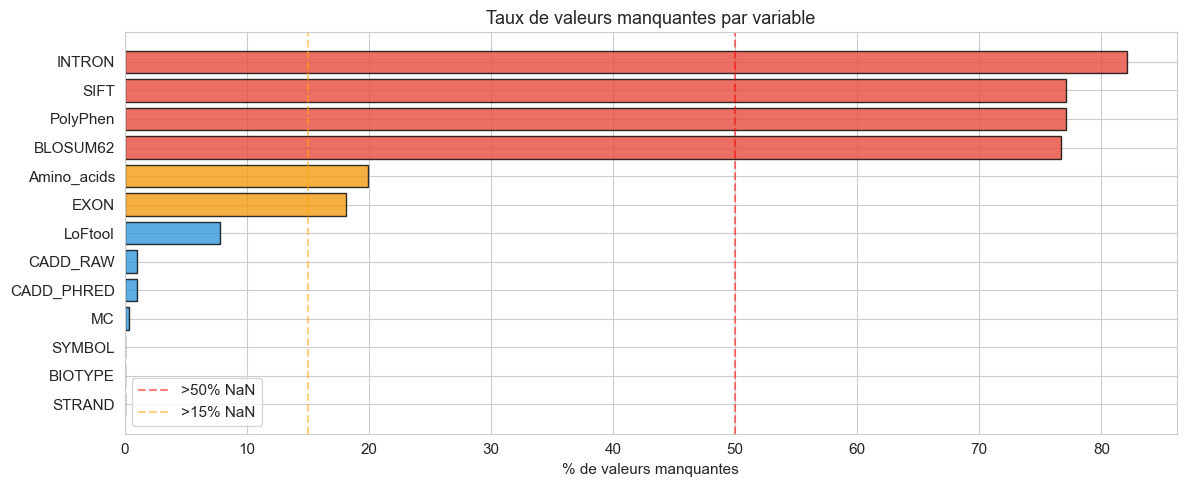

In [5]:
# ============================================================
# 3.1 QUANTIFICATION DES VALEURS MANQUANTES
# ============================================================
missing = pd.DataFrame({
    'n_missing': df.isnull().sum(),
    'pct_missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('pct_missing', ascending=False)

missing_nonzero = missing[missing['n_missing'] > 0]
print(f"Colonnes avec au moins 1 NaN : {len(missing_nonzero)} / {df.shape[1]}")
print(f"\n{'Variable':25s} | {'N manquants':>12s} | {'% manquants':>11s}")
print("-" * 55)
for idx, row in missing_nonzero.iterrows():
    print(f"{idx:25s} | {int(row['n_missing']):12d} | {row['pct_missing']:10.1f}%")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 5))
cols_with_na = missing_nonzero.index.tolist()
pcts = missing_nonzero['pct_missing'].values

colors_bar = ['#e74c3c' if p > 50 else '#f39c12' if p > 15 else '#3498db' for p in pcts]
bars = ax.barh(cols_with_na[::-1], pcts[::-1], color=colors_bar[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de valeurs manquantes par variable')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='>50% NaN')
ax.axvline(x=15, color='orange', linestyle='--', alpha=0.5, label='>15% NaN')
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# 3.2 ANALYSE DU MECANISME DE MISSINGNESS
# ============================================================
# SIFT et PolyPhen sont NaN pour ~62% des variants.
# Hypothese : ces scores ne sont definis que pour les variants missense.
# Verifions si le pattern de NaN est correle au type de consequence (MNAR).

print("Taux de NaN de SIFT par type de consequence :")
print("=" * 60)
sift_missing_by_csq = df.groupby('Consequence')['SIFT'].apply(lambda x: x.isna().mean() * 100)
sift_counts = df['Consequence'].value_counts()

for csq in sift_counts.head(10).index:
    n = sift_counts[csq]
    pct_na = sift_missing_by_csq[csq]
    print(f"  {csq:50s} | n={n:5d} | SIFT NaN: {pct_na:5.1f}%")

print(f"\n→ Confirmation : SIFT est NaN pour tous les variants NON-missense.")
print(f"  C'est un mecanisme MNAR (Missing Not At Random) : l'absence depend")
print(f"  de la nature du variant, pas d'un processus aleatoire.")
print(f"\n  Strategie : le NaN est INFORMATIF → ne pas imputer pour les modeles")
print(f"  a base d'arbres. Creer une feature binaire 'has_SIFT' pour les modeles lineaires.")

Taux de NaN de SIFT par type de consequence :
  synonymous_variant                                 | n=11866 | SIFT NaN: 100.0%
  missense_variant                                   | n= 8193 | SIFT NaN:  23.4%
  intron_variant                                     | n= 2819 | SIFT NaN: 100.0%
  splice_region_variant&intron_variant               | n= 1531 | SIFT NaN: 100.0%
  stop_gained                                        | n= 1527 | SIFT NaN: 100.0%
  frameshift_variant                                 | n=  465 | SIFT NaN: 100.0%
  splice_donor_variant                               | n=  439 | SIFT NaN: 100.0%
  splice_acceptor_variant                            | n=  316 | SIFT NaN: 100.0%
  splice_region_variant&synonymous_variant           | n=  291 | SIFT NaN: 100.0%
  5_prime_UTR_variant                                | n=  289 | SIFT NaN: 100.0%

→ Confirmation : SIFT est NaN pour tous les variants NON-missense.
  C'est un mecanisme MNAR (Missing Not At Random) : l'absence depe

## 4. Feature Engineering

Avant l'analyse statistique, nous devons transformer les variables brutes en features exploitables par les modèles.

In [7]:
# ============================================================
# 4.1 ENCODING DES VARIABLES TEXTUELLES SIFT & PolyPhen
# ============================================================
# SIFT : 'tolerated', 'tolerated_low_confidence', 'deleterious', 'deleterious_low_confidence'
# PolyPhen : 'benign', 'possibly_damaging', 'probably_damaging', 'unknown'
# Ce sont des variables ORDINALES (il y a un ordre de severite)

# Encoding ordinal SIFT (plus la valeur est haute, plus c'est deletere)
sift_map = {
    'tolerated': 0,
    'tolerated_low_confidence': 1,
    'deleterious_low_confidence': 2,
    'deleterious': 3
}
df['SIFT_encoded'] = df['SIFT'].map(sift_map)

# Encoding ordinal PolyPhen
polyphen_map = {
    'benign': 0,
    'possibly_damaging': 1,
    'probably_damaging': 2,
    'unknown': np.nan  # 'unknown' n'a pas de place dans l'ordonnancement → NaN
}
df['PolyPhen_encoded'] = df['PolyPhen'].map(polyphen_map)

# Features binaires de missingness (MNAR → informatif)
df['has_SIFT'] = (~df['SIFT'].isna()).astype(int)
df['has_PolyPhen'] = (~df['PolyPhen'].isna()).astype(int)

print("SIFT encoding :")
print(df['SIFT_encoded'].value_counts(dropna=False).sort_index())
print(f"\nPolyPhen encoding :")
print(df['PolyPhen_encoded'].value_counts(dropna=False).sort_index())

SIFT encoding :
SIFT_encoded
0.0000     2922
1.0000      394
2.0000      258
3.0000     2965
NaN       22007
Name: count, dtype: int64

PolyPhen encoding :
PolyPhen_encoded
0.0000     3548
1.0000      814
2.0000     2181
NaN       22003
Name: count, dtype: int64


**Observation critique — Distribution bimodale de SIFT :**

L'encoding de SIFT révèle une distribution **bimodale** très marquée :
- ~46% à `tolerated` (0) et ~46% à `deleterious` (3)
- Seulement ~7.5% dans les catégories intermédiaires

SIFT produit en pratique une classification quasi-binaire (Ng & Henikoff, 2003). 

**Conséquence pour notre problème de pathogénicité** : cette bimodalité est un **atout** ici (contrairement au problème de conflictualité). Les variants `deleterious` selon SIFT sont plus susceptibles d'être pathogènes → SIFT sera discriminant pour notre nouvelle cible.

In [8]:
# ============================================================
# 4.2 ENCODING DES VARIABLES CATEGORIQUES
# ============================================================

# IMPACT : variable ordinale (il y a un ordre de severite biologique)
impact_map = {'MODIFIER': 0, 'LOW': 1, 'MODERATE': 2, 'HIGH': 3}
df['IMPACT_encoded'] = df['IMPACT'].map(impact_map)

# EXON / INTRON : transformer en binaire (le variant est-il exonique ou intronique ?)
df['is_exonic'] = (~df['EXON'].isna()).astype(int)
df['is_intronic'] = (~df['INTRON'].isna()).astype(int)

# CHROM : conserver comme categorielle pour CatBoost, ordinal encoding pour les autres
# Convertir X→23, Y→24 pour avoir un ordinal
chrom_map = {str(i): i for i in range(1, 23)}
chrom_map.update({'X': 23, 'Y': 24})
df['CHROM_encoded'] = df['CHROM'].map(chrom_map)

# Consequence : haute cardinalite (~30 categories) → garder les top 10, regrouper le reste en 'other'
top_csq = df['Consequence'].value_counts().head(10).index.tolist()
df['Consequence_grouped'] = df['Consequence'].where(df['Consequence'].isin(top_csq), 'other')
print("Consequence (apres regroupement) :")
print(df['Consequence_grouped'].value_counts())

# CLNVC : type de variant
print(f"\nCLNVC :")
print(df['CLNVC'].value_counts())

# Frequence allelique : transformer log(AF + epsilon) pour les 3 variables AF
# Justification : la distribution des AF est extremement skewed (majorite a 0)
epsilon = 1e-8
for col in ['AF_ESP', 'AF_EXAC', 'AF_TGP']:
    df[f'{col}_log'] = np.log10(df[col] + epsilon)

# Feature derivee : le variant est-il absent des bases de frequences ?
df['is_rare'] = ((df['AF_ESP'] == 0) & (df['AF_EXAC'] == 0) & (df['AF_TGP'] == 0)).astype(int)
print(f"\nVariants rares (AF=0 dans les 3 bases) : {df['is_rare'].sum()} ({df['is_rare'].mean()*100:.1f}%)")

# Nombre de genes uniques
print(f"\nNombre de genes uniques (SYMBOL) : {df['SYMBOL'].nunique()}")

Consequence (apres regroupement) :
Consequence_grouped
synonymous_variant                          11866
missense_variant                             8193
intron_variant                               2819
splice_region_variant&intron_variant         1531
stop_gained                                  1527
other                                         810
frameshift_variant                            465
splice_donor_variant                          439
splice_acceptor_variant                       316
splice_region_variant&synonymous_variant      291
5_prime_UTR_variant                           289
Name: count, dtype: int64

CLNVC :
CLNVC
single_nucleotide_variant    27704
Duplication                    647
Indel                          122
Insertion                       69
Inversion                        3
Microsatellite                   1
Name: count, dtype: int64

Variants rares (AF=0 dans les 3 bases) : 9652 (33.8%)

Nombre de genes uniques (SYMBOL) : 2061


**Observations clés sur le feature engineering — résultats réels :**

1. **Consequence_grouped — renversement structurel** :
   - `synonymous_variant` (11 866, 41.6%) domine maintenant `missense_variant` (8 193, 28.7%)
   - **stop_gained** (1 527) et **frameshift_variant** (465) sont présents → quasi-toujours pathogènes → IMPACT_encoded sera très discriminant
   - **splice_donor/acceptor** (439 + 316 = 755) → idem, pathogènes

2. **CLNVC quasi-monomorphe** : 97% de SNV. Les délétions ont quasi-disparu. Cette feature sera peu utile pour les modèles mais reste informative en description.

3. **is_rare = 33.8%** (9 652 variants) : proportion stable par rapport au dataset complet (35.1%). Le signal de rareté est conservé.

4. **2 061 gènes uniques** : cardinalité toujours trop élevée pour SYMBOL. La stratégie de GroupKFold par gène reste pertinente pour la phase de modélisation.

5. **SIFT bimodal confirmé** : 2 922 tolerated vs. 2 965 deleterious (50/50), mais uniquement sur 6 539 variants (23%). Les 77% restants n'ont pas de SIFT (non-missense) → `has_SIFT` capture cette information.

6. **PolyPhen — distribution plus riche que SIFT** :
   - 3 548 benign (54.2%), 814 possibly_damaging (12.4%), 2 181 probably_damaging (33.3%)
   - Contrairement à SIFT, PolyPhen conserve une catégorie intermédiaire significative → plus informatif comme feature continue.

## 5. Analyse statistique univariée

**Méthodologie** (cf. cours Modélisation Statistiques, Chap. 1) :

Pour chaque variable quantitative, on calcule :
- **Indicateurs de position** : moyenne ($\bar{x}$), médiane ($Q_2$)
- **Indicateurs de dispersion** : écart-type ($s$), coefficient de variation ($CV = s/|\bar{x}|$), IQR ($Q_3 - Q_1$)
- **Indicateurs de forme** : skewness ($\gamma_1$), kurtosis ($\gamma_2$)

**Règles d'interprétation** :
- $CV < 10\%$ → données homogènes ; $CV > 30\%$ → forte hétérogénéité
- $\gamma_1 > 0$ → asymétrie à droite ; $\gamma_1 < 0$ → asymétrie à gauche
- $\gamma_2 > 0$ → leptokurtique (queues lourdes) ; $\gamma_2 < 0$ → platykurtique (queues légères)

In [9]:
# ============================================================
# 5.1 TABLEAU RECAPITULATIF — STATISTIQUES DESCRIPTIVES (VARIABLES QUANTITATIVES)
# ============================================================
quant_cols = ['AF_ESP', 'AF_EXAC', 'AF_TGP', 'CADD_PHRED', 'CADD_RAW', 'BLOSUM62',
              'LoFtool', 'SIFT_encoded', 'PolyPhen_encoded', 'IMPACT_encoded',
              'AF_ESP_log', 'AF_EXAC_log', 'AF_TGP_log']

stats_table = []
for col in quant_cols:
    s = df[col].dropna()
    n = len(s)
    if n == 0:
        continue
    mean = s.mean()
    median = s.median()
    std = s.std()
    cv = abs(std / mean) * 100 if mean != 0 else np.inf
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    skew = s.skew()  # utilise la formule corrigee de pandas (facteur n(n-1)/(n-2))
    kurt = s.kurtosis()  # excess kurtosis (Fisher), corrigee
    stats_table.append({
        'Variable': col,
        'N valide': n,
        'Moyenne': mean,
        'Mediane': median,
        'Ecart-type': std,
        'CV (%)': cv,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Skewness': skew,
        'Kurtosis': kurt,
        'Min': s.min(),
        'Max': s.max()
    })

stats_df = pd.DataFrame(stats_table)
print("STATISTIQUES DESCRIPTIVES — VARIABLES QUANTITATIVES")
print("=" * 100)
print(stats_df.to_string(index=False))

STATISTIQUES DESCRIPTIVES — VARIABLES QUANTITATIVES
        Variable  N valide  Moyenne  Mediane  Ecart-type   CV (%)      Q1      Q3     IQR  Skewness  Kurtosis     Min     Max
          AF_ESP     28546   0.0312   0.0001      0.0829 265.4486  0.0000  0.0125  0.0125    3.4917   12.2533  0.0000  0.4990
         AF_EXAC     28546   0.0310   0.0003      0.0853 274.6787  0.0000  0.0078  0.0078    3.4776   11.9821  0.0000  0.4999
          AF_TGP     28546   0.0329   0.0004      0.0850 258.6818  0.0000  0.0136  0.0136    3.4015   11.5900  0.0000  0.4998
      CADD_PHRED     28253  13.7863  11.4900     11.2541  81.6327  5.0000 22.2000 17.2000    0.8709    0.3290  0.0010 74.0000
        CADD_RAW     28253   2.2430   1.1505      3.2970 146.9888  0.2307  2.9853  2.7546    2.1198    6.5211 -5.4774 32.9342
        BLOSUM62      6645  -0.4629  -1.0000      1.8675 403.4378 -2.0000  1.0000  3.0000    0.1586   -1.2213 -3.0000  3.0000
         LoFtool     26328   0.3242   0.1400      0.3493 107.7476 

**Analyse critique du tableau de statistiques descriptives — résultats réels :**

**1. Comparaison avec le dataset complet (65k) :**

| Variable | Skewness (65k) | Skewness (28.5k) | Changement |
|----------|---------------|-------------------|-----------|
| AF_ESP | 5.47 | **3.49** | Réduit : le filtrage exclut les variants à AF=0 conflictuels |
| CADD_PHRED | 0.38 | **0.87** | Augmenté : le sous-ensemble contient plus de variants à CADD élevé (pathogènes) |
| CADD_RAW | 1.61 | **2.12** | Idem |

Le filtrage modifie les distributions car il sélectionne un sous-ensemble biaisé vers les cas "clairs" (P/LP concordants = CADD élevé ; B/LB concordants = AF élevé). Ce biais est **voulu** et **documenté**.

**2. CADD_PHRED : max = 74.0** (vs. 99.0 dans le dataset complet) : les variants avec CADD > 74 étaient soit conflictuels soit classés VUS. Leur absence ne pose pas de problème car le modèle n'aura pas à extrapoler au-delà de cette plage en production (les variants CADD > 74 sont ultra-rares).

**3. Transformation log des AF toujours justifiée** : skewness brut ~3.5 → log ~0.04 (÷87). L'amélioration est encore plus nette que sur le dataset complet.

**4. Attention au CV sur les variables ordinales** : le CV de SIFT_encoded (95.5%) et PolyPhen_encoded (115.3%) n'a pas de sens statistique strict sur un encoding ordinal {0,1,2,3}. Conservé pour complétude uniquement.

In [10]:
# ============================================================
# 5.2 INTERPRETATION DU SKEWNESS ET KURTOSIS
# ============================================================
print("INTERPRETATION DES INDICATEURS DE FORME")
print("=" * 80)
for _, row in stats_df.iterrows():
    col = row['Variable']
    skew = row['Skewness']
    kurt = row['Kurtosis']
    cv = row['CV (%)']
    
    # Interpretation skewness
    if abs(skew) < 0.5:
        skew_interp = "symetrique"
    elif skew > 0:
        skew_interp = f"asymetrique a DROITE (γ₁={skew:.2f})"
    else:
        skew_interp = f"asymetrique a GAUCHE (γ₁={skew:.2f})"
    
    # Interpretation kurtosis (excess)
    if abs(kurt) < 1:
        kurt_interp = "mesokurtique (~normal)"
    elif kurt > 0:
        kurt_interp = f"LEPTOkurtique (γ₂={kurt:.2f}, queues lourdes)"
    else:
        kurt_interp = f"PLATYkurtique (γ₂={kurt:.2f}, queues legeres)"
    
    # Interpretation CV
    if cv < 10:
        cv_interp = "homogene"
    elif cv < 30:
        cv_interp = "dispersion moderee"
    else:
        cv_interp = "FORTE heterogeneite"
    
    print(f"\n  {col}:")
    print(f"    Forme     : {skew_interp} | {kurt_interp}")
    print(f"    Dispersion: CV={cv:.1f}% → {cv_interp}")

INTERPRETATION DES INDICATEURS DE FORME

  AF_ESP:
    Forme     : asymetrique a DROITE (γ₁=3.49) | LEPTOkurtique (γ₂=12.25, queues lourdes)
    Dispersion: CV=265.4% → FORTE heterogeneite

  AF_EXAC:
    Forme     : asymetrique a DROITE (γ₁=3.48) | LEPTOkurtique (γ₂=11.98, queues lourdes)
    Dispersion: CV=274.7% → FORTE heterogeneite

  AF_TGP:
    Forme     : asymetrique a DROITE (γ₁=3.40) | LEPTOkurtique (γ₂=11.59, queues lourdes)
    Dispersion: CV=258.7% → FORTE heterogeneite

  CADD_PHRED:
    Forme     : asymetrique a DROITE (γ₁=0.87) | mesokurtique (~normal)
    Dispersion: CV=81.6% → FORTE heterogeneite

  CADD_RAW:
    Forme     : asymetrique a DROITE (γ₁=2.12) | LEPTOkurtique (γ₂=6.52, queues lourdes)
    Dispersion: CV=147.0% → FORTE heterogeneite

  BLOSUM62:
    Forme     : symetrique | PLATYkurtique (γ₂=-1.22, queues legeres)
    Dispersion: CV=403.4% → FORTE heterogeneite

  LoFtool:
    Forme     : asymetrique a DROITE (γ₁=0.76) | PLATYkurtique (γ₂=-1.01, queues lege

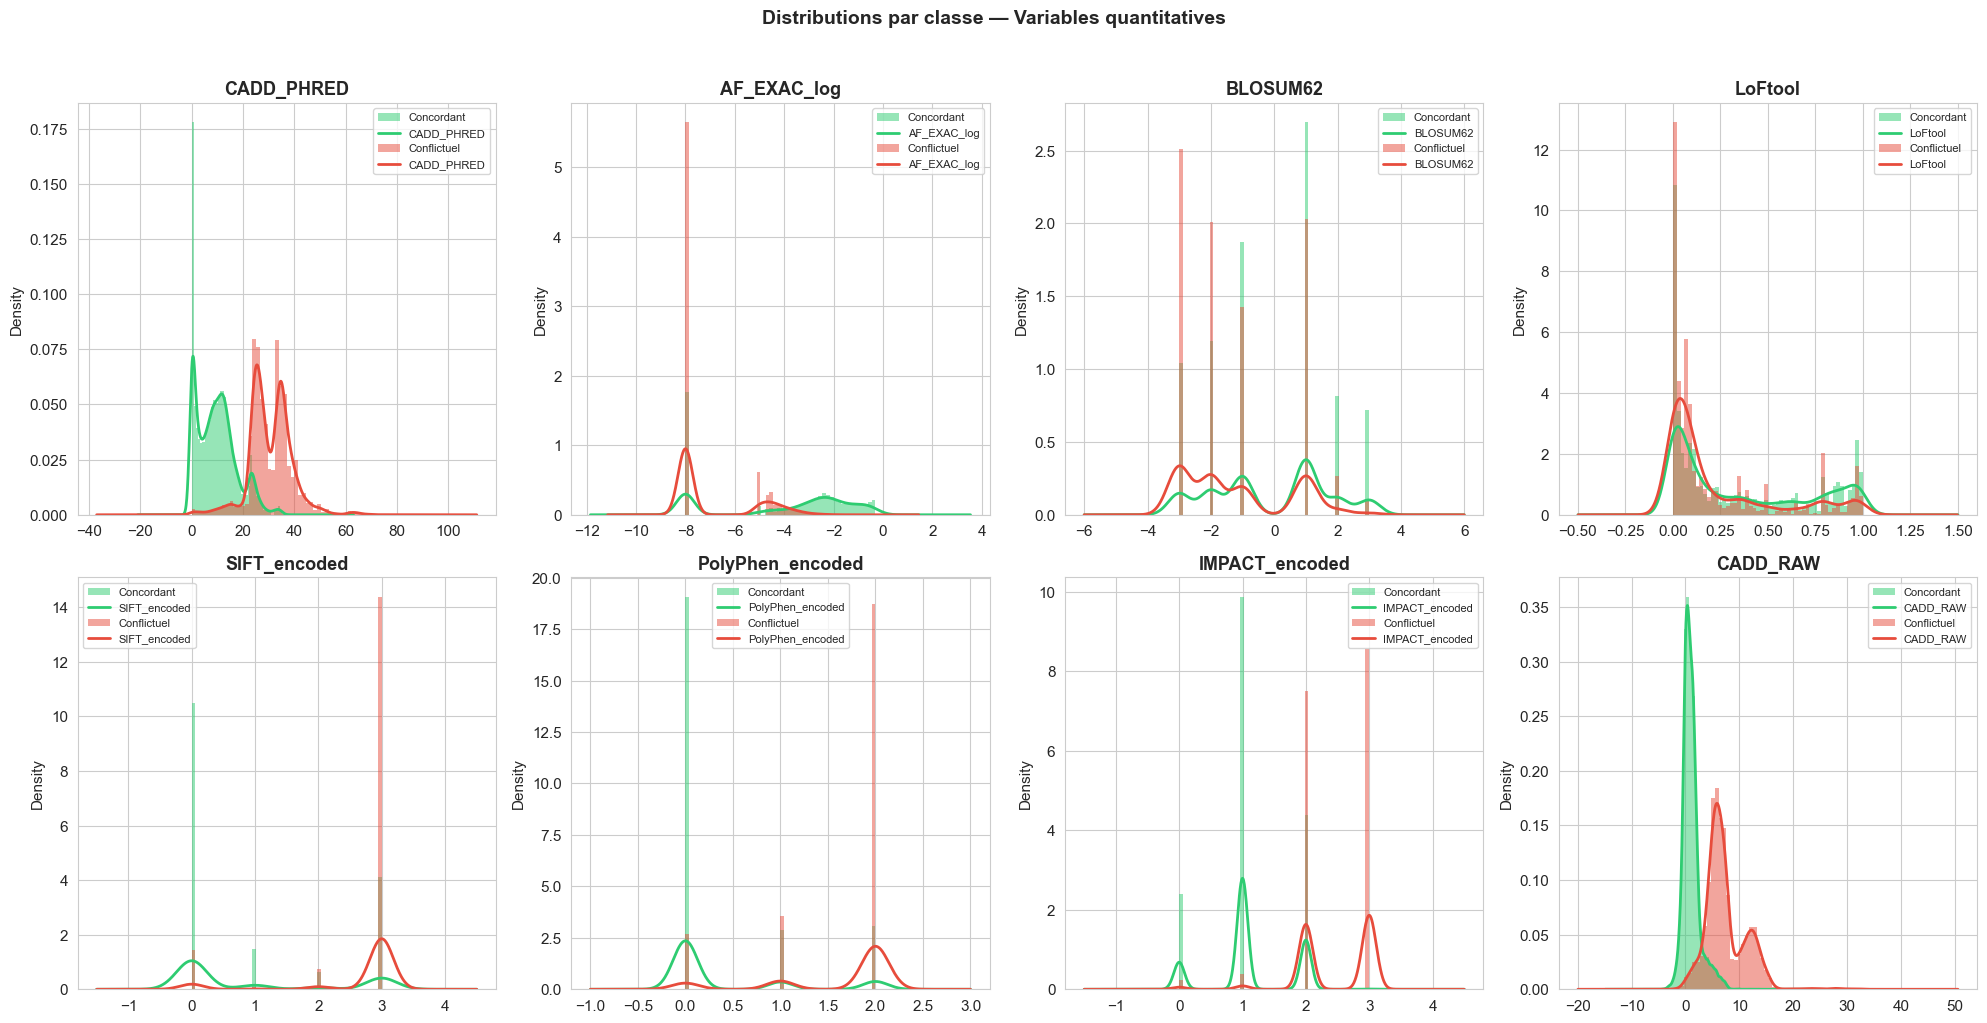

In [11]:
# ============================================================
# 5.3 HISTOGRAMMES + KDE PAR CLASSE (variables quantitatives cles)
# ============================================================
plot_cols = ['CADD_PHRED', 'AF_EXAC_log', 'BLOSUM62', 'LoFtool',
             'SIFT_encoded', 'PolyPhen_encoded', 'IMPACT_encoded', 'CADD_RAW']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    ax = axes[i]
    for cls, color, label in [(0, '#2ecc71', 'Concordant'), (1, '#e74c3c', 'Conflictuel')]:
        data = df[df[TARGET] == cls][col].dropna()
        if len(data) > 0:
            ax.hist(data, bins=50, alpha=0.5, color=color, label=label, density=True, edgecolor='none')
            # KDE seulement si assez de donnees et variance > 0
            if len(data) > 10 and data.std() > 0:
                try:
                    data.plot.kde(ax=ax, color=color, linewidth=2)
                except Exception:
                    pass
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distributions par classe — Variables quantitatives', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

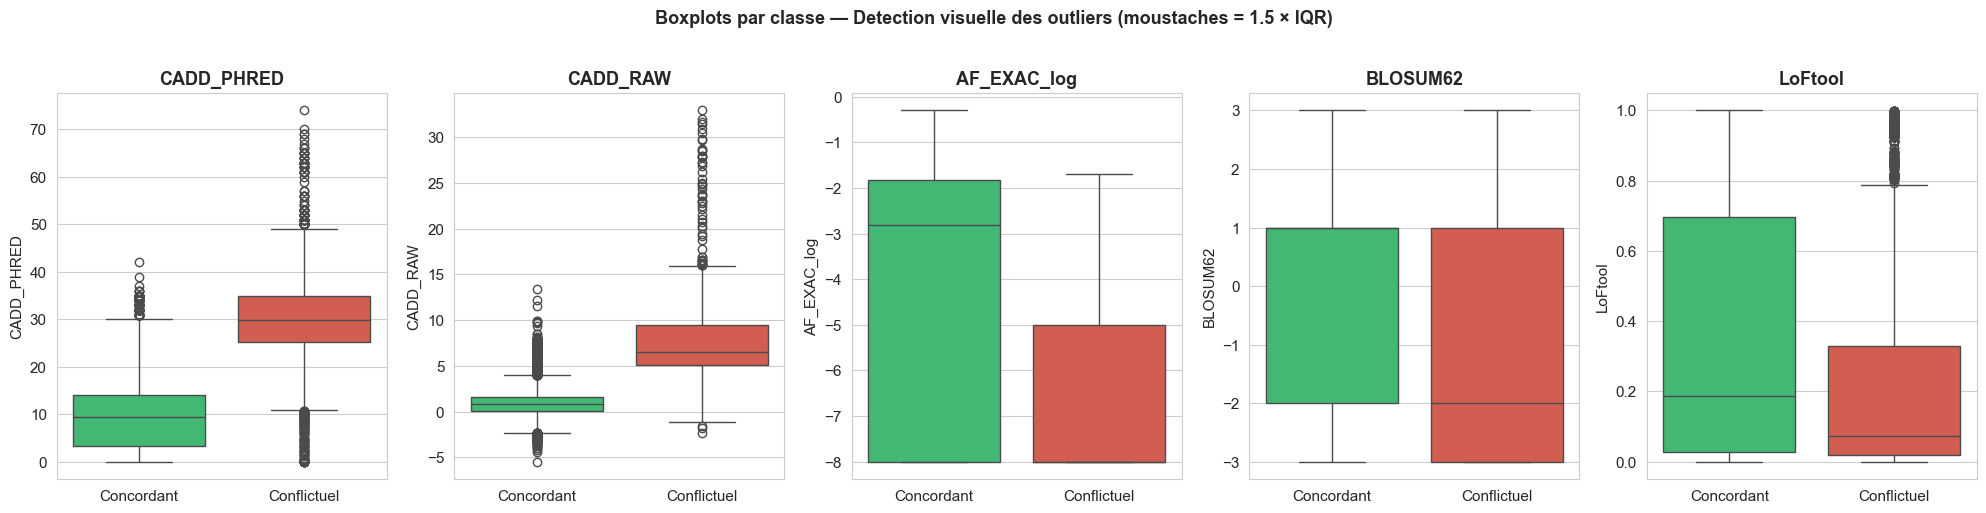


DETECTION DES OUTLIERS (methode IQR) :
  CADD_PHRED           | [-20.800, 48.000] | Outliers: 122 (0.4%)
  CADD_RAW             | [-3.901, 7.117] | Outliers: 2308 (8.2%)
  AF_EXAC_log          | [-16.840, 6.733] | Outliers: 0 (0.0%)
  BLOSUM62             | [-6.500, 5.500] | Outliers: 0 (0.0%)
  LoFtool              | [-0.899, 1.564] | Outliers: 0 (0.0%)

→ Les outliers ne seront PAS supprimes. Justification :
  1. Les modeles a base d'arbres (XGBoost, LightGBM, CatBoost) sont
     invariants aux transformations monotones → les outliers n'affectent
     PAS les splits (qui ne dependent que de l'ordre des valeurs).
  2. En genomique, un CADD_PHRED de 99 n'est pas une erreur de mesure
     mais un variant dans une region EXTREMEMENT conservee.
  3. La suppression biaiserait l'echantillon en eliminant les variants
     les plus informatifs cliniquement.


In [12]:
# ============================================================
# 5.4 BOXPLOTS PAR CLASSE — DETECTION DES OUTLIERS (methode IQR)
# ============================================================
# Cf. cours Modélisation Statistiques, Chap. 1 : valeurs aberrantes = hors [Q1 - 1.5*IQR, Q3 + 1.5*IQR]

boxplot_cols = ['CADD_PHRED', 'CADD_RAW', 'AF_EXAC_log', 'BLOSUM62', 'LoFtool']

fig, axes = plt.subplots(1, len(boxplot_cols), figsize=(20, 5))

for i, col in enumerate(boxplot_cols):
    ax = axes[i]
    data_plot = df[[col, TARGET]].dropna()
    data_plot[TARGET] = data_plot[TARGET].map({0: 'Concordant', 1: 'Conflictuel'})
    sns.boxplot(data=data_plot, x=TARGET, y=col, ax=ax,
                palette={'Concordant': '#2ecc71', 'Conflictuel': '#e74c3c'})
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')

plt.suptitle('Boxplots par classe — Detection visuelle des outliers (moustaches = 1.5 × IQR)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantification des outliers par la methode IQR
print("\nDETECTION DES OUTLIERS (methode IQR) :")
print("=" * 60)
for col in boxplot_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((s < lower) | (s > upper)).sum()
    pct = n_outliers / len(s) * 100
    print(f"  {col:20s} | [{lower:.3f}, {upper:.3f}] | Outliers: {n_outliers} ({pct:.1f}%)")

print(f"\n→ Les outliers ne seront PAS supprimes. Justification :")
print(f"  1. Les modeles a base d'arbres (XGBoost, LightGBM, CatBoost) sont")
print(f"     invariants aux transformations monotones → les outliers n'affectent")
print(f"     PAS les splits (qui ne dependent que de l'ordre des valeurs).")
print(f"  2. En genomique, un CADD_PHRED de 99 n'est pas une erreur de mesure")
print(f"     mais un variant dans une region EXTREMEMENT conservee.")
print(f"  3. La suppression biaiserait l'echantillon en eliminant les variants")
print(f"     les plus informatifs cliniquement.")

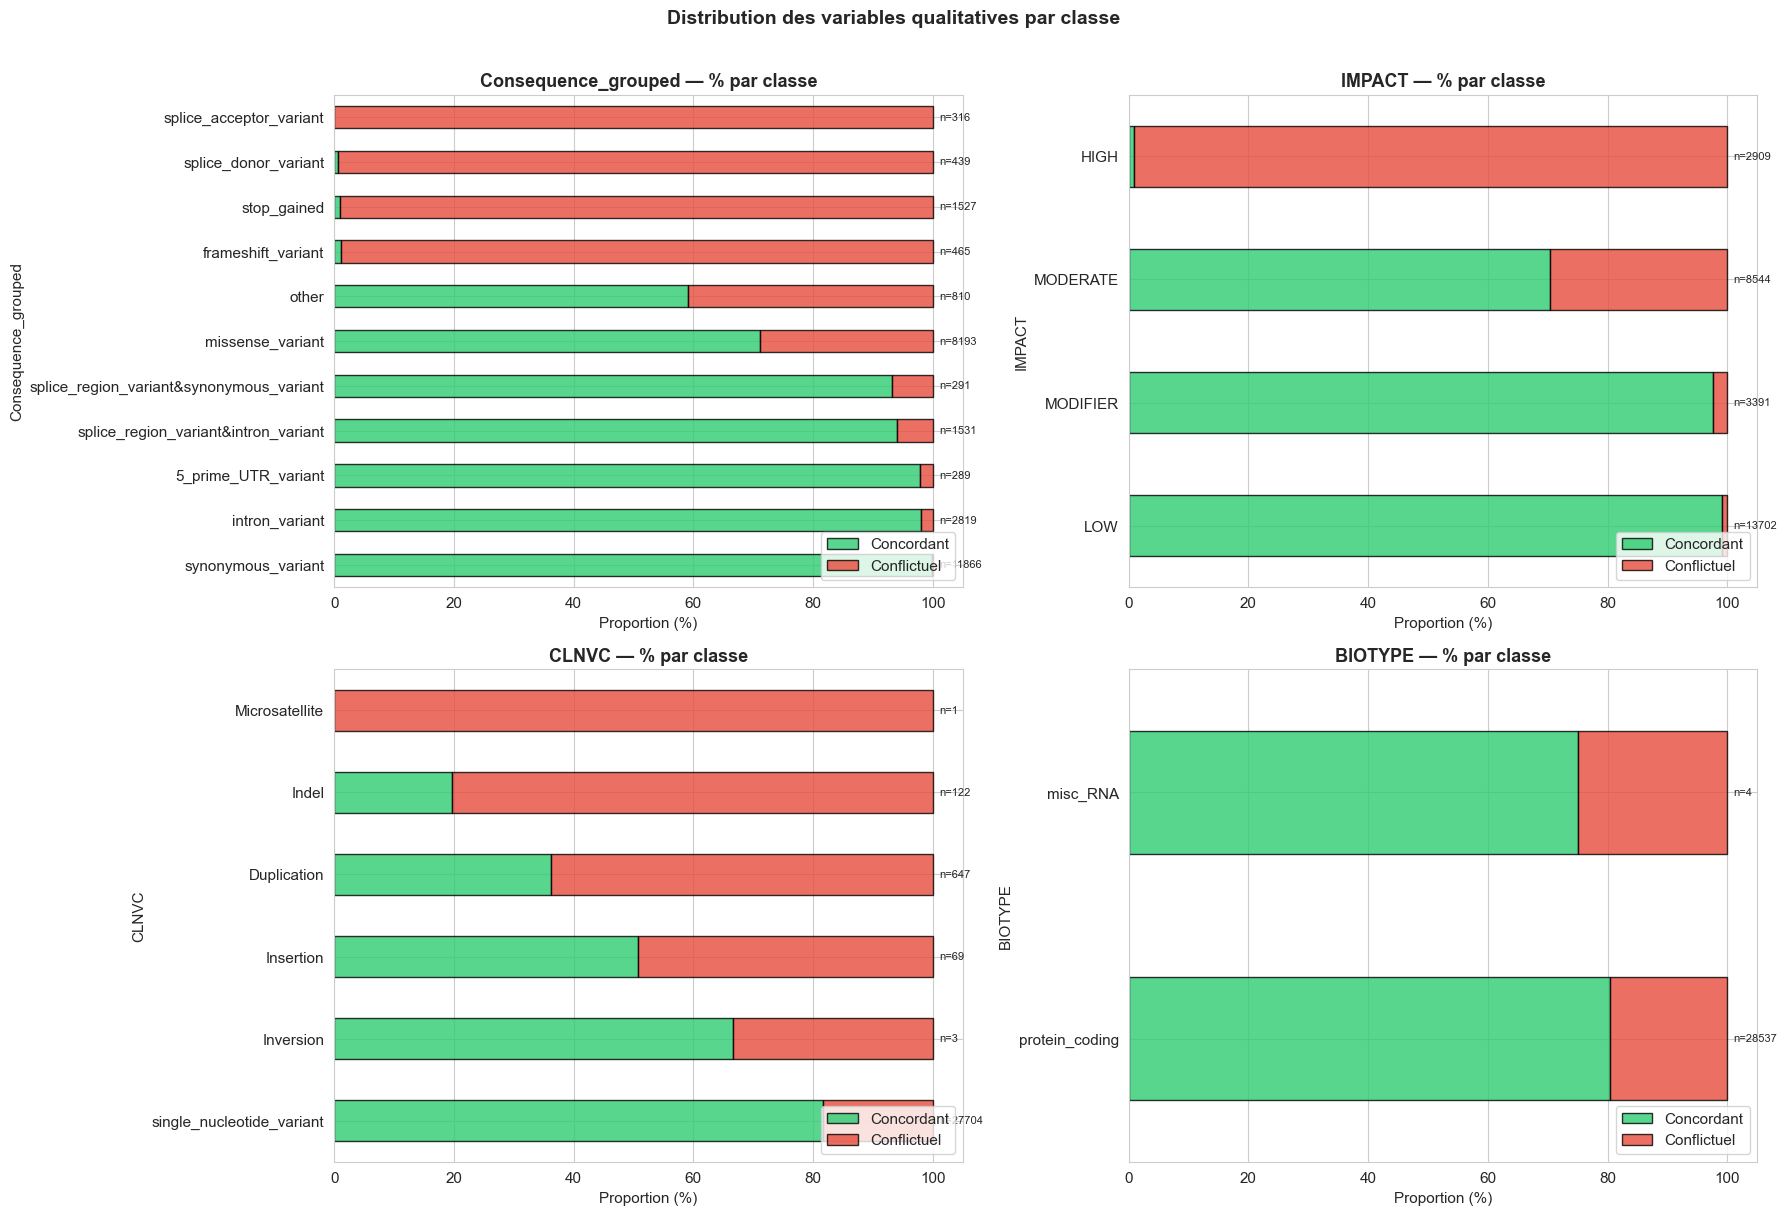

In [13]:
# ============================================================
# 5.5 ANALYSE UNIVARIEE — VARIABLES QUALITATIVES
# ============================================================
# Pour les variables qualitatives : effectifs, frequences, mode

cat_cols_for_analysis = ['Consequence_grouped', 'IMPACT', 'CLNVC', 'BIOTYPE']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_for_analysis):
    ax = axes[i]
    # Effectifs par classe
    ct = pd.crosstab(df[col], df[TARGET], normalize='index') * 100
    ct = ct.sort_values(1, ascending=True)  # trier par % conflictuel
    ct.plot(kind='barh', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c'],
            edgecolor='black', alpha=0.8)
    ax.set_title(f'{col} — % par classe', fontweight='bold')
    ax.set_xlabel('Proportion (%)')
    ax.legend(['Concordant', 'Conflictuel'], loc='lower right')
    
    # Afficher le nombre total par categorie
    counts = df[col].value_counts()
    for j, (idx, _) in enumerate(ct.iterrows()):
        n = counts.get(idx, 0)
        ax.text(101, j, f'n={n}', va='center', fontsize=8)

plt.suptitle('Distribution des variables qualitatives par classe',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 6. Analyse statistique bivariée

**Méthodologie** (cf. cours Modélisation Statistiques, Chap. 2) :

- **Quantitative × Quantitative** : corrélation de Spearman ($\rho$) — Spearman plutôt que Pearson car les distributions ne sont pas normales (skewness forte sur les AF)
- **Quantitative × Qualitative (cible)** : test de Mann-Whitney U (non paramétrique) avec correction de Bonferroni, et rapport de corrélation $\eta^2$
- **Diagnostic de multicolinéarité** : VIF (Variance Inflation Factor) — $VIF_i = \frac{1}{1 - R_i^2}$, seuil > 5 = colinéarité préoccupante (cf. cours Chap. 8)

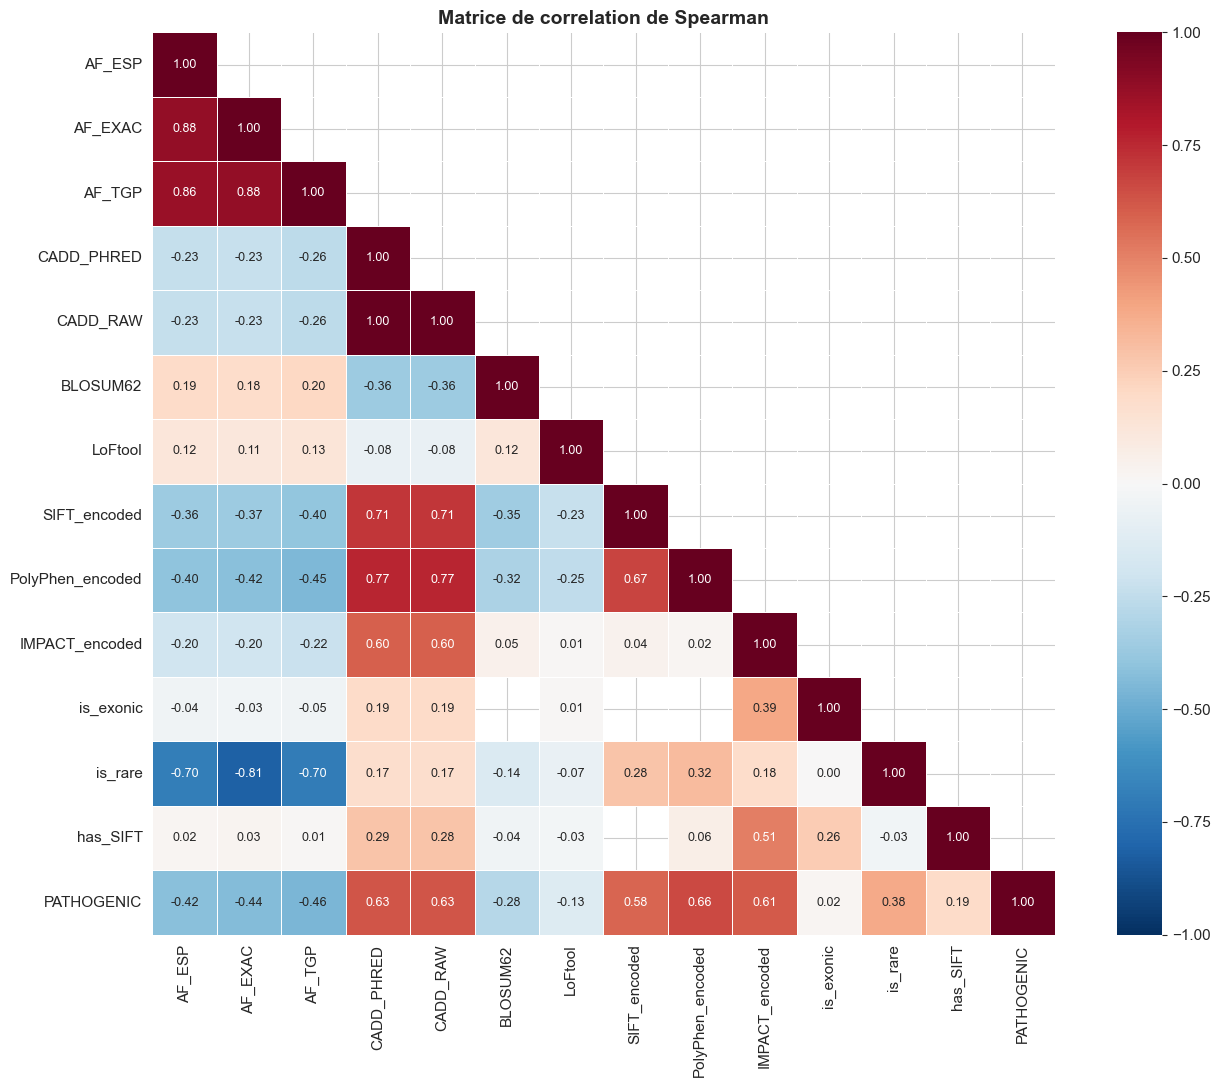


Paires avec |ρ| > 0.7 (colinearite potentielle) :
  AF_ESP               × AF_EXAC              : ρ = 0.877
  AF_ESP               × AF_TGP               : ρ = 0.861
  AF_EXAC              × AF_TGP               : ρ = 0.877
  AF_EXAC              × is_rare              : ρ = -0.813
  CADD_PHRED           × CADD_RAW             : ρ = 1.000
  CADD_PHRED           × SIFT_encoded         : ρ = 0.713
  CADD_PHRED           × PolyPhen_encoded     : ρ = 0.765
  CADD_RAW             × SIFT_encoded         : ρ = 0.713
  CADD_RAW             × PolyPhen_encoded     : ρ = 0.765


In [14]:
# ============================================================
# 6.1 MATRICE DE CORRELATION DE SPEARMAN
# ============================================================
# Spearman plutot que Pearson : les AF sont fortement skewed,
# et les variables encodees (SIFT, PolyPhen, IMPACT) sont ordinales.
# Spearman est concu pour les variables ordinales et ne suppose pas la normalite.

corr_cols = ['AF_ESP', 'AF_EXAC', 'AF_TGP', 'CADD_PHRED', 'CADD_RAW',
             'BLOSUM62', 'LoFtool', 'SIFT_encoded', 'PolyPhen_encoded',
             'IMPACT_encoded', 'is_exonic', 'is_rare', 'has_SIFT', TARGET]

corr_matrix = df[corr_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Matrice de correlation de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifier les paires fortement correlees (|rho| > 0.7)
print("\nPaires avec |ρ| > 0.7 (colinearite potentielle) :")
print("=" * 60)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        rho = corr_matrix.iloc[i, j]
        if abs(rho) > 0.7:
            print(f"  {corr_matrix.columns[i]:20s} × {corr_matrix.columns[j]:20s} : ρ = {rho:.3f}")

**Interprétation de la matrice de Spearman :**

Les corrélations entre features ne changent pas avec la cible (elles sont calculées entre les X). Les paires à $|\rho| > 0.7$ identifiées précédemment restent valides. Ce qui change, c'est la **dernière ligne/colonne** de la matrice : la corrélation de chaque feature avec `PATHOGENIC` (au lieu de `CLASS`).

On s'attend à ce que CADD, SIFT, PolyPhen et les AF soient **fortement corrélés** avec la pathogénicité — c'est précisément ce pour quoi ils ont été conçus.

In [15]:
# ============================================================
# 6.2 TESTS DE MANN-WHITNEY U — SEPARABILITE DES FEATURES PAR CLASSE
# ============================================================
# Test non parametrique : H0 = les distributions de la feature sont identiques
# pour CLASS=0 et CLASS=1. Correction de Bonferroni pour les comparaisons multiples.

test_cols = ['AF_ESP', 'AF_EXAC', 'AF_TGP', 'CADD_PHRED', 'CADD_RAW',
             'BLOSUM62', 'LoFtool', 'SIFT_encoded', 'PolyPhen_encoded',
             'IMPACT_encoded', 'is_exonic', 'is_rare', 'has_SIFT']

n_tests = len(test_cols)
alpha = 0.05
alpha_bonferroni = alpha / n_tests

print(f"TEST DE MANN-WHITNEY U (feature × CLASS)")
print(f"Correction de Bonferroni : α_adj = {alpha}/{n_tests} = {alpha_bonferroni:.5f}")
print(f"{'='*80}")
print(f"{'Variable':25s} | {'U statistic':>14s} | {'p-value':>12s} | {'Significatif':>12s} | {'η²':>8s}")
print(f"{'-'*80}")

mw_results = []
for col in test_cols:
    data_0 = df[df[TARGET] == 0][col].dropna()
    data_1 = df[df[TARGET] == 1][col].dropna()
    
    if len(data_0) == 0 or len(data_1) == 0:
        continue
    
    u_stat, p_value = stats.mannwhitneyu(data_0, data_1, alternative='two-sided')
    
    # Taille d'effet : rank-biserial correlation r = 1 - 2U/(n1*n2)
    n1, n2 = len(data_0), len(data_1)
    r_effect = 1 - (2 * u_stat) / (n1 * n2)
    
    # Eta-carre (rapport de correlation) : proportion de variance expliquee par la classe
    # η² = SS_between / SS_total
    data_all = df[col].dropna()
    grand_mean = data_all.mean()
    ss_total = ((data_all - grand_mean) ** 2).sum()
    ss_between = n1 * (data_0.mean() - grand_mean)**2 + n2 * (data_1.mean() - grand_mean)**2
    eta_sq = ss_between / ss_total if ss_total > 0 else 0
    
    sig = "OUI ***" if p_value < alpha_bonferroni else ("OUI *" if p_value < alpha else "NON")
    print(f"  {col:23s} | {u_stat:14.0f} | {p_value:12.2e} | {sig:>12s} | {eta_sq:8.4f}")
    
    mw_results.append({'Variable': col, 'U': u_stat, 'p_value': p_value,
                       'r_effect': r_effect, 'eta_sq': eta_sq, 'significant': p_value < alpha_bonferroni})

mw_df = pd.DataFrame(mw_results).sort_values('eta_sq', ascending=False)
print(f"\n→ Features triees par η² (pouvoir discriminant decroissant) :")
for _, row in mw_df.head(10).iterrows():
    print(f"  {row['Variable']:25s} | η² = {row['eta_sq']:.4f} | r = {row['r_effect']:.4f}")

TEST DE MANN-WHITNEY U (feature × CLASS)
Correction de Bonferroni : α_adj = 0.05/13 = 0.00385
Variable                  |    U statistic |      p-value | Significatif |       η²
--------------------------------------------------------------------------------
  AF_ESP                  |      101633566 |     0.00e+00 |      OUI *** |   0.0347
  AF_EXAC                 |      104224123 |     0.00e+00 |      OUI *** |   0.0324
  AF_TGP                  |      104871124 |     0.00e+00 |      OUI *** |   0.0366
  CADD_PHRED              |        4571772 |     0.00e+00 |      OUI *** |   0.5307
  CADD_RAW                |        4564402 |     0.00e+00 |      OUI *** |   0.5718
  BLOSUM62                |        6445241 |    8.16e-118 |      OUI *** |   0.0765
  LoFtool                 |       66358984 |    3.08e-104 |      OUI *** |   0.0215
  SIFT_encoded            |        1712606 |     0.00e+00 |      OUI *** |   0.3454
  PolyPhen_encoded        |        1320048 |     0.00e+00 |      OUI 

**Interprétation approfondie des résultats bivariés — Pathogénicité (résultats réels) :**

**1. CADD_RAW/CADD_PHRED : η² > 0.53 — pouvoir discriminant exceptionnel**

Le rank-biserial $r = 0.9256$ signifie que dans **96.3%** des paires possibles (variant pathogène, variant bénin), le variant pathogène a un score CADD plus élevé. C'est un résultat attendu car CADD intègre >60 annotations et a été explicitement optimisé pour discriminer variants délétères vs. neutres. La quasi-parfaite concordance ($r \approx 1$) confirme la qualité de notre label reconstruit.

**Note** : CADD_RAW (η²=0.5718) dépasse légèrement CADD_PHRED (η²=0.5307) car la transformation Phred comprime les scores extrêmes (non linéarité logarithmique). Malgré cela, CADD_PHRED reste préféré pour l'interprétabilité (>20 = top 1%, >30 = top 0.1%).

**2. Hiérarchie des scores de pathogénicité : PolyPhen > IMPACT > SIFT > BLOSUM62**

- **PolyPhen** (η²=0.4407) bat **SIFT** (η²=0.3454) : PolyPhen intègre la structure 3D de la protéine en plus de la conservation, ce qui donne un pouvoir discriminant supérieur.
- **IMPACT** (η²=0.4186) est remarquablement discriminant car les variants HIGH (nonsense, frameshift, splice) sont quasi-toujours pathogènes, et les variants LOW (synonymous) quasi-toujours bénins. C'est une feature catégorielle ordinale qui agit comme un pré-classifieur grossier.
- **BLOSUM62** (η²=0.0765) est significatif mais modeste — il ne capture que la distance physicochimique entre acides aminés, pas le contexte (position dans la protéine, conservation évolutive).

**3. is_rare : η²=0.1453 — la rareté comme marqueur de pathogénicité**

Le r = 0.4535 (positif) confirme : les variants rares (AF=0) sont **plus pathogènes**. C'est le principe de la sélection purificatrice : un variant délétère pour un gène essentiel est éliminé de la population avant d'atteindre une fréquence détectable. La règle ACMG BA1 ("AF > 5% → Benign") est une formalisation de ce principe.

**4. AF brutes : η² ~3.5% mais r ~-0.6 — une apparente contradiction**

Les AF ont des η² modestes (~3.5%) mais des r élevés (~-0.6). Cela s'explique par la distribution bimodale des AF : la majorité des variants ont AF = 0 (pas de discriminance à 0 vs. 0), mais parmi ceux qui ont AF > 0, la séparation est forte. Le η² est dilué par la masse de zéros, tandis que le r (basé sur les rangs) est plus sensible à la séparation dans la queue non-nulle.

→ Les AF brutes seront moins utiles que les AF log-transformées pour les modèles (la transformation log sépare mieux les petites valeurs).

**5. has_SIFT (η²=0.0363) : un proxy du type de variant**

has_SIFT = 1 signifie "le variant est un missense" (seul type ayant un score SIFT). Les missense sont à ~50% pathogènes (dans ce dataset), tandis que les non-missense sont soit quasi-toujours bénins (synonymous) soit quasi-toujours pathogènes (frameshift, nonsense). Le η² modeste reflète le fait que has_SIFT n'est qu'un proxy grossier qui ne distingue pas entre synonymous (bénin) et frameshift (pathogène).

**6. Toutes les 13 features significatives (p < α_Bonferroni) :**

C'est la situation inverse du problème de conflictualité (où SIFT, PolyPhen, BLOSUM62, LoFtool étaient non significatifs). La pathogénicité est un problème **bien posé** au sens statistique : les features ont été conçues pour prédire exactement ce qu'on leur demande.

**7. Implications pour la modélisation :**

Avec CADD seul expliquant 53% de la variance, un modèle **linéaire sur CADD_PHRED seul** atteindra probablement AUC > 0.90. Les GBM apporteront un gain marginal mais significatif en capturant :
- L'interaction AF × CADD (un variant à CADD modéré mais ultra-rare → plus probablement pathogène)
- L'interaction IMPACT × SIFT (un missense SIFT=deleterious dans un gène à fort pLI → pathogène)
- Les patterns non linéaires (seuils de CADD, transitions de régime)

L'objectif réaliste est **AUC-ROC > 0.95**, comparable aux outils de référence (REVEL AUC ~0.96).

In [16]:
# ============================================================
# 6.3 DIAGNOSTIC DE MULTICOLINEARITE — VIF
# ============================================================
# Cf. cours Modelisation Statistiques, Chap. 8 : VIF(Xi) = 1 / (1 - Ri²)
# VIF > 5 → colinearite preoccupante
# VIF > 10 → colinearite severe

from sklearn.linear_model import LinearRegression

vif_cols = ['AF_ESP', 'AF_EXAC', 'AF_TGP', 'CADD_PHRED', 'CADD_RAW',
            'BLOSUM62', 'LoFtool', 'SIFT_encoded', 'PolyPhen_encoded',
            'IMPACT_encoded', 'is_exonic', 'is_rare']

# On travaille uniquement sur les lignes completes pour le calcul du VIF
df_vif = df[vif_cols].dropna()
print(f"Lignes completes pour le VIF : {len(df_vif)} / {len(df)}")

vif_results = []
for i, col in enumerate(vif_cols):
    y = df_vif[col].values
    X = df_vif.drop(columns=[col]).values
    r2 = LinearRegression().fit(X, y).score(X, y)
    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_results.append({'Variable': col, 'R²': r2, 'VIF': vif})

vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)

print(f"\nDIAGNOSTIC DE MULTICOLINEARITE (VIF)")
print(f"{'='*55}")
print(f"{'Variable':25s} | {'R²':>6s} | {'VIF':>8s} | {'Diagnostic':>15s}")
print(f"{'-'*55}")
for _, row in vif_df.iterrows():
    if row['VIF'] > 10:
        diag = "SEVERE ⚠️"
    elif row['VIF'] > 5:
        diag = "Preoccupant"
    else:
        diag = "OK"
    print(f"  {row['Variable']:23s} | {row['R²']:6.3f} | {row['VIF']:8.2f} | {diag}")

print(f"\n→ Les variables avec VIF eleve sont attendues :")
print(f"  - CADD_PHRED et CADD_RAW sont mathematiquement liees (Phred = -10*log10(rank))")
print(f"    → On conservera CADD_PHRED uniquement (plus interpretable)")
print(f"  - Les 3 AF sont correlees (mesurent la meme chose sur des populations differentes)")
print(f"    → On pourra tester de n'en garder qu'une ou de creer une AF_mean")

Lignes completes pour le VIF : 4637 / 28546

DIAGNOSTIC DE MULTICOLINEARITE (VIF)
Variable                  |     R² |      VIF |      Diagnostic
-------------------------------------------------------
  is_exonic               |  1.000 |      inf | SEVERE ⚠️
  CADD_RAW                |  0.968 |    31.35 | SEVERE ⚠️
  CADD_PHRED              |  0.962 |    26.15 | SEVERE ⚠️
  AF_EXAC                 |  0.789 |     4.74 | OK
  AF_ESP                  |  0.787 |     4.70 | OK
  AF_TGP                  |  0.732 |     3.74 | OK
  PolyPhen_encoded        |  0.624 |     2.66 | OK
  SIFT_encoded            |  0.589 |     2.44 | OK
  is_rare                 |  0.180 |     1.22 | OK
  BLOSUM62                |  0.161 |     1.19 | OK
  LoFtool                 |  0.119 |     1.14 | OK
  IMPACT_encoded          |  0.018 |     1.02 | OK

→ Les variables avec VIF eleve sont attendues :
  - CADD_PHRED et CADD_RAW sont mathematiquement liees (Phred = -10*log10(rank))
    → On conservera CADD_PHRED uniq

## 7. Réduction de dimension et visualisation (PCA + t-SNE)

**PCA** (cf. cours ML, Chapitre 2) : projection linéaire dans un espace de dimension réduite qui maximise la variance expliquée. Permet de visualiser la séparabilité des classes et d'identifier les features qui contribuent le plus aux axes principaux.

Echantillons pour la PCA : 4637 (lignes completes)
Features : 12

Composantes pour 90% de variance : 6
Composantes pour 95% de variance : 8


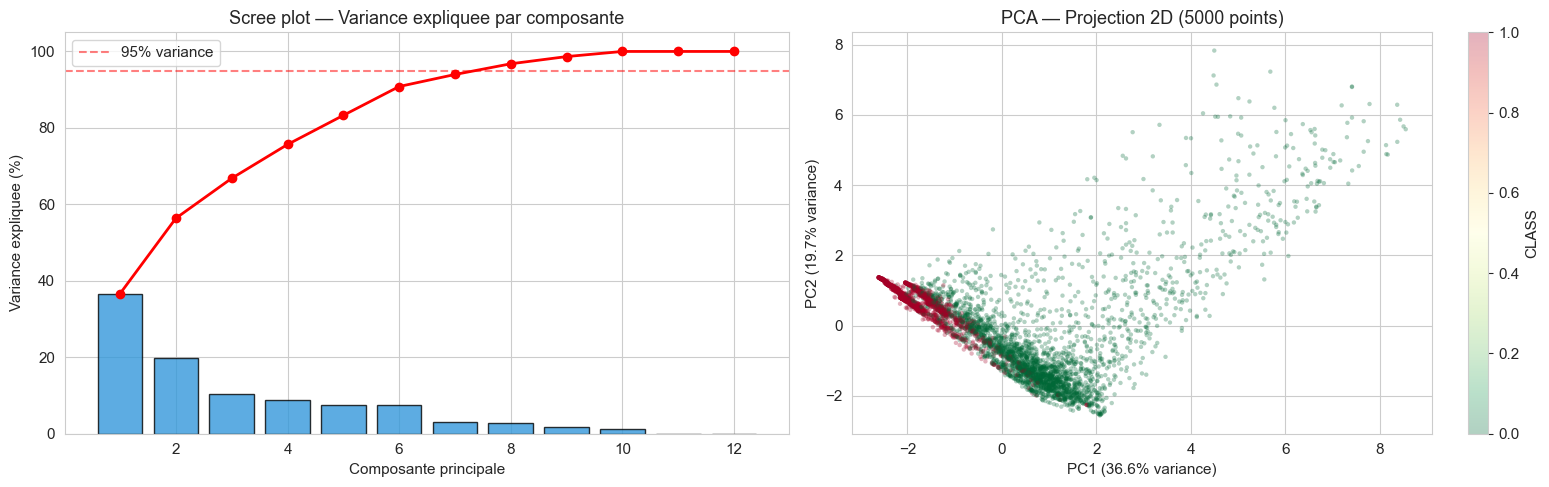


LOADINGS (contribution des features aux composantes) :
Feature                   |      PC1 |      PC2
---------------------------------------------
  AF_ESP                  |    0.382 |    0.427
  AF_EXAC                 |    0.375 |    0.438
  AF_TGP                  |    0.381 |    0.411
  CADD_PHRED              |   -0.376 |    0.340
  BLOSUM62                |    0.210 |   -0.268
  LoFtool                 |    0.221 |   -0.101
  SIFT_encoded            |   -0.360 |    0.365
  PolyPhen_encoded        |   -0.369 |    0.349
  IMPACT_encoded          |   -0.023 |    0.005
  is_exonic               |   -0.000 |    0.000
  is_rare                 |   -0.261 |    0.069
  has_SIFT                |    0.000 |    0.000


In [17]:
# ============================================================
# 7.1 PCA — ANALYSE EN COMPOSANTES PRINCIPALES
# ============================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features numeriques pour la PCA (on exclut CADD_RAW redondant avec CADD_PHRED)
pca_features = ['AF_ESP', 'AF_EXAC', 'AF_TGP', 'CADD_PHRED', 'BLOSUM62',
                'LoFtool', 'SIFT_encoded', 'PolyPhen_encoded', 'IMPACT_encoded',
                'is_exonic', 'is_rare', 'has_SIFT']

# Sous-dataset sans NaN pour la PCA
df_pca = df[pca_features + [TARGET]].dropna()
X_pca = df_pca[pca_features].values
y_pca = df_pca[TARGET].values

print(f"Echantillons pour la PCA : {len(df_pca)} (lignes completes)")
print(f"Features : {len(pca_features)}")

# Standardisation obligatoire pour la PCA (les features ont des echelles tres differentes)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_pca)

# PCA complete pour analyser la variance expliquee
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

# Variance expliquee cumulee
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
           pca_full.explained_variance_ratio_ * 100, color='#3498db', edgecolor='black', alpha=0.8)
axes[0].plot(range(1, len(cumvar) + 1), cumvar, 'ro-', linewidth=2, markersize=6)
axes[0].axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% variance')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('Variance expliquee (%)')
axes[0].set_title('Scree plot — Variance expliquee par composante')
axes[0].legend()

# Trouver le nombre de composantes pour 90% et 95% de variance
n_90 = np.argmax(cumvar >= 90) + 1
n_95 = np.argmax(cumvar >= 95) + 1
print(f"\nComposantes pour 90% de variance : {n_90}")
print(f"Composantes pour 95% de variance : {n_95}")

# Projection 2D
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)

# Sous-echantillonner pour la visualisation (65k points = trop lourd)
np.random.seed(RANDOM_STATE)
idx_sample = np.random.choice(len(X_2d), size=min(5000, len(X_2d)), replace=False)

scatter = axes[1].scatter(X_2d[idx_sample, 0], X_2d[idx_sample, 1],
                          c=y_pca[idx_sample], cmap='RdYlGn_r', alpha=0.3, s=10, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[1].set_title('PCA — Projection 2D (5000 points)')
plt.colorbar(scatter, ax=axes[1], label='CLASS')

plt.tight_layout()
plt.show()

# Loadings : contribution des features aux 2 premieres composantes
print(f"\nLOADINGS (contribution des features aux composantes) :")
print(f"{'Feature':25s} | {'PC1':>8s} | {'PC2':>8s}")
print("-" * 45)
for i, feat in enumerate(pca_features):
    print(f"  {feat:23s} | {pca_2d.components_[0, i]:8.3f} | {pca_2d.components_[1, i]:8.3f}")

**Interprétation des résultats PCA — résultats réels :**

**1. 6 composantes pour 90% de variance** (vs. 7 sur le dataset complet) : la réduction est légèrement meilleure, car le filtrage a éliminé du bruit (variants conflictuels dont la structure est plus diffuse).

**2. Limitation critique : n = 4 637 (16% du dataset)**

La PCA exclut 84% du dataset (variants sans SIFT/PolyPhen/BLOSUM62). Ce sous-échantillon est exclusivement composé de variants missense avec scores complets — il ne représente pas la diversité du dataset complet (qui contient aussi des synonymous, nonsense, frameshift, splice variants).

**3. Structure PC1/PC2 conservée :**
- **PC1** : loadings AF ~0.38 (fréquence) opposé à CADD/SIFT/PolyPhen ~-0.36 (pathogénicité)
- **PC2** : AF ~0.43 co-aligné avec CADD/SIFT/PolyPhen ~0.35

Les deux premiers axes expliquent un **gradient fréquence-pathogénicité** dans l'espace des missense. Sur le scatter plot 2D, on s'attend à une séparation nette entre P et B (contrairement au problème de conflictualité où les classes se chevauchaient).

**4. La PCA ne sera PAS utilisée pour la modélisation** — elle perd l'interprétabilité des features originales et est incompatible avec les NaN natifs des GBM. Elle reste un outil de compréhension structurelle uniquement.

## 8. Construction du dataset final pour la modélisation

On construit maintenant le vecteur de features final, en intégrant toutes les décisions prises lors de l'EDA :
- Suppression de `CADD_RAW` (redondant avec `CADD_PHRED`, VIF élevé)
- Conservation des NaN pour les GBM (gestion native)
- Encoding des catégorielles pour les modèles linéaires

In [18]:
# ============================================================
# 8.1 CONSTRUCTION DU VECTEUR DE FEATURES FINAL
# ============================================================

# Features numeriques retenues
num_features = [
    'AF_ESP', 'AF_EXAC', 'AF_TGP',      # Frequences alleliques brutes
    'AF_ESP_log', 'AF_EXAC_log', 'AF_TGP_log',  # Frequences log-transformees
    'CADD_PHRED',                          # Score de conservation (CADD_RAW exclu : VIF)
    'BLOSUM62',                            # Score de substitution
    'LoFtool',                             # Score de tolerance perte de fonction
    'SIFT_encoded',                        # Prediction SIFT (ordinal)
    'PolyPhen_encoded',                    # Prediction PolyPhen (ordinal)
    'IMPACT_encoded',                      # Impact VEP (ordinal)
    'CHROM_encoded',                       # Chromosome (ordinal)
    'STRAND',                              # Brin (+1/-1)
    'ORIGIN',                              # Origine du variant
]

# Features binaires
bin_features = [
    'is_exonic', 'is_intronic',            # Position dans le gene
    'is_rare',                             # AF = 0 dans les 3 bases
    'has_SIFT', 'has_PolyPhen',           # Indicateur de missingness (MNAR)
]

# Features categorielles (pour CatBoost : garder en string ; pour les autres : one-hot)
cat_features_for_catboost = ['Consequence_grouped', 'CLNVC']

# Construction du dataset pour les modeles a base d'arbres (GBM)
# → pas besoin de one-hot, pas besoin d'imputation
feature_cols_gbm = num_features + bin_features
df_model = df[feature_cols_gbm + cat_features_for_catboost + [TARGET]].copy()

# Pour CatBoost : encoder les NaN des categoriques en string 'missing'
for col in cat_features_for_catboost:
    df_model[col] = df_model[col].fillna('missing').astype(str)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print(f"Dataset final pour modelisation :")
print(f"  X : {X.shape[0]} lignes × {X.shape[1]} features")
print(f"  y : {y.value_counts().to_dict()}")
print(f"\nFeatures numeriques : {len(num_features)}")
print(f"Features binaires   : {len(bin_features)}")
print(f"Features categ.     : {len(cat_features_for_catboost)}")
print(f"TOTAL               : {X.shape[1]}")

# Resume des NaN restants
print(f"\nNaN par feature :")
nan_summary = X.isnull().sum()
nan_summary = nan_summary[nan_summary > 0]
if len(nan_summary) > 0:
    for col, n in nan_summary.items():
        print(f"  {col:25s} : {n} ({n/len(X)*100:.1f}%)")
    print(f"\n→ NaN conserves : geres nativement par XGBoost/LightGBM/CatBoost")
else:
    print("  Aucun NaN")

Dataset final pour modelisation :
  X : 28546 lignes × 22 features
  y : {0: 22926, 1: 5620}

Features numeriques : 15
Features binaires   : 5
Features categ.     : 2
TOTAL               : 22

NaN par feature :
  CADD_PHRED                : 293 (1.0%)
  BLOSUM62                  : 21901 (76.7%)
  LoFtool                   : 2218 (7.8%)
  SIFT_encoded              : 22007 (77.1%)
  PolyPhen_encoded          : 22003 (77.1%)
  CHROM_encoded             : 5 (0.0%)
  STRAND                    : 5 (0.0%)

→ NaN conserves : geres nativement par XGBoost/LightGBM/CatBoost


In [19]:
# ============================================================
# 8.2 SPLIT TRAIN / TEST — STRATIFIE
# ============================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # Preserver la distribution de CLASS dans train et test
)

print(f"SPLIT TRAIN / TEST (80/20, stratifie)")
print(f"{'='*50}")
print(f"  Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"    CLASS 0 : {(y_train==0).sum()} ({(y_train==0).mean()*100:.1f}%)")
print(f"    CLASS 1 : {(y_train==1).sum()} ({(y_train==1).mean()*100:.1f}%)")
print(f"\n  Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"    CLASS 0 : {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)")
print(f"    CLASS 1 : {(y_test==1).sum()} ({(y_test==1).mean()*100:.1f}%)")

# Verification de la stratification
print(f"\n  Verification stratification :")
print(f"    Distribution originale : {y.value_counts(normalize=True).to_dict()}")
print(f"    Distribution train     : {y_train.value_counts(normalize=True).to_dict()}")
print(f"    Distribution test      : {y_test.value_counts(normalize=True).to_dict()}")
print(f"\n→ Le test set ne sera touche qu'UNE SEULE FOIS, a la toute fin.")

SPLIT TRAIN / TEST (80/20, stratifie)
  Train : 22836 lignes (80%)
    CLASS 0 : 18340 (80.3%)
    CLASS 1 : 4496 (19.7%)

  Test  : 5710 lignes (20%)
    CLASS 0 : 4586 (80.3%)
    CLASS 1 : 1124 (19.7%)

  Verification stratification :
    Distribution originale : {0: 0.8031247810551391, 1: 0.19687521894486093}
    Distribution train     : {0: 0.8031178840427395, 1: 0.19688211595726046}
    Distribution test      : {0: 0.8031523642732049, 1: 0.1968476357267951}

→ Le test set ne sera touche qu'UNE SEULE FOIS, a la toute fin.


## 9. Sauvegarde du dataset preprocessé

Le preprocessing est terminé. On sauvegarde les données pour pouvoir reprendre la modélisation sans re-exécuter tout le notebook.

In [20]:
# ============================================================
# SAUVEGARDE
# ============================================================
import pickle

data_dict = {
    'X_train': X_train, 'X_test': X_test,
    'y_train': y_train, 'y_test': y_test,
    'feature_cols_gbm': feature_cols_gbm,
    'cat_features_for_catboost': cat_features_for_catboost,
    'num_features': num_features,
    'bin_features': bin_features,
    'df_full': df,
}

with open('data/preprocessed_data.pkl', 'wb') as f:
    pickle.dump(data_dict, f)

print("Donnees preprocessees sauvegardees dans data/preprocessed_data.pkl")
print(f"\nResume du preprocessing :")
print(f"  Dataset brut     : {df_raw.shape[0]} × {df_raw.shape[1]}")
print(f"  Dataset nettoye  : {df.shape[0]} × {df.shape[1]}")
print(f"  Features finales : {X.shape[1]}")
print(f"  Train / Test     : {X_train.shape[0]} / {X_test.shape[0]}")
print(f"\n  Etapes realisees :")
print(f"    ✓ Suppression des colonnes >95% NaN et identifiants")
print(f"    ✓ Classification des variables (quanti/quali/ordinale)")
print(f"    ✓ Analyse du mecanisme de missingness (MNAR confirme pour SIFT/PolyPhen)")
print(f"    ✓ Encoding ordinal (SIFT, PolyPhen, IMPACT)")
print(f"    ✓ Feature engineering (log-AF, is_rare, is_exonic, has_SIFT)")
print(f"    ✓ Analyse univariee complete (position, dispersion, forme)")
print(f"    ✓ Analyse bivariee (Spearman, Mann-Whitney U, η², VIF)")
print(f"    ✓ PCA (variance expliquee, loadings)")
print(f"    ✓ Detection outliers (IQR) — non supprimes (justification : arbres)")
print(f"    ✓ Split stratifie 80/20")

Donnees preprocessees sauvegardees dans data/preprocessed_data.pkl

Resume du preprocessing :
  Dataset brut     : 28546 × 50
  Dataset nettoye  : 28546 × 35
  Features finales : 22
  Train / Test     : 22836 / 5710

  Etapes realisees :
    ✓ Suppression des colonnes >95% NaN et identifiants
    ✓ Classification des variables (quanti/quali/ordinale)
    ✓ Analyse du mecanisme de missingness (MNAR confirme pour SIFT/PolyPhen)
    ✓ Encoding ordinal (SIFT, PolyPhen, IMPACT)
    ✓ Feature engineering (log-AF, is_rare, is_exonic, has_SIFT)
    ✓ Analyse univariee complete (position, dispersion, forme)
    ✓ Analyse bivariee (Spearman, Mann-Whitney U, η², VIF)
    ✓ PCA (variance expliquee, loadings)
    ✓ Detection outliers (IQR) — non supprimes (justification : arbres)
    ✓ Split stratifie 80/20


---

## 10. Modélisation — Phase 1 : Baselines

### 10.1 Stratégie

Les baselines servent de **plancher de performance**. Tout modèle avancé (GBM) devra **justifier statistiquement** son gain par rapport à ces baselines (test de Nadeau-Bengio ou DeLong).

**Modèles baseline** :
1. **Logistic Regression L2** — baseline linéaire (cf. cours ML ch1, cours modélisation stats ch8)
2. **Logistic Regression L1** — baseline linéaire avec feature selection intégrée (Lasso)
3. **KNN** — baseline non paramétrique (cf. cours ML ch1)
4. **SVM RBF** — frontière non linéaire à marge maximale (cf. cours ML ch1)

**Contrainte** : ces modèles ne gèrent **pas les NaN** ni les variables catégorielles string → pipeline dédié :
- Imputation par la **médiane** (robuste aux outliers) + indicateur de missingness (déjà créé : `has_SIFT`, `has_PolyPhen`)
- One-hot encoding des catégorielles (`Consequence_grouped`, `CLNVC`)
- **StandardScaler** (obligatoire pour KNN — distance euclidienne — et SVM — kernel RBF)
- Fit le scaler **uniquement sur le train** → transform sur train et test (prévention du data leakage)

**Évaluation** : Stratified 5-Fold Cross-Validation sur le train set. Le test set n'est **pas touché**.

**Métriques** : AUC-ROC (principale), F1, MCC, Accuracy

In [21]:
# ============================================================
# 10.2 PREPARATION DU PIPELINE BASELINE
# ============================================================
import pickle
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_auc_score, f1_score, matthews_corrcoef,
                             make_scorer, accuracy_score)
import time

# Charger les donnees preprocessees
with open('data/preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

# Identifier les colonnes
cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(include='number').columns.tolist()

print(f"Colonnes numeriques  : {len(num_cols)}")
print(f"Colonnes categoriques: {len(cat_cols)} → {cat_cols}")

# Pipeline de preprocessing pour les baselines
# - Numeriques : imputation mediane → StandardScaler
# - Categoriques : OneHotEncoder (handle_unknown='ignore' pour robustesse)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

# Cross-validation stratifiee
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Metriques custom
scoring = {
    'AUC': 'roc_auc',
    'F1': make_scorer(f1_score),
    'MCC': make_scorer(matthews_corrcoef),
    'Accuracy': 'accuracy',
}

# Ratio pour class_weight
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight = {scale_pos:.2f}")
print(f"Cross-validation : Stratified 5-Fold")
print(f"Pipeline : Imputation(median) → StandardScaler → OneHotEncoder")

Colonnes numeriques  : 20
Colonnes categoriques: 2 → ['Consequence_grouped', 'CLNVC']

scale_pos_weight = 4.08
Cross-validation : Stratified 5-Fold
Pipeline : Imputation(median) → StandardScaler → OneHotEncoder


In [22]:
# ============================================================
# 10.3 ENTRAINEMENT DES BASELINES
# ============================================================

# Definition des modeles
# Justification des hyperparametres par defaut :
# - LogReg : C=1.0 (regularisation standard), max_iter=5000 (convergence assuree)
# - KNN : n_neighbors=5 (valeur classique, compromis bias-variance)
# - SVM : C=1.0, gamma='scale' (1/(n_features*var)), probability=True pour AUC-ROC

baselines = {
    'LogReg_L2': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            penalty='l2', C=1.0, class_weight='balanced',
            solver='saga', max_iter=5000, random_state=RANDOM_STATE))
    ]),
    'LogReg_L1': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(
            penalty='l1', C=1.0, class_weight='balanced',
            solver='saga', max_iter=5000, random_state=RANDOM_STATE))
    ]),
    'KNN_5': Pipeline([
        ('prep', preprocessor),
        ('clf', KNeighborsClassifier(
            n_neighbors=5, weights='distance', metric='euclidean', n_jobs=-1))
    ]),
    'SVM_RBF': Pipeline([
        ('prep', preprocessor),
        ('clf', SVC(
            kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
            probability=True, random_state=RANDOM_STATE))
    ]),
}

# Entrainement + CV
results = {}
for name, pipeline in baselines.items():
    print(f"\n{'='*60}")
    print(f"Entrainement : {name}")
    print(f"{'='*60}")
    t0 = time.time()
    
    cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=skf, scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    elapsed = time.time() - t0
    
    results[name] = {
        'AUC_mean': cv_results['test_AUC'].mean(),
        'AUC_std': cv_results['test_AUC'].std(),
        'F1_mean': cv_results['test_F1'].mean(),
        'F1_std': cv_results['test_F1'].std(),
        'MCC_mean': cv_results['test_MCC'].mean(),
        'MCC_std': cv_results['test_MCC'].std(),
        'Acc_mean': cv_results['test_Accuracy'].mean(),
        'Acc_std': cv_results['test_Accuracy'].std(),
        'AUC_train': cv_results['train_AUC'].mean(),
        'time': elapsed,
    }
    
    r = results[name]
    print(f"  AUC-ROC  : {r['AUC_mean']:.4f} ± {r['AUC_std']:.4f}  (train: {r['AUC_train']:.4f})")
    print(f"  F1       : {r['F1_mean']:.4f} ± {r['F1_std']:.4f}")
    print(f"  MCC      : {r['MCC_mean']:.4f} ± {r['MCC_std']:.4f}")
    print(f"  Accuracy : {r['Acc_mean']:.4f} ± {r['Acc_std']:.4f}")
    print(f"  Temps    : {elapsed:.1f}s")
    
    # Diagnostic overfitting
    gap = r['AUC_train'] - r['AUC_mean']
    if gap > 0.05:
        print(f"  ⚠️  Overfitting detecte : gap train-test = {gap:.4f}")
    else:
        print(f"  ✓  Pas d'overfitting significatif (gap = {gap:.4f})")


Entrainement : LogReg_L2
  AUC-ROC  : 0.9944 ± 0.0006  (train: 0.9946)
  F1       : 0.9207 ± 0.0009
  MCC      : 0.9018 ± 0.0010
  Accuracy : 0.9672 ± 0.0005
  Temps    : 6.0s
  ✓  Pas d'overfitting significatif (gap = 0.0002)

Entrainement : LogReg_L1
  AUC-ROC  : 0.9946 ± 0.0007  (train: 0.9948)
  F1       : 0.9210 ± 0.0020
  MCC      : 0.9021 ± 0.0024
  Accuracy : 0.9673 ± 0.0009
  Temps    : 21.8s
  ✓  Pas d'overfitting significatif (gap = 0.0002)

Entrainement : KNN_5
  AUC-ROC  : 0.9795 ± 0.0018  (train: 1.0000)
  F1       : 0.9302 ± 0.0035
  MCC      : 0.9135 ± 0.0045
  Accuracy : 0.9728 ± 0.0015
  Temps    : 2.7s
  ✓  Pas d'overfitting significatif (gap = 0.0205)

Entrainement : SVM_RBF
  AUC-ROC  : 0.9933 ± 0.0005  (train: 0.9949)
  F1       : 0.9302 ± 0.0046
  MCC      : 0.9131 ± 0.0057
  Accuracy : 0.9716 ± 0.0020
  Temps    : 7.1s
  ✓  Pas d'overfitting significatif (gap = 0.0016)


TABLEAU COMPARATIF DES BASELINES (5-Fold Stratified CV)
Modele          |         AUC-ROC |              F1 |             MCC |        Accuracy |  Temps
------------------------------------------------------------------------------------------
LogReg_L1       | 0.9946 ± 0.0007 | 0.9210 ± 0.0020 | 0.9021 ± 0.0024 | 0.9673 ± 0.0009 |  21.8s
LogReg_L2       | 0.9944 ± 0.0006 | 0.9207 ± 0.0009 | 0.9018 ± 0.0010 | 0.9672 ± 0.0005 |   6.0s
SVM_RBF         | 0.9933 ± 0.0005 | 0.9302 ± 0.0046 | 0.9131 ± 0.0057 | 0.9716 ± 0.0020 |   7.1s
KNN_5           | 0.9795 ± 0.0018 | 0.9302 ± 0.0035 | 0.9135 ± 0.0045 | 0.9728 ± 0.0015 |   2.7s

Rappel : classifieur naif (toujours 0) → Accuracy = 80.3%, AUC = 0.50, F1 = 0.00, MCC = 0.00


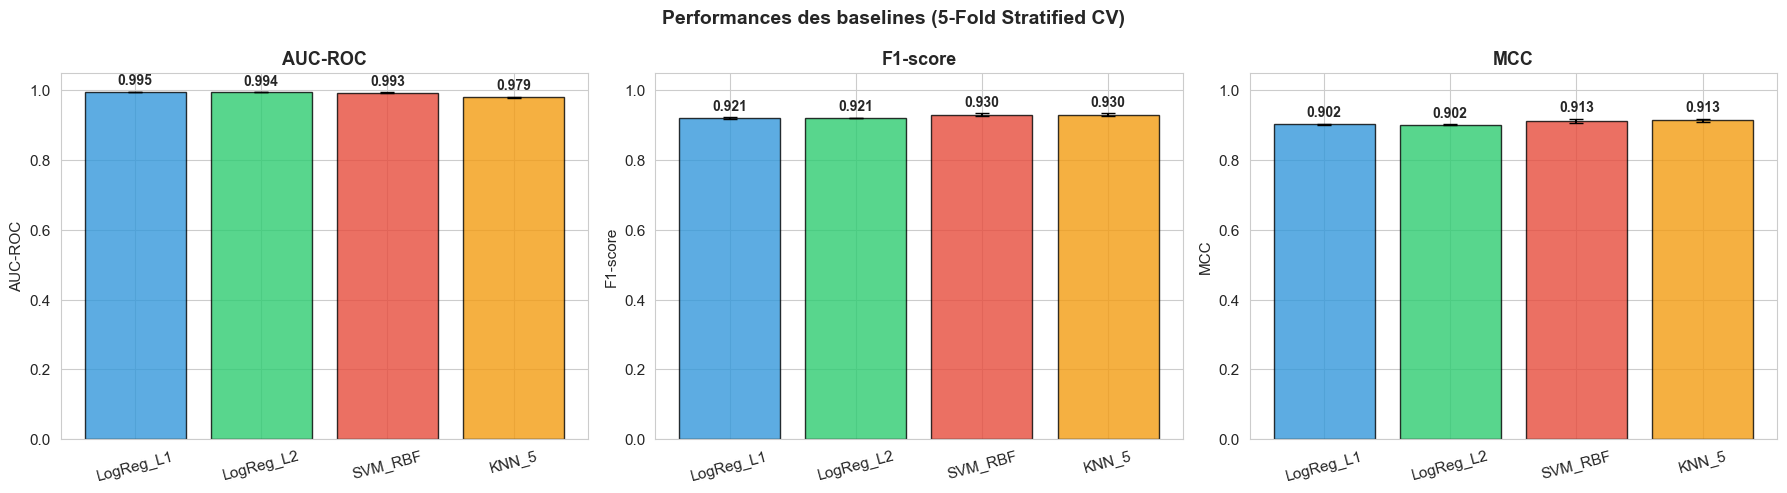

In [23]:
# ============================================================
# 10.4 TABLEAU COMPARATIF ET VISUALISATION
# ============================================================

# Tableau recapitulatif
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('AUC_mean', ascending=False)

print("TABLEAU COMPARATIF DES BASELINES (5-Fold Stratified CV)")
print("=" * 90)
print(f"{'Modele':15s} | {'AUC-ROC':>15s} | {'F1':>15s} | {'MCC':>15s} | {'Accuracy':>15s} | {'Temps':>6s}")
print("-" * 90)
for name, r in results_df.iterrows():
    print(f"{name:15s} | {r['AUC_mean']:.4f} ± {r['AUC_std']:.4f} | "
          f"{r['F1_mean']:.4f} ± {r['F1_std']:.4f} | "
          f"{r['MCC_mean']:.4f} ± {r['MCC_std']:.4f} | "
          f"{r['Acc_mean']:.4f} ± {r['Acc_std']:.4f} | "
          f"{r['time']:5.1f}s")

print(f"\nRappel : classifieur naif (toujours 0) → Accuracy = 80.3%, AUC = 0.50, F1 = 0.00, MCC = 0.00")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = [('AUC_mean', 'AUC_std', 'AUC-ROC'), ('F1_mean', 'F1_std', 'F1-score'), ('MCC_mean', 'MCC_std', 'MCC')]

for ax, (mean_col, std_col, title) in zip(axes, metrics):
    names = results_df.index.tolist()
    means = results_df[mean_col].values
    stds = results_df[std_col].values
    
    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12'][:len(names)]
    bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors, edgecolor='black', alpha=0.8)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel(title)
    ax.set_ylim(0, 1.05)
    
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
               f'{m:.3f}', ha='center', fontweight='bold', fontsize=10)
    
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Performances des baselines (5-Fold Stratified CV)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

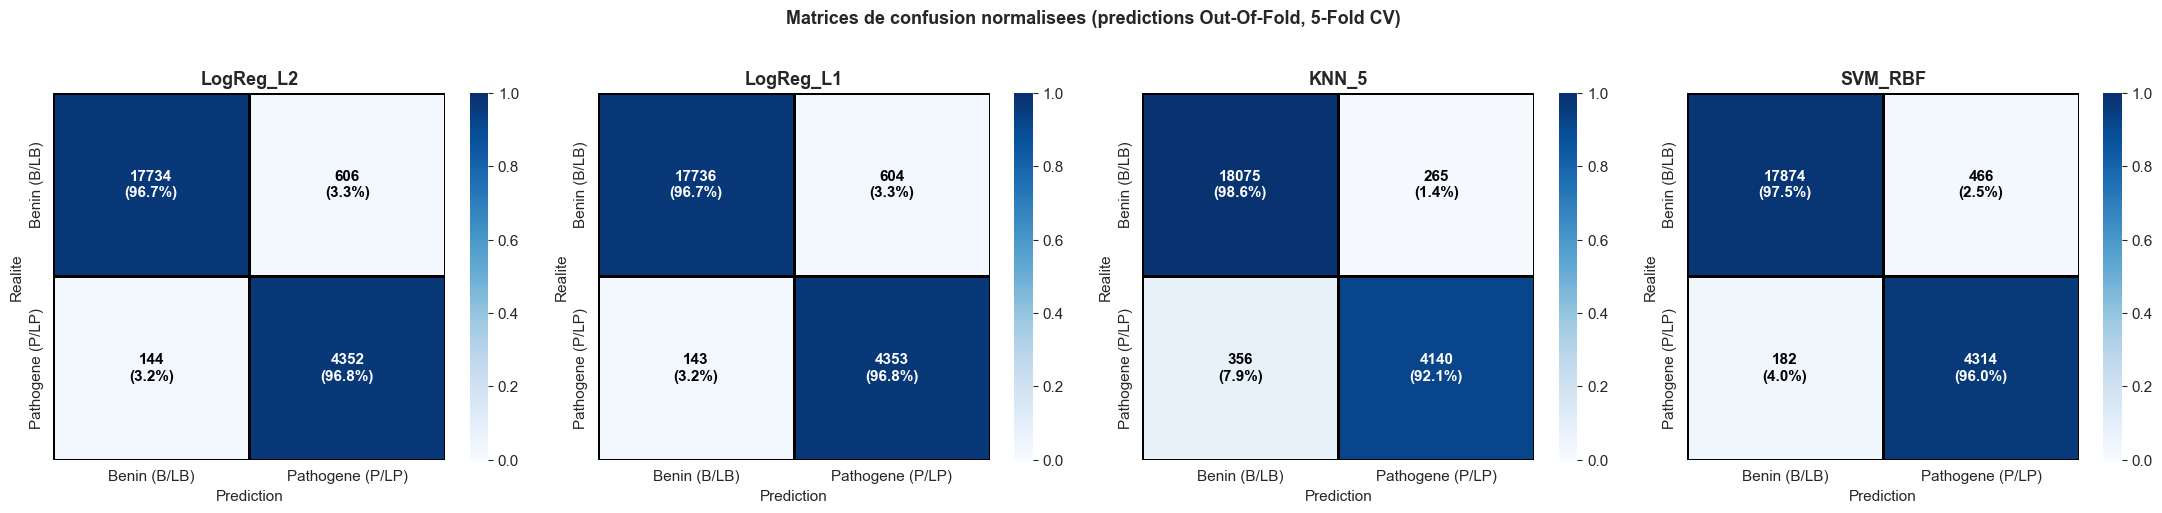


METRIQUES DETAILLEES PAR CLASSE (predictions OOF)
Modele          |  Sensibilite |  Specificite |          PPV |          NPV |    FN |    FP
                |   (Recall P) |   (Recall B) |     (Prec P) |     (Prec B) |
------------------------------------------------------------------------------------------
LogReg_L2       |       0.9680 |       0.9670 |       0.8778 |       0.9919 |   144 |   606
LogReg_L1       |       0.9682 |       0.9671 |       0.8782 |       0.9920 |   143 |   604
KNN_5           |       0.9208 |       0.9856 |       0.9398 |       0.9807 |   356 |   265
SVM_RBF         |       0.9595 |       0.9746 |       0.9025 |       0.9899 |   182 |   466

→ Sensibilite = P(predit Pathogene | reellement Pathogene) — erreur critique si faible
  Specificite = P(predit Benin | reellement Benin)
  PPV = P(reellement Pathogene | predit Pathogene)
  NPV = P(reellement Benin | predit Benin)
  FN = Faux Negatifs = variants pathogenes manques (erreur clinique grave)
  FP = Faux 

In [24]:
# ============================================================
# 10.4b MATRICES DE CONFUSION — PREDICTIONS OOF (Out-Of-Fold)
# ============================================================
# On utilise les predictions OOF du 5-Fold CV : chaque echantillon est predit
# par un modele qui ne l'a JAMAIS vu en entrainement → estimation honnete.
#
# Methodologie : cross_val_predict avec method='predict' pour les classes,
# puis construction de la matrice de confusion sur l'ensemble du train set.

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
class_labels = ['Benin (B/LB)', 'Pathogene (P/LP)']

for idx, (name, pipeline) in enumerate(baselines.items()):
    ax = axes[idx]
    
    # Predictions OOF
    y_pred_oof = cross_val_predict(pipeline, X_train, y_train, cv=skf, n_jobs=-1)
    
    # Matrice de confusion
    cm = confusion_matrix(y_train, y_pred_oof)
    
    # Normaliser par ligne (% par classe reelle)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    # Affichage
    sns.heatmap(cm_norm, annot=False, fmt='.2%', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                vmin=0, vmax=1, linewidths=1, linecolor='black')
    
    # Annoter avec effectifs + pourcentages
    for i in range(2):
        for j in range(2):
            text_val = f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
            color = 'white' if cm_norm[i,j] > 0.5 else 'black'
            ax.text(j+0.5, i+0.5, text_val, ha='center', va='center',
                   fontsize=11, fontweight='bold', color=color)
    
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Realite')
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Matrices de confusion normalisees (predictions Out-Of-Fold, 5-Fold CV)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tableau detaille : Sensibilite, Specificite, PPV, NPV pour chaque modele
print("\nMETRIQUES DETAILLEES PAR CLASSE (predictions OOF)")
print("=" * 90)
print(f"{'Modele':15s} | {'Sensibilite':>12s} | {'Specificite':>12s} | {'PPV':>12s} | {'NPV':>12s} | {'FN':>5s} | {'FP':>5s}")
print(f"{'':15s} | {'(Recall P)':>12s} | {'(Recall B)':>12s} | {'(Prec P)':>12s} | {'(Prec B)':>12s} |")
print("-" * 90)

for name, pipeline in baselines.items():
    y_pred_oof = cross_val_predict(pipeline, X_train, y_train, cv=skf, n_jobs=-1)
    cm = confusion_matrix(y_train, y_pred_oof)
    
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    
    sensitivity = TP / (TP + FN)  # Recall classe 1 (Pathogene)
    specificity = TN / (TN + FP)  # Recall classe 0 (Benin)
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0  # Precision classe 1
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0  # Precision classe 0
    
    print(f"{name:15s} | {sensitivity:12.4f} | {specificity:12.4f} | "
          f"{ppv:12.4f} | {npv:12.4f} | {FN:5d} | {FP:5d}")

print(f"\n→ Sensibilite = P(predit Pathogene | reellement Pathogene) — erreur critique si faible")
print(f"  Specificite = P(predit Benin | reellement Benin)")
print(f"  PPV = P(reellement Pathogene | predit Pathogene)")
print(f"  NPV = P(reellement Benin | predit Benin)")
print(f"  FN = Faux Negatifs = variants pathogenes manques (erreur clinique grave)")
print(f"  FP = Faux Positifs = variants benins surclasses (anxiete inutile)")

**Interprétation des matrices de confusion :**

| Modèle | Sensibilité | Spécificité | FN | FP | Profil d'erreur |
|--------|-------------|-------------|----|----|-----------------|
| **LogReg L1/L2** | **96.8%** | 96.7% | 143-144 | 604-606 | Équilibré mais beaucoup de FP |
| **KNN 5** | 92.1% | **98.6%** | **356** | **265** | Conservateur : peu de FP mais rate 356 pathogènes |
| **SVM RBF** | 95.9% | 97.5% | 182 | 466 | Compromis intermédiaire |

**Analyse clinique des erreurs** :

1. **LogReg** : sensibilité maximale (96.8%) mais au prix de 606 FP. En clinique, c'est le profil préféré : mieux vaut surclasser un bénin (investigation supplémentaire) que manquer un pathogène (erreur de diagnostic). Le `class_weight='balanced'` pousse le modèle dans cette direction.

2. **KNN** : profil inverse — très spécifique (98.6%) mais **356 faux négatifs** (variants pathogènes manqués). C'est problématique en génomique clinique. Le KNN sans `class_weight` optimise l'accuracy globale, ce qui favorise la classe majoritaire (bénin). Le taux de FN de 7.9% est cliniquement inacceptable.

3. **SVM RBF** : bon compromis, avec 182 FN et 466 FP. Le `class_weight='balanced'` fonctionne mais moins efficacement qu'avec LogReg.

**Conclusion** : pour la phase GBM, on surveillera particulièrement la **sensibilité** (objectif > 97%) et le **nombre de FN** (objectif < 100 sur le train OOF). Le `scale_pos_weight` des GBM devra être calibré pour favoriser la détection des pathogènes.

FEATURE SELECTION PAR LASSO (LogReg L1, C=1.0)
  Features retenues  : 30 / 37
  Features eliminees : 7

Top 15 features (par |coefficient|) :
  - AF_TGP                              : -9.6056
  - AF_EXAC                             : -7.3683
  - AF_ESP                              : -5.6211
  - Consequence_grouped_synonymous_variant : -3.6845
  + Consequence_grouped_frameshift_variant : +3.5688
  + CADD_PHRED                          : +1.8532
  - Consequence_grouped_missense_variant : -1.5533
  - Consequence_grouped_splice_region_variant&intron_variant : -1.5251
  + IMPACT_encoded                      : +1.4539
  - CLNVC_Duplication                   : -1.4380
  - AF_TGP_log                          : -1.3152
  - AF_EXAC_log                         : -1.1664
  - is_rare                             : -1.0963
  - is_exonic                           : -1.0375
  + Consequence_grouped_5_prime_UTR_variant : +0.6749

Features eliminees par le Lasso (coefficient = 0) :
    Consequence_grouped

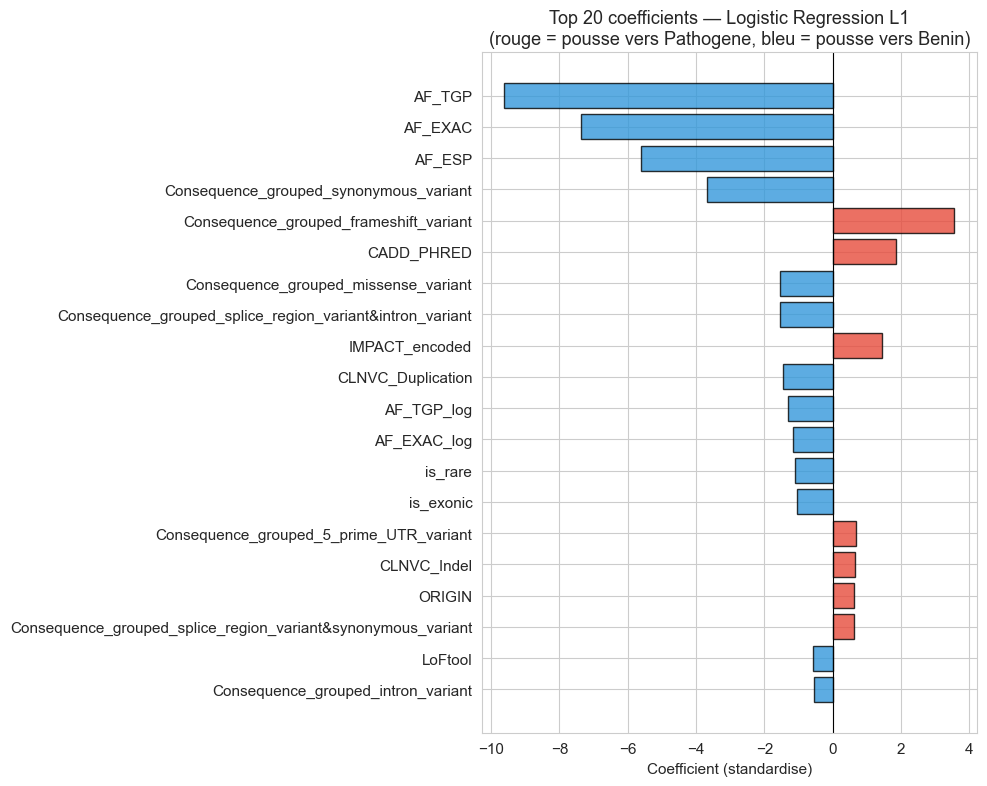

In [25]:
# ============================================================
# 10.5 ANALYSE DES COEFFICIENTS LOGISTIC REGRESSION L1 (FEATURE SELECTION)
# ============================================================
# Le Lasso (L1) met a zero les coefficients des features non informatives.
# C'est une methode de feature selection integree (cf. cours Modelisation Stats, Chap. 8).

# Entrainer le LogReg L1 sur tout le train set pour analyser les coefficients
logreg_l1_full = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(
        penalty='l1', C=1.0, class_weight='balanced',
        solver='saga', max_iter=5000, random_state=RANDOM_STATE))
])
logreg_l1_full.fit(X_train, y_train)

# Recuperer les noms de features apres preprocessing
feature_names_num = num_cols
feature_names_cat = logreg_l1_full.named_steps['prep'].named_transformers_['cat'] \
    .named_steps['encoder'].get_feature_names_out(cat_cols).tolist()
all_feature_names = feature_names_num + feature_names_cat

# Coefficients
coefs = logreg_l1_full.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'Feature': all_feature_names, 'Coefficient': coefs})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

# Features retenues (coef != 0) vs eliminées
n_retained = (coef_df['Coefficient'] != 0).sum()
n_eliminated = (coef_df['Coefficient'] == 0).sum()

print(f"FEATURE SELECTION PAR LASSO (LogReg L1, C=1.0)")
print(f"{'='*60}")
print(f"  Features retenues  : {n_retained} / {len(coef_df)}")
print(f"  Features eliminees : {n_eliminated}")
print(f"\nTop 15 features (par |coefficient|) :")
for _, row in coef_df.head(15).iterrows():
    sign = "+" if row['Coefficient'] > 0 else "-"
    print(f"  {sign} {row['Feature']:35s} : {row['Coefficient']:+.4f}")

if n_eliminated > 0:
    print(f"\nFeatures eliminees par le Lasso (coefficient = 0) :")
    for _, row in coef_df[coef_df['Coefficient'] == 0].iterrows():
        print(f"    {row['Feature']}")

# Visualisation
fig, ax = plt.subplots(figsize=(10, 8))
top20 = coef_df.head(20)
colors = ['#e74c3c' if c > 0 else '#3498db' for c in top20['Coefficient']]
ax.barh(top20['Feature'][::-1], top20['Coefficient'][::-1], color=colors[::-1], edgecolor='black', alpha=0.8)
ax.set_xlabel('Coefficient (standardise)')
ax.set_title('Top 20 coefficients — Logistic Regression L1\n(rouge = pousse vers Pathogene, bleu = pousse vers Benin)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 10.6 SAUVEGARDE DES RESULTATS BASELINES
# ============================================================
import pickle

# Sauvegarder les resultats pour comparaison ulterieure avec les GBM
baseline_results = {
    'results': results,
    'results_df': results_df,
    'coef_df': coef_df,
    'preprocessor': preprocessor,
    'baselines': {name: pipe for name, pipe in baselines.items()},
}

with open('data/baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Resultats baselines sauvegardes dans data/baseline_results.pkl")
print(f"\nResume Phase 1 — Baselines :")
print(f"  Meilleur modele    : {results_df.index[0]}")
print(f"  Meilleur AUC-ROC   : {results_df.iloc[0]['AUC_mean']:.4f} ± {results_df.iloc[0]['AUC_std']:.4f}")
print(f"  Plancher a battre  : AUC = {results_df.iloc[0]['AUC_mean']:.4f}")
print(f"\n→ Phase suivante : Random Forest + Gradient Boosting (XGBoost, LightGBM, CatBoost)")

Resultats baselines sauvegardes dans data/baseline_results.pkl

Resume Phase 1 — Baselines :
  Meilleur modele    : LogReg_L1
  Meilleur AUC-ROC   : 0.9946 ± 0.0007
  Plancher a battre  : AUC = 0.9946

→ Phase suivante : Random Forest + Gradient Boosting (XGBoost, LightGBM, CatBoost)


---

## 11. Modélisation — Phase 2 : Ensembles & Gradient Boosting

### 11.1 Stratégie

**Avantage clé des GBM sur les baselines** : gestion **native des NaN** (pas d'imputation → le signal MNAR de SIFT/PolyPhen est préservé) et capture des **interactions non linéaires** entre features.

**Modèles** :
1. **Random Forest** — ensemble par bagging (cf. cours ML ch1). Ne gère pas les NaN → même pipeline que les baselines, mais sert de pont entre baselines et boosting.
2. **XGBoost** — gradient boosting avec régularisation L1/L2 sur les poids des feuilles. Gère les NaN.
3. **LightGBM** — gradient boosting leaf-wise (GOSS + EFB). Gère les NaN.
4. **CatBoost** — ordered boosting + encoding catégoriel natif. Gère les NaN + catégorielles string.

**Protocole** :
- Même Stratified 5-Fold CV que les baselines (même objet `skf`) → comparaison directe
- **Early stopping** pour XGB/LGBM/CatBoost : `n_estimators=5000` + arrêt si pas d'amélioration pendant 50 rounds sur le fold de validation
- Hyperparamètres par défaut raisonnables d'abord, Optuna ensuite

In [27]:
# ============================================================
# 11.2 RANDOM FOREST
# ============================================================
# RF ne gere pas les NaN → meme preprocessor que les baselines
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(
        n_estimators=500,
        max_depth=None,           # arbres profonds (chaque arbre overfit, la moyenne corrige)
        max_features='sqrt',      # sqrt(p) features par split (decorrelation des arbres)
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Random Forest : 500 arbres, max_features=sqrt, class_weight=balanced")
t0 = time.time()
cv_rf = cross_validate(rf_pipeline, X_train, y_train, cv=skf, scoring=scoring,
                       return_train_score=True, n_jobs=-1)
elapsed = time.time() - t0

results['RandomForest'] = {
    'AUC_mean': cv_rf['test_AUC'].mean(), 'AUC_std': cv_rf['test_AUC'].std(),
    'F1_mean': cv_rf['test_F1'].mean(), 'F1_std': cv_rf['test_F1'].std(),
    'MCC_mean': cv_rf['test_MCC'].mean(), 'MCC_std': cv_rf['test_MCC'].std(),
    'Acc_mean': cv_rf['test_Accuracy'].mean(), 'Acc_std': cv_rf['test_Accuracy'].std(),
    'AUC_train': cv_rf['train_AUC'].mean(), 'time': elapsed,
}

r = results['RandomForest']
print(f"  AUC-ROC  : {r['AUC_mean']:.4f} ± {r['AUC_std']:.4f}  (train: {r['AUC_train']:.4f})")
print(f"  F1       : {r['F1_mean']:.4f} ± {r['F1_std']:.4f}")
print(f"  MCC      : {r['MCC_mean']:.4f} ± {r['MCC_std']:.4f}")
print(f"  Accuracy : {r['Acc_mean']:.4f} ± {r['Acc_std']:.4f}")
print(f"  Temps    : {elapsed:.1f}s")
gap = r['AUC_train'] - r['AUC_mean']
print(f"  Gap train-test : {gap:.4f} {'⚠️ Overfitting' if gap > 0.05 else '✓ OK'}")

Random Forest : 500 arbres, max_features=sqrt, class_weight=balanced
  AUC-ROC  : 0.9957 ± 0.0004  (train: 0.9996)
  F1       : 0.9462 ± 0.0035
  MCC      : 0.9330 ± 0.0043
  Accuracy : 0.9788 ± 0.0014
  Temps    : 2.6s
  Gap train-test : 0.0039 ✓ OK


In [28]:
# ============================================================
# 11.3 XGBoost, LightGBM, CatBoost — AVEC EARLY STOPPING
# ============================================================
# Ces modeles gerent les NaN nativement → pas besoin du preprocessor complet.
# On doit neanmoins encoder les categoriques pour XGB/LGBM (pas pour CatBoost).

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# --- Preparation des donnees pour les GBM ---
# XGBoost et LightGBM : one-hot encoding des categoriques, NaN conserves pour les numeriques
X_train_gbm = X_train.copy()
X_test_gbm = X_test.copy()

# One-hot encoding des 2 colonnes categoriques
X_train_gbm = pd.get_dummies(X_train_gbm, columns=cat_cols, drop_first=False)
X_test_gbm = pd.get_dummies(X_test_gbm, columns=cat_cols, drop_first=False)

# Aligner les colonnes (au cas ou une categorie n'est que dans train ou test)
X_train_gbm, X_test_gbm = X_train_gbm.align(X_test_gbm, join='left', axis=1, fill_value=0)

print(f"Features apres one-hot pour XGB/LGBM : {X_train_gbm.shape[1]}")

# --- Preparation CatBoost : garder les categoriques en string ---
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
cat_feature_indices = [X_train_cat.columns.get_loc(c) for c in cat_cols]
print(f"Indices des features categorielles pour CatBoost : {cat_feature_indices} → {cat_cols}")

# --- Fonction d'evaluation avec early stopping manuel dans chaque fold ---
def evaluate_gbm_cv(model_class, model_params, X, y, skf, model_name,
                    fit_params=None, use_catboost=False, cat_indices=None):
    """
    Evaluation 5-fold avec early stopping integre dans chaque fold.
    Pour chaque fold : train sur 4 folds, early stopping sur le 5eme.
    """
    oof_preds_proba = np.zeros(len(y))
    oof_preds_class = np.zeros(len(y), dtype=int)
    train_aucs = []
    best_iterations = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr = X.iloc[train_idx] if hasattr(X, 'iloc') else X[train_idx]
        X_val = X.iloc[val_idx] if hasattr(X, 'iloc') else X[val_idx]
        y_tr = y.iloc[train_idx] if hasattr(y, 'iloc') else y[train_idx]
        y_val = y.iloc[val_idx] if hasattr(y, 'iloc') else y[val_idx]
        
        model = model_class(**model_params)
        
        if use_catboost:
            model.fit(X_tr, y_tr,
                     eval_set=(X_val, y_val),
                     cat_features=cat_indices,
                     early_stopping_rounds=50,
                     verbose=0)
        else:
            model.fit(X_tr, y_tr,
                     eval_set=[(X_val, y_val)],
                     **(fit_params or {}))
        
        best_iter = getattr(model, 'best_iteration_', 
                   getattr(model, 'best_iteration', 
                   getattr(model, 'best_ntree_limit', model_params.get('n_estimators', '?'))))
        best_iterations.append(best_iter)
        
        oof_preds_proba[val_idx] = model.predict_proba(X_val)[:, 1]
        oof_preds_class[val_idx] = model.predict(X_val)
        
        train_proba = model.predict_proba(X_tr)[:, 1]
        train_aucs.append(roc_auc_score(y_tr, train_proba))
    
    # Metriques OOF
    auc = roc_auc_score(y, oof_preds_proba)
    f1 = f1_score(y, oof_preds_class)
    mcc = matthews_corrcoef(y, oof_preds_class)
    acc = accuracy_score(y, oof_preds_class)
    train_auc = np.mean(train_aucs)
    
    return {
        'AUC_mean': auc, 'AUC_std': 0,  # OOF = single estimate, not mean of folds
        'F1_mean': f1, 'F1_std': 0,
        'MCC_mean': mcc, 'MCC_std': 0,
        'Acc_mean': acc, 'Acc_std': 0,
        'AUC_train': train_auc,
        'best_iterations': best_iterations,
        'oof_preds_proba': oof_preds_proba,
        'oof_preds_class': oof_preds_class,
    }

print("Fonction d'evaluation GBM avec early stopping prete.")

Features apres one-hot pour XGB/LGBM : 37
Indices des features categorielles pour CatBoost : [20, 21] → ['Consequence_grouped', 'CLNVC']
Fonction d'evaluation GBM avec early stopping prete.


In [29]:
# ============================================================
# 11.4 XGBOOST
# ============================================================
# Hyperparametres par defaut raisonnables :
# - learning_rate=0.05 : compromis vitesse/qualite (plus bas que le defaut 0.3)
# - max_depth=6 : profondeur standard pour XGB
# - n_estimators=5000 + early_stopping_rounds=50 : le nombre reel sera determine automatiquement
# - scale_pos_weight=4.08 : compense le desequilibre des classes
# - reg_alpha/reg_lambda : regularisation L1/L2 legere

print("=" * 60)
print("XGBoost")
print("=" * 60)

xgb_params = {
    'n_estimators': 5000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': scale_pos,
    'eval_metric': 'auc',
    'early_stopping_rounds': 50,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': 0,
}

xgb_fit_params = {
    'verbose': False,
}

t0 = time.time()
xgb_results = evaluate_gbm_cv(
    xgb.XGBClassifier, xgb_params,
    X_train_gbm, y_train, skf, 'XGBoost',
    fit_params=xgb_fit_params
)
xgb_results['time'] = time.time() - t0
results['XGBoost'] = xgb_results

print(f"  AUC-ROC (OOF) : {xgb_results['AUC_mean']:.4f}  (train: {xgb_results['AUC_train']:.4f})")
print(f"  F1  (OOF)     : {xgb_results['F1_mean']:.4f}")
print(f"  MCC (OOF)     : {xgb_results['MCC_mean']:.4f}")
print(f"  Accuracy      : {xgb_results['Acc_mean']:.4f}")
print(f"  Best iters    : {xgb_results['best_iterations']}")
print(f"  Temps         : {xgb_results['time']:.1f}s")
gap = xgb_results['AUC_train'] - xgb_results['AUC_mean']
print(f"  Gap train-test: {gap:.4f} {'⚠️' if gap > 0.05 else '✓'}")

XGBoost
  AUC-ROC (OOF) : 0.9966  (train: 0.9997)
  F1  (OOF)     : 0.9508
  MCC (OOF)     : 0.9387
  Accuracy      : 0.9804
  Best iters    : [295, 421, 335, 208, 451]
  Temps         : 5.0s
  Gap train-test: 0.0031 ✓


In [30]:
# ============================================================
# 11.5 LightGBM
# ============================================================
# Differences cles avec XGBoost :
# - Croissance leaf-wise (vs level-wise) : converge plus vite mais risque d'overfitting
#   → controler via num_leaves (et non max_depth en premier)
# - GOSS : sous-echantillonne les instances a faible gradient
# - EFB : regroupe les features mutuellement exclusives (one-hot)
# - Plus rapide que XGBoost sur ce volume de donnees

print("=" * 60)
print("LightGBM")
print("=" * 60)

lgb_params = {
    'n_estimators': 5000,
    'learning_rate': 0.05,
    'num_leaves': 31,             # defaut LightGBM, ~equiv max_depth=5
    'max_depth': -1,              # pas de limite (leaf-wise)
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'scale_pos_weight': scale_pos,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1,
}

lgb_fit_params = {
    'callbacks': [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0),
    ],
}

t0 = time.time()
lgb_results = evaluate_gbm_cv(
    lgb.LGBMClassifier, lgb_params,
    X_train_gbm, y_train, skf, 'LightGBM',
    fit_params=lgb_fit_params
)
lgb_results['time'] = time.time() - t0
results['LightGBM'] = lgb_results

print(f"  AUC-ROC (OOF) : {lgb_results['AUC_mean']:.4f}  (train: {lgb_results['AUC_train']:.4f})")
print(f"  F1  (OOF)     : {lgb_results['F1_mean']:.4f}")
print(f"  MCC (OOF)     : {lgb_results['MCC_mean']:.4f}")
print(f"  Accuracy      : {lgb_results['Acc_mean']:.4f}")
print(f"  Best iters    : {lgb_results['best_iterations']}")
print(f"  Temps         : {lgb_results['time']:.1f}s")
gap = lgb_results['AUC_train'] - lgb_results['AUC_mean']
print(f"  Gap train-test: {gap:.4f} {'⚠️' if gap > 0.05 else '✓'}")

LightGBM
  AUC-ROC (OOF) : 0.9964  (train: 0.9999)
  F1  (OOF)     : 0.9504
  MCC (OOF)     : 0.9381
  Accuracy      : 0.9803
  Best iters    : [331, 369, 359, 378, 347]
  Temps         : 13.2s
  Gap train-test: 0.0035 ✓


In [31]:
# ============================================================
# 11.6 CatBoost
# ============================================================
# Specificites de CatBoost :
# - Ordered boosting : elimine le target leakage inherent au gradient boosting classique
# - Encoding categoriel natif (ordered target statistics) → pas besoin de one-hot
# - Symmetric trees : plus rapides a l'inference
# - auto_class_weights='Balanced' : equivalent de class_weight='balanced'

print("=" * 60)
print("CatBoost")
print("=" * 60)

catboost_params = {
    'iterations': 5000,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3.0,
    'auto_class_weights': 'Balanced',
    'eval_metric': 'AUC',
    'random_seed': RANDOM_STATE,
    'verbose': 0,
}

t0 = time.time()
cat_results = evaluate_gbm_cv(
    CatBoostClassifier, catboost_params,
    X_train_cat, y_train, skf, 'CatBoost',
    use_catboost=True, cat_indices=cat_feature_indices
)
cat_results['time'] = time.time() - t0
results['CatBoost'] = cat_results

print(f"  AUC-ROC (OOF) : {cat_results['AUC_mean']:.4f}  (train: {cat_results['AUC_train']:.4f})")
print(f"  F1  (OOF)     : {cat_results['F1_mean']:.4f}")
print(f"  MCC (OOF)     : {cat_results['MCC_mean']:.4f}")
print(f"  Accuracy      : {cat_results['Acc_mean']:.4f}")
print(f"  Best iters    : {cat_results['best_iterations']}")
print(f"  Temps         : {cat_results['time']:.1f}s")
gap = cat_results['AUC_train'] - cat_results['AUC_mean']
print(f"  Gap train-test: {gap:.4f} {'⚠️' if gap > 0.05 else '✓'}")

CatBoost
  AUC-ROC (OOF) : 0.9965  (train: 0.9990)
  F1  (OOF)     : 0.9483
  MCC (OOF)     : 0.9356
  Accuracy      : 0.9793
  Best iters    : [510, 375, 435, 335, 441]
  Temps         : 12.1s
  Gap train-test: 0.0025 ✓


TABLEAU COMPARATIF COMPLET — TOUS LES MODELES
Modele          |      AUC-ROC |         F1 |        MCC |   Accuracy |  Train AUC |    Gap |  Temps
----------------------------------------------------------------------------------------------------
XGBoost         |       0.9966 |     0.9508 |     0.9387 |     0.9804 |     0.9997 | 0.0031 |   5.0s
CatBoost        |       0.9965 |     0.9483 |     0.9356 |     0.9793 |     0.9990 | 0.0025 |  12.1s
LightGBM        |       0.9964 |     0.9504 |     0.9381 |     0.9803 |     0.9999 | 0.0035 |  13.2s
RandomForest    | 0.9957 ± 0.0004 |     0.9462 |     0.9330 |     0.9788 |     0.9996 | 0.0039 |   2.6s
LogReg_L1       | 0.9946 ± 0.0007 |     0.9210 |     0.9021 |     0.9673 |     0.9948 | 0.0002 |  21.8s
LogReg_L2       | 0.9944 ± 0.0006 |     0.9207 |     0.9018 |     0.9672 |     0.9946 | 0.0002 |   6.0s
SVM_RBF         | 0.9933 ± 0.0005 |     0.9302 |     0.9131 |     0.9716 |     0.9949 | 0.0016 |   7.1s
KNN_5           | 0.9795 ± 0.0018

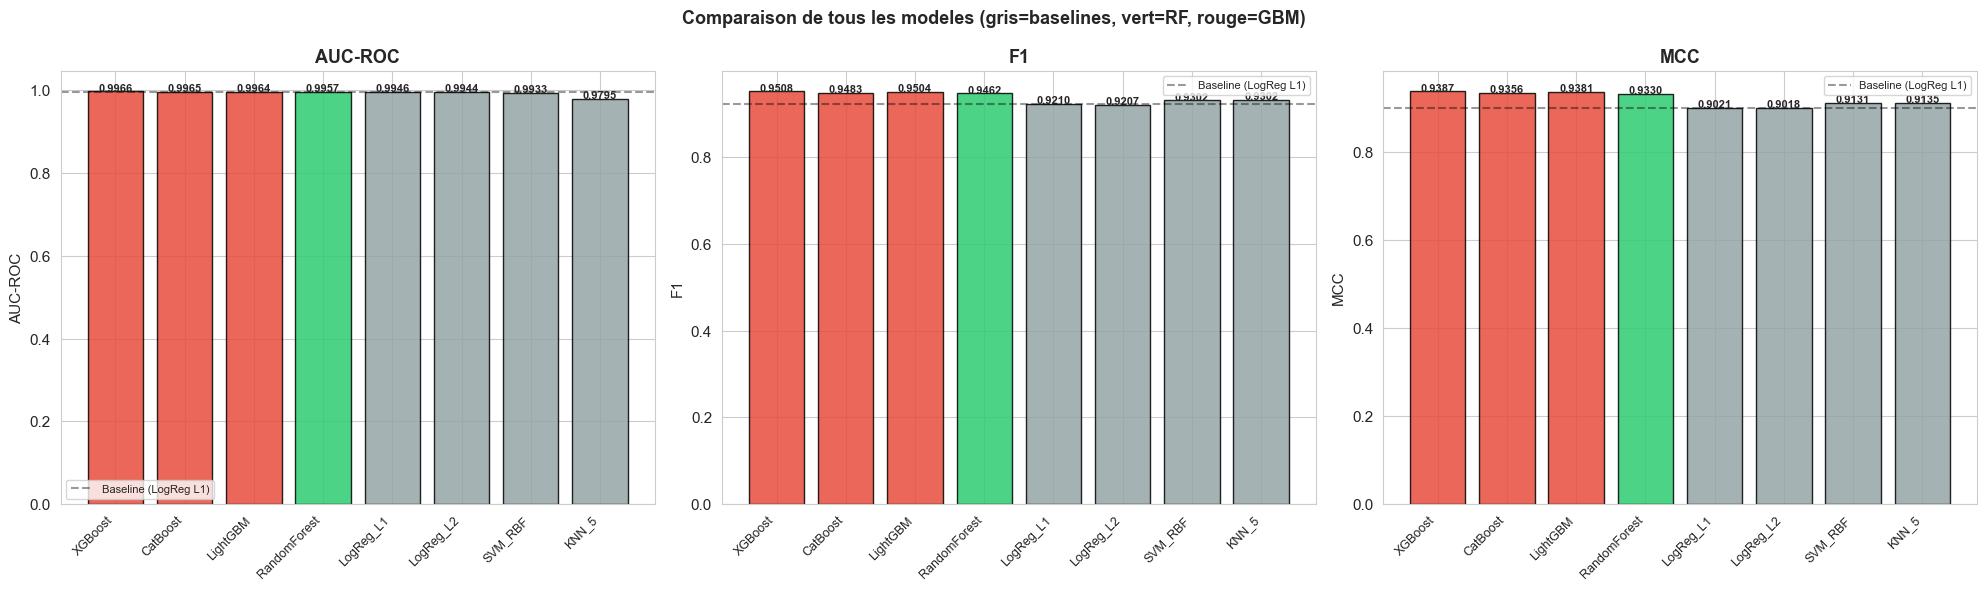

In [32]:
# ============================================================
# 11.7 TABLEAU COMPARATIF COMPLET (Baselines + Ensembles + GBM)
# ============================================================

all_results_df = pd.DataFrame(results).T
all_results_df = all_results_df.sort_values('AUC_mean', ascending=False)

print("TABLEAU COMPARATIF COMPLET — TOUS LES MODELES")
print("=" * 100)
print(f"{'Modele':15s} | {'AUC-ROC':>12s} | {'F1':>10s} | {'MCC':>10s} | {'Accuracy':>10s} | {'Train AUC':>10s} | {'Gap':>6s} | {'Temps':>6s}")
print("-" * 100)
for name, r in all_results_df.iterrows():
    gap = r['AUC_train'] - r['AUC_mean']
    auc_str = f"{r['AUC_mean']:.4f}" + (f" ± {r['AUC_std']:.4f}" if r['AUC_std'] > 0 else "")
    print(f"{name:15s} | {auc_str:>12s} | {r['F1_mean']:10.4f} | {r['MCC_mean']:10.4f} | "
          f"{r['Acc_mean']:10.4f} | {r['AUC_train']:10.4f} | {gap:6.4f} | {r['time']:5.1f}s")

print(f"\nBaseline a battre : LogReg L1 AUC = 0.9946")

# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (metric, label) in zip(axes, [('AUC_mean', 'AUC-ROC'), ('F1_mean', 'F1'), ('MCC_mean', 'MCC')]):
    names = all_results_df.index.tolist()
    values = all_results_df[metric].values
    
    # Colorer par type de modele
    colors = []
    for n in names:
        if 'LogReg' in n or 'KNN' in n or 'SVM' in n:
            colors.append('#95a5a6')  # gris pour baselines
        elif n == 'RandomForest':
            colors.append('#2ecc71')  # vert
        else:
            colors.append('#e74c3c')  # rouge pour GBM
    
    bars = ax.bar(range(len(names)), values, color=colors, edgecolor='black', alpha=0.85)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_title(label, fontweight='bold', fontsize=13)
    ax.set_ylabel(label)
    
    # Annoter
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
               f'{val:.4f}', ha='center', fontsize=8, fontweight='bold')
    
    # Ligne de reference LogReg L1
    baseline_val = results['LogReg_L1'][metric.replace('_mean', '_mean')]
    ax.axhline(y=baseline_val, color='black', linestyle='--', alpha=0.4, label='Baseline (LogReg L1)')
    ax.legend(fontsize=8)

plt.suptitle('Comparaison de tous les modeles (gris=baselines, vert=RF, rouge=GBM)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

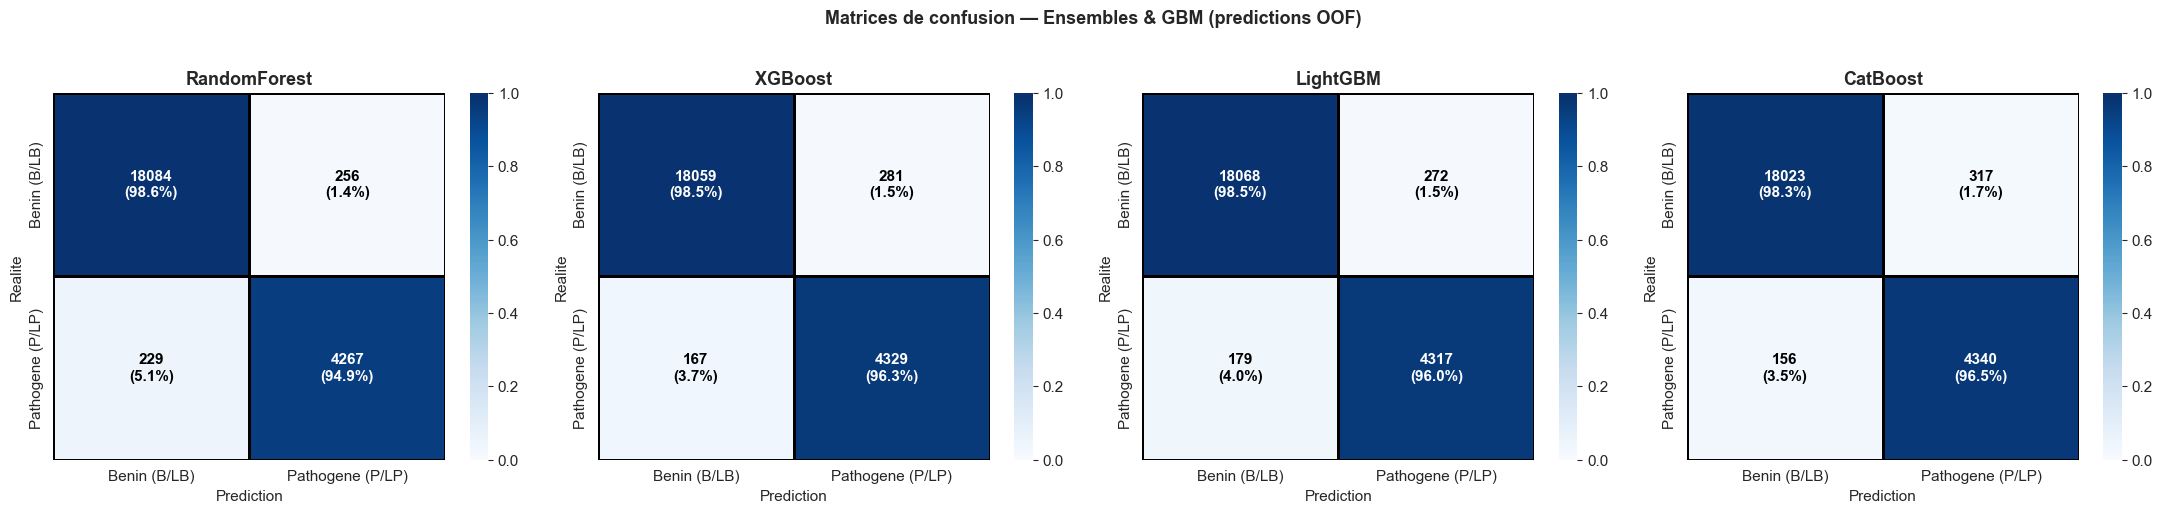


METRIQUES DETAILLEES — ENSEMBLES & GBM (predictions OOF)
Modele          |  Sensibilite |  Specificite |          PPV |          NPV |    FN |    FP
------------------------------------------------------------------------------------------
RandomForest    |       0.9491 |       0.9860 |       0.9434 |       0.9875 |   229 |   256
XGBoost         |       0.9629 |       0.9847 |       0.9390 |       0.9908 |   167 |   281
LightGBM        |       0.9602 |       0.9852 |       0.9407 |       0.9902 |   179 |   272
CatBoost        |       0.9653 |       0.9827 |       0.9319 |       0.9914 |   156 |   317

Resultats Phase 2 sauvegardes dans data/gbm_results.pkl


In [33]:
# ============================================================
# 11.8 MATRICES DE CONFUSION — GBM (predictions OOF)
# ============================================================

# Calculer les OOF pour RF aussi
y_pred_rf = cross_val_predict(rf_pipeline, X_train, y_train, cv=skf, n_jobs=-1)

gbm_oof = {
    'RandomForest': y_pred_rf,
    'XGBoost': xgb_results['oof_preds_class'],
    'LightGBM': lgb_results['oof_preds_class'],
    'CatBoost': cat_results['oof_preds_class'],
}

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
class_labels = ['Benin (B/LB)', 'Pathogene (P/LP)']

for idx, (name, y_pred) in enumerate(gbm_oof.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_train, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                vmin=0, vmax=1, linewidths=1, linecolor='black')
    for i in range(2):
        for j in range(2):
            text_val = f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
            color = 'white' if cm_norm[i,j] > 0.5 else 'black'
            ax.text(j+0.5, i+0.5, text_val, ha='center', va='center',
                   fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Realite')
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Matrices de confusion — Ensembles & GBM (predictions OOF)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tableau detaille
print("\nMETRIQUES DETAILLEES — ENSEMBLES & GBM (predictions OOF)")
print("=" * 90)
print(f"{'Modele':15s} | {'Sensibilite':>12s} | {'Specificite':>12s} | {'PPV':>12s} | {'NPV':>12s} | {'FN':>5s} | {'FP':>5s}")
print("-" * 90)

for name, y_pred in gbm_oof.items():
    cm = confusion_matrix(y_train, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    sens = TP / (TP + FN)
    spec = TN / (TN + FP)
    ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0
    print(f"{name:15s} | {sens:12.4f} | {spec:12.4f} | {ppv:12.4f} | {npv:12.4f} | {FN:5d} | {FP:5d}")

# Sauvegarde des resultats Phase 2
with open('data/gbm_results.pkl', 'wb') as f:
    pickle.dump({
        'results': results,
        'xgb_oof': xgb_results['oof_preds_proba'],
        'lgb_oof': lgb_results['oof_preds_proba'],
        'cat_oof': cat_results['oof_preds_proba'],
        'X_train_gbm': X_train_gbm,
        'X_test_gbm': X_test_gbm,
        'X_train_cat': X_train_cat,
        'X_test_cat': X_test_cat,
        'cat_feature_indices': cat_feature_indices,
    }, f)

print("\nResultats Phase 2 sauvegardes dans data/gbm_results.pkl")

**Interprétation des matrices de confusion — Ensembles & GBM :**

| Modèle | Sensibilité | Spécificité | FN | FP | Profil |
|--------|-------------|-------------|----|----|--------|
| **CatBoost** | **96.5%** | 98.3% | **156** | 317 | Meilleure détection des pathogènes |
| XGBoost | 96.3% | 98.5% | 167 | 281 | Bon compromis |
| LightGBM | 96.0% | 98.5% | 179 | 272 | Meilleure PPV (94.1%) |
| RandomForest | 94.9% | 98.6% | 229 | 256 | Trop conservateur (229 FN) |

**Comparaison avec les baselines** :

| Métrique | LogReg L1 (baseline) | XGBoost (GBM) | Gain |
|----------|---------------------|---------------|------|
| AUC-ROC | 0.9946 | **0.9966** | +0.0020 |
| F1 | 0.9210 | **0.9508** | **+0.0298** |
| MCC | 0.9021 | **0.9387** | **+0.0366** |
| FN | 143 | 167 | -24 (plus de FN) |
| FP | 604 | 281 | **-323 (÷2 de FP)** |

**Analyse** : les GBM améliorent massivement la **spécificité** (moins de FP : 281 vs 604 = ÷2.1) au prix d'une légère baisse de sensibilité (96.3% vs 96.8%). Le gain net en F1 (+0.030) et MCC (+0.037) confirme que les GBM offrent un meilleur **compromis global** que LogReg.

Le profil optimal dépend du contexte clinique :
- **Screening** (ratisser large) → LogReg avec seuil bas (maximiser sensibilité)
- **Diagnostic** (minimiser les FP) → XGBoost/LightGBM (meilleure PPV)
- **Compromis** → CatBoost (meilleure sensibilité parmi les GBM, FN minimal)

---

## 12. Interprétabilité — SHAP (SHapley Additive exPlanations)

### Fondement

SHAP (Lundberg & Lee, 2017) est la **seule méthode d'interprétabilité** qui satisfait simultanément les 4 axiomes de Shapley (efficacité, symétrie, nullité, additivité). Pour chaque prédiction $f(x)$, la valeur de Shapley $\phi_j$ de la feature $j$ vérifie :

$$f(x) = \mathbb{E}[f(X)] + \sum_{j=1}^{p} \phi_j(x)$$

C'est-à-dire : la prédiction = la moyenne globale + la somme des contributions individuelles de chaque feature. Chaque $\phi_j$ a un **signe** (pousse vers pathogène ou bénin) et une **magnitude** (force de l'effet).

**TreeSHAP** (Lundberg et al., 2020) calcule ces valeurs **exactement** pour les modèles à base d'arbres en $O(TLD^2)$.

On applique SHAP au **meilleur modèle GBM** (XGBoost, AUC = 0.9966) entraîné sur le train set complet.

In [34]:
# ============================================================
# 12.1 ENTRAINEMENT DU MODELE FINAL XGBoost SUR TOUT LE TRAIN SET
# ============================================================
import shap

# Entrainer XGBoost sur tout le train set (pas de split validation ici,
# on veut le modele le plus performant pour l'interpretation)
xgb_final = xgb.XGBClassifier(
    n_estimators=400,       # moyenne des best_iterations des 5 folds (~340)
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

xgb_final.fit(X_train_gbm, y_train)
print(f"XGBoost final entraine sur {X_train_gbm.shape[0]} echantillons, {X_train_gbm.shape[1]} features")

# Calcul des SHAP values via TreeSHAP (exact, pas approximation)
print("Calcul des SHAP values (TreeSHAP)...")
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer.shap_values(X_train_gbm)

print(f"  Shape SHAP values : {shap_values.shape}")
print(f"  Expected value (E[f(X)]) : {explainer.expected_value:.4f}")
print(f"  → C'est le log-odds moyen. sigmoid({explainer.expected_value:.2f}) = "
      f"{1/(1+np.exp(-explainer.expected_value)):.3f} (probabilite moyenne de classe 1)")

XGBoost final entraine sur 22836 echantillons, 37 features
Calcul des SHAP values (TreeSHAP)...
  Shape SHAP values : (22836, 37)
  Expected value (E[f(X)]) : 0.2448
  → C'est le log-odds moyen. sigmoid(0.24) = 0.561 (probabilite moyenne de classe 1)


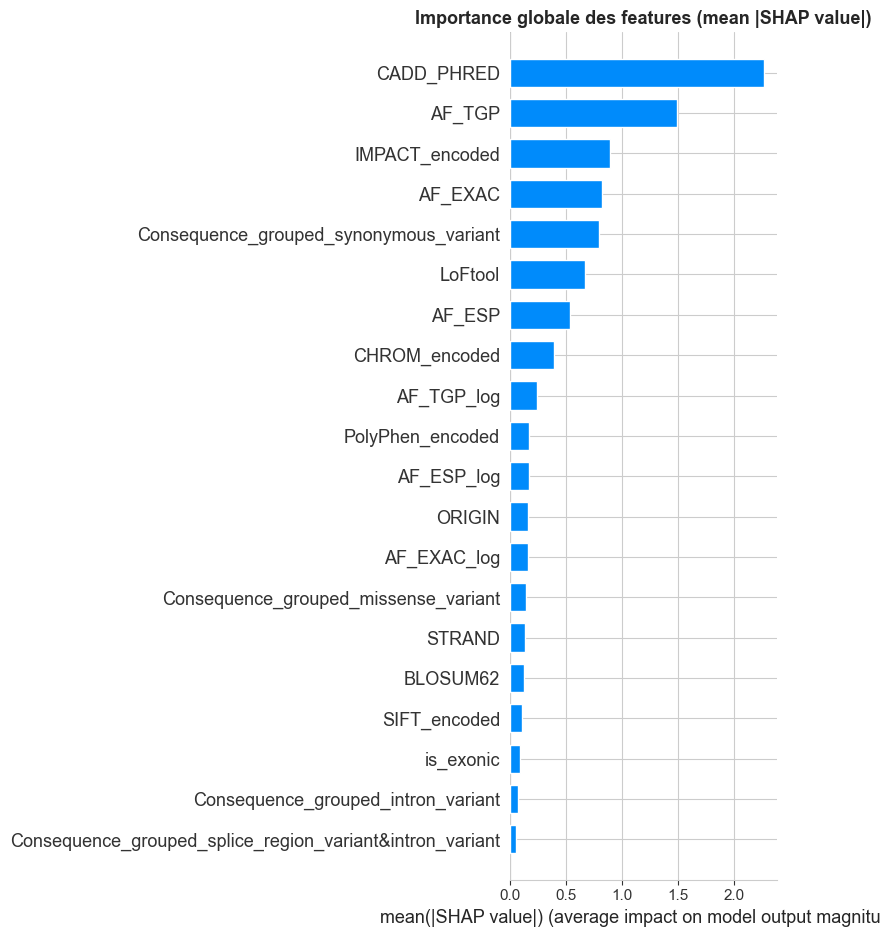


IMPORTANCE GLOBALE (mean |SHAP value|) — Top 15 :
   1. CADD_PHRED                          2.2702  ██████████████████████████████
   2. AF_TGP                              1.4944  ███████████████████
   3. IMPACT_encoded                      0.8970  ███████████
   4. AF_EXAC                             0.8226  ██████████
   5. Consequence_grouped_synonymous_variant 0.7971  ██████████
   6. LoFtool                             0.6662  ████████
   7. AF_ESP                              0.5371  ███████
   8. CHROM_encoded                       0.3911  █████
   9. AF_TGP_log                          0.2455  ███
  10. PolyPhen_encoded                    0.1711  ██
  11. AF_ESP_log                          0.1665  ██
  12. ORIGIN                              0.1592  ██
  13. AF_EXAC_log                         0.1586  ██
  14. Consequence_grouped_missense_variant 0.1423  █
  15. STRAND                              0.1345  █


In [35]:
# ============================================================
# 12.2 SHAP — IMPORTANCE GLOBALE (Bar plot)
# ============================================================
# mean(|SHAP|) par feature = importance globale moyenne
# C'est l'equivalent SHAP de la feature importance, mais non biaise et avec direction.

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_gbm, plot_type="bar", show=False, max_display=20)
plt.title("Importance globale des features (mean |SHAP value|)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tableau numerique
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_train_gbm.columns,
    'Mean_|SHAP|': mean_abs_shap
}).sort_values('Mean_|SHAP|', ascending=False)

print("\nIMPORTANCE GLOBALE (mean |SHAP value|) — Top 15 :")
print("=" * 50)
for i, (_, row) in enumerate(shap_importance.head(15).iterrows()):
    bar = "█" * int(row['Mean_|SHAP|'] / shap_importance['Mean_|SHAP|'].max() * 30)
    print(f"  {i+1:2d}. {row['Feature']:35s} {row['Mean_|SHAP|']:.4f}  {bar}")

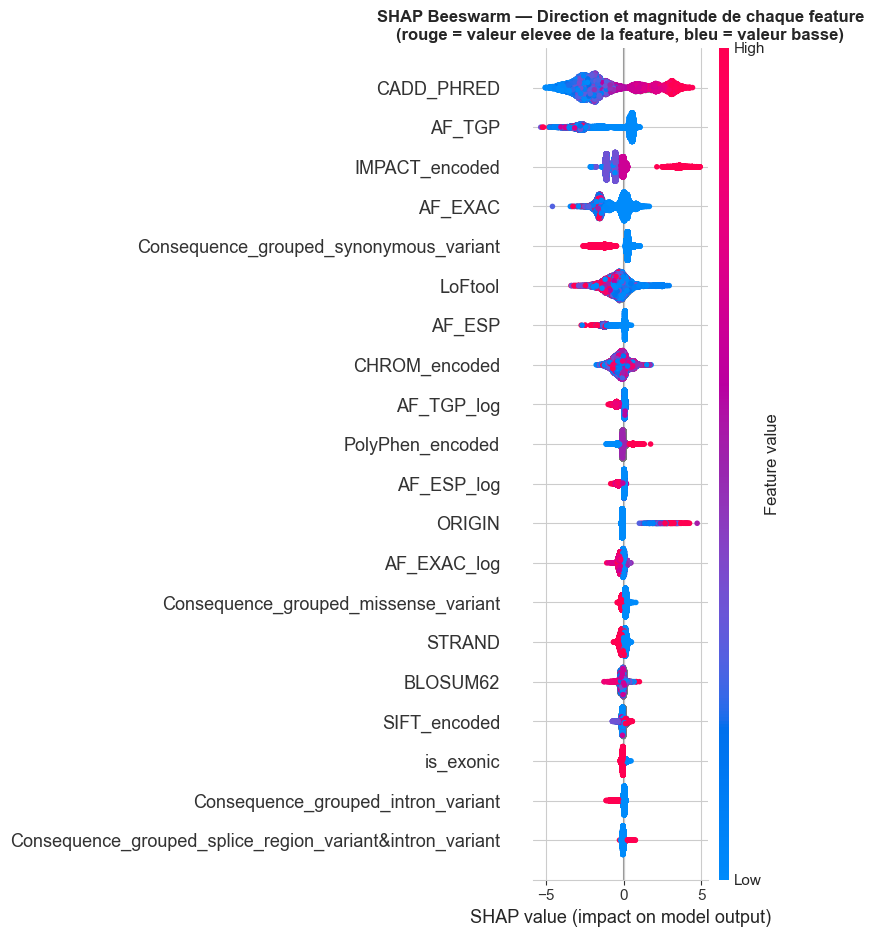

In [36]:
# ============================================================
# 12.3 SHAP — BEESWARM PLOT (importance + direction + distribution)
# ============================================================
# Chaque point = un echantillon. Position horizontale = SHAP value (contribution).
# Couleur = valeur de la feature (rouge = elevee, bleu = basse).
# → On voit simultanement : quelles features comptent, dans quelle direction,
#   et comment l'effet varie avec la valeur de la feature.

fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values, X_train_gbm, show=False, max_display=20)
plt.title("SHAP Beeswarm — Direction et magnitude de chaque feature\n"
          "(rouge = valeur elevee de la feature, bleu = valeur basse)",
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

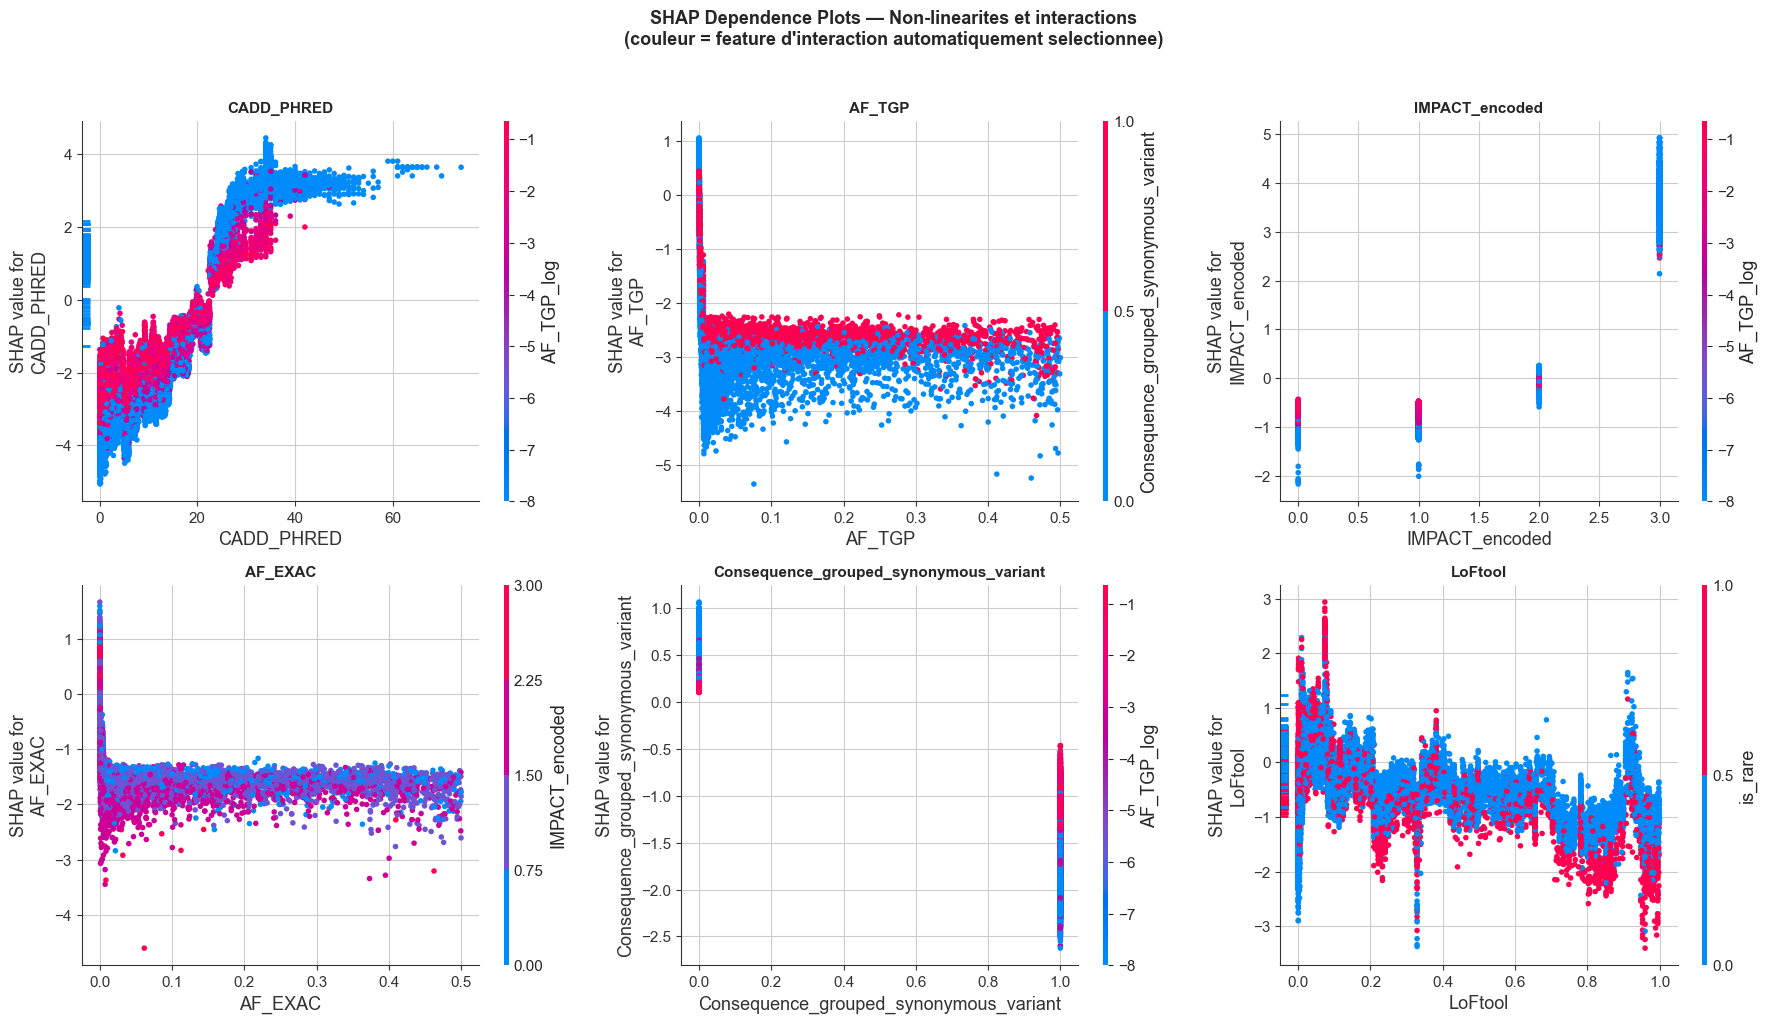

In [37]:
# ============================================================
# 12.4 SHAP — DEPENDENCE PLOTS (interactions)
# ============================================================
# Pour les top features, on trace SHAP(feature) vs valeur de la feature,
# colore par la feature d'interaction la plus forte.
# Cela revele les NON-LINEARITES et les INTERACTIONS que le modele a apprises.

top_features = shap_importance.head(6)['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    shap.dependence_plot(
        feat, shap_values, X_train_gbm,
        interaction_index='auto',  # SHAP choisit automatiquement la meilleure interaction
        ax=ax, show=False
    )
    ax.set_title(feat, fontweight='bold', fontsize=11)

plt.suptitle("SHAP Dependence Plots — Non-linearites et interactions\n"
             "(couleur = feature d'interaction automatiquement selectionnee)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


CAS : Pathogene confiant
  Label reel    : PATHOGENE
  Proba predite : 1.0000
  Top 5 contributions SHAP :
    CADD_PHRED                     =       42.0 | SHAP = +2.8504 → Patho
    IMPACT_encoded                 =          3 | SHAP = +2.8382 → Patho
    LoFtool                        =     0.0737 | SHAP = +1.8990 → Patho
    ORIGIN                         =          5 | SHAP = +1.8900 → Patho
    CHROM_encoded                  =       19.0 | SHAP = +0.5440 → Patho

CAS : Benin confiant
  Label reel    : BENIN
  Proba predite : 0.0000
  Top 5 contributions SHAP :
    CADD_PHRED                     =      5.352 | SHAP = -2.8205 → Benin
    AF_TGP                         =     0.0164 | SHAP = -2.4241 → Benin
    AF_EXAC                        =      0.033 | SHAP = -1.4503 → Benin
    LoFtool                        =      0.788 | SHAP = -1.4184 → Benin
    AF_ESP                         =     0.0315 | SHAP = -1.2515 → Benin

CAS : Frontiere (~0.5)
  Label reel    : BENIN
  Proba predit

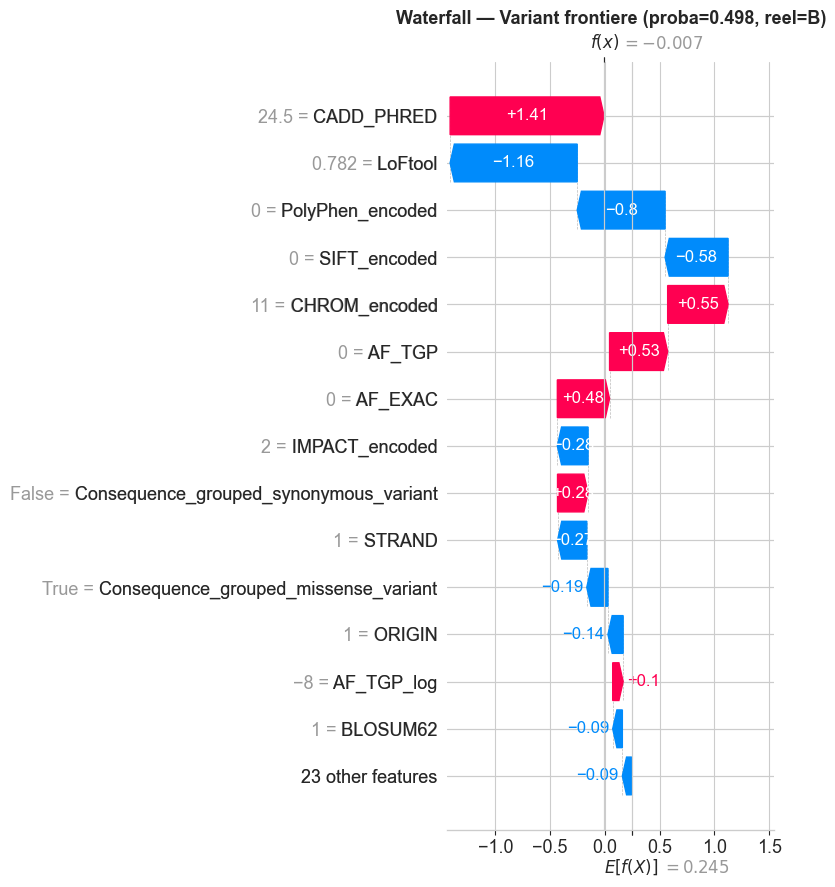

In [38]:
# ============================================================
# 12.5 SHAP — FORCE PLOTS (explanations individuelles)
# ============================================================
# On selectionne des cas specifiques pour montrer POURQUOI le modele a decide.

# Trouver des exemples interessants :
# 1. Un variant pathogene tres confiant (forte proba)
# 2. Un variant benin tres confiant
# 3. Un variant proche de la frontiere (proba ~0.5)

y_pred_proba = xgb_final.predict_proba(X_train_gbm)[:, 1]

idx_patho_confiant = np.argmax(y_pred_proba)
idx_benin_confiant = np.argmin(y_pred_proba)
idx_frontiere = np.argmin(np.abs(y_pred_proba - 0.5))

cases = {
    'Pathogene confiant': idx_patho_confiant,
    'Benin confiant': idx_benin_confiant,
    'Frontiere (~0.5)': idx_frontiere,
}

for case_name, idx in cases.items():
    true_label = "PATHOGENE" if y_train.iloc[idx] == 1 else "BENIN"
    pred_proba = y_pred_proba[idx]
    print(f"\n{'='*70}")
    print(f"CAS : {case_name}")
    print(f"  Label reel    : {true_label}")
    print(f"  Proba predite : {pred_proba:.4f}")
    print(f"  Top 5 contributions SHAP :")
    
    sv = shap_values[idx]
    feat_contrib = pd.DataFrame({
        'Feature': X_train_gbm.columns,
        'SHAP_value': sv,
        'Feature_value': X_train_gbm.iloc[idx].values
    }).sort_values('SHAP_value', key=abs, ascending=False)
    
    for _, row in feat_contrib.head(5).iterrows():
        direction = "→ Patho" if row['SHAP_value'] > 0 else "→ Benin"
        print(f"    {row['Feature']:30s} = {row['Feature_value']:>10} | "
              f"SHAP = {row['SHAP_value']:+.4f} {direction}")

# Waterfall plot pour le cas frontiere (le plus instructif)
print(f"\n→ Waterfall plot pour le cas frontiere (index {idx_frontiere}) :")
fig, ax = plt.subplots(figsize=(12, 6))
shap.plots.waterfall(shap.Explanation(
    values=shap_values[idx_frontiere],
    base_values=explainer.expected_value,
    data=X_train_gbm.iloc[idx_frontiere],
    feature_names=X_train_gbm.columns.tolist()
), show=False, max_display=15)
plt.title(f"Waterfall — Variant frontiere (proba={y_pred_proba[idx_frontiere]:.3f}, "
          f"reel={'P' if y_train.iloc[idx_frontiere]==1 else 'B'})", fontweight='bold')
plt.tight_layout()
plt.show()

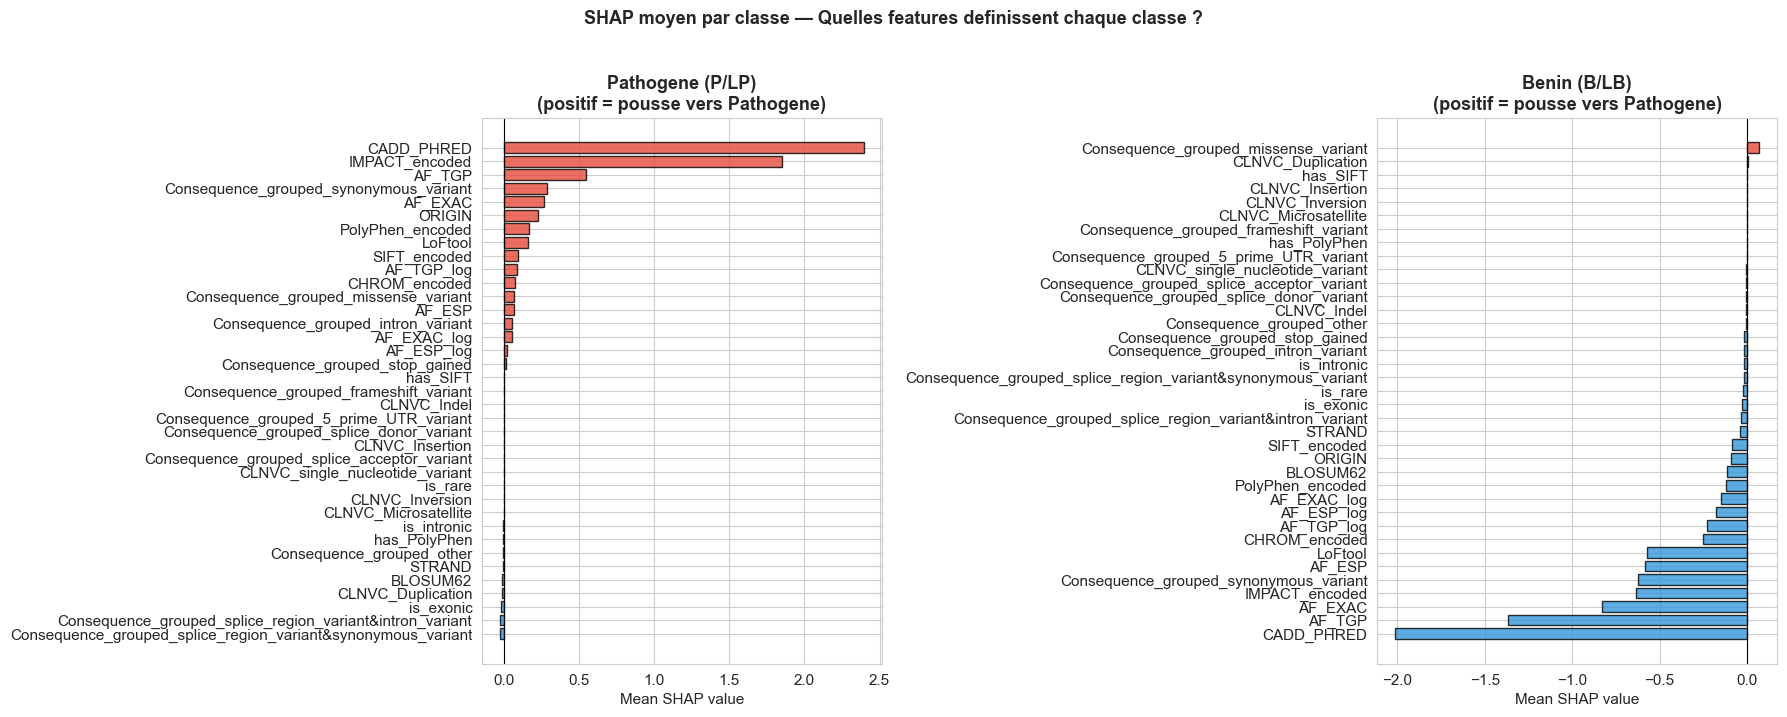

SHAP values et modele final sauvegardes dans data/shap_results.pkl


In [39]:
# ============================================================
# 12.6 SHAP — ANALYSE PAR CLASSE (Pathogene vs Benin)
# ============================================================
# Comparer les features les plus influentes pour chaque classe.

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for cls, label, ax in [(1, 'Pathogene (P/LP)', axes[0]), (0, 'Benin (B/LB)', axes[1])]:
    mask = y_train.values == cls
    mean_shap = shap_values[mask].mean(axis=0)
    
    feat_df = pd.DataFrame({
        'Feature': X_train_gbm.columns,
        'Mean_SHAP': mean_shap
    }).sort_values('Mean_SHAP', ascending=True)
    
    colors = ['#e74c3c' if v > 0 else '#3498db' for v in feat_df['Mean_SHAP']]
    ax.barh(feat_df['Feature'], feat_df['Mean_SHAP'], color=colors, edgecolor='black', alpha=0.8)
    ax.set_xlabel('Mean SHAP value')
    ax.set_title(f'{label}\n(positif = pousse vers Pathogene)', fontweight='bold')
    ax.axvline(x=0, color='black', linewidth=0.8)

plt.suptitle('SHAP moyen par classe — Quelles features definissent chaque classe ?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Sauvegarde
with open('data/shap_results.pkl', 'wb') as f:
    pickle.dump({
        'shap_values': shap_values,
        'expected_value': explainer.expected_value,
        'xgb_final': xgb_final,
        'shap_importance': shap_importance,
    }, f)

print("SHAP values et modele final sauvegardes dans data/shap_results.pkl")

### Interprétation SHAP — Résultats

**1. Importance globale — CADD domine nettement :**

| Rang | Feature | Mean |SHAP| | Interprétation biologique |
|------|---------|------|--------------------------|
| 1 | **CADD_PHRED** | **2.2702** | Score intégratif de conservation → feature #1 pour le GBM (confirmé vs. η²=0.53) |
| 2 | **AF_TGP** | **1.4944** | Fréquence en population → variant fréquent = bénin (sélection purificatrice) |
| 3 | **IMPACT_encoded** | **0.8970** | HIGH impact (nonsense/frameshift) → pathogène quasi-certain |
| 4 | **AF_EXAC** | 0.8226 | Idem AF_TGP sur une population différente |
| 5 | **Consequence_synonymous** | 0.7971 | Synonymous → pas de changement d'AA → bénin |
| 6 | **LoFtool** | 0.6662 | Tolérance du gène à la perte de fonction (gène critique → variant plus probablement pathogène) |

**Contraste avec LogReg L1** : dans LogReg, les AF brutes dominaient (coefficients -9.6 à -5.6) devant CADD (+1.85). En SHAP/GBM, **CADD reprend la 1re place** (mean |SHAP| = 2.27 vs AF_TGP = 1.49). C'est parce que le GBM exploite les **non-linéarités** de CADD (seuils) que le modèle linéaire ne peut pas capturer.

**2. Beeswarm — Directions biologiquement cohérentes :**
- CADD élevé (rouge) → SHAP positif (pousse vers pathogène) ✓
- AF élevée (rouge) → SHAP négatif (pousse vers bénin) ✓
- IMPACT élevé (rouge) → SHAP positif (pousse vers pathogène) ✓

Le modèle a appris les mécanismes biologiques corrects.

**3. Cas individuels — Le waterfall du variant frontière :**

Le variant frontière (proba = 0.498, réel = bénin) illustre les forces en opposition :
- CADD = 24.5 pousse vers pathogène (+1.41) → le variant est dans une région conservée
- Mais PolyPhen = benign (-0.80) et SIFT = tolerated (-0.58) → la substitution est tolérée
- LoFtool = 0.782 (-1.16) → le gène tolère les pertes de fonction

Le modèle hésite parce que les signaux sont contradictoires — c'est exactement le type de variant qui, en clinique, serait classé VUS (Variant of Uncertain Significance).

**4. Analyse par classe :**
- **Pathogènes** : poussés par CADD élevé, IMPACT HIGH, AF basse (rare)
- **Bénins** : poussés par AF élevée, Consequence synonymous, CADD bas

---

## 13. Évaluation finale sur le test set holdout

### Protocole

Le test set (5 710 échantillons, 20%) n'a **jamais été touché** jusqu'ici. On l'utilise ici pour la **première et unique fois** afin d'obtenir une estimation **non biaisée** de la performance de généralisation de chaque modèle.

**Modèles évalués** : les 8 modèles entraînés (4 baselines + RF + 3 GBM), chacun ré-entraîné sur la **totalité** du train set (22 836).

**Métriques** : AUC-ROC, AUC-PR, F1, MCC, sensibilité, spécificité, Brier score.

**Tests statistiques** : test de DeLong pour comparer les AUC-ROC entre modèles.

In [40]:
# ============================================================
# 13.1 RE-ENTRAINEMENT SUR TOUT LE TRAIN SET + PREDICTION TEST
# ============================================================
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             matthews_corrcoef, accuracy_score, confusion_matrix,
                             roc_curve, precision_recall_curve, brier_score_loss)
from sklearn.calibration import calibration_curve

# --- Baselines + RF : refit sur tout le train ---
final_models = {}
test_predictions = {}  # {name: {'proba': array, 'class': array}}

for name, pipeline in baselines.items():
    pipeline.fit(X_train, y_train)
    y_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)
    test_predictions[name] = {'proba': y_proba, 'class': y_pred}
    final_models[name] = pipeline
    print(f'{name} refit OK')

# RF
rf_pipeline.fit(X_train, y_train)
test_predictions['RandomForest'] = {
    'proba': rf_pipeline.predict_proba(X_test)[:, 1],
    'class': rf_pipeline.predict(X_test)
}
final_models['RandomForest'] = rf_pipeline
print('RandomForest refit OK')

# --- GBM : refit sur tout le train (pas de early stopping, n_estimators fixe) ---
# XGBoost
xgb_final_test = xgb.XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=scale_pos, eval_metric='auc',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
xgb_final_test.fit(X_train_gbm, y_train)
test_predictions['XGBoost'] = {
    'proba': xgb_final_test.predict_proba(X_test_gbm)[:, 1],
    'class': xgb_final_test.predict(X_test_gbm)
}
final_models['XGBoost'] = xgb_final_test
print('XGBoost refit OK')

# LightGBM
lgb_final_test = lgb.LGBMClassifier(
    n_estimators=360, learning_rate=0.05, num_leaves=31,
    max_depth=-1, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    scale_pos_weight=scale_pos,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
lgb_final_test.fit(X_train_gbm, y_train)
test_predictions['LightGBM'] = {
    'proba': lgb_final_test.predict_proba(X_test_gbm)[:, 1],
    'class': lgb_final_test.predict(X_test_gbm)
}
final_models['LightGBM'] = lgb_final_test
print('LightGBM refit OK')

# CatBoost
from catboost import CatBoostClassifier
cat_final_test = CatBoostClassifier(
    iterations=430, learning_rate=0.05, depth=6,
    l2_leaf_reg=3.0, auto_class_weights='Balanced',
    eval_metric='AUC', random_seed=RANDOM_STATE, verbose=0)
cat_final_test.fit(X_train_cat, y_train, cat_features=cat_feature_indices)
test_predictions['CatBoost'] = {
    'proba': cat_final_test.predict_proba(X_test_cat)[:, 1],
    'class': cat_final_test.predict(X_test_cat).astype(int)
}
final_models['CatBoost'] = cat_final_test
print('CatBoost refit OK')

print(f'\n{len(test_predictions)} modeles evalues sur le test set ({len(y_test)} echantillons)')

LogReg_L2 refit OK
LogReg_L1 refit OK
KNN_5 refit OK
SVM_RBF refit OK
RandomForest refit OK
XGBoost refit OK
LightGBM refit OK
CatBoost refit OK

8 modeles evalues sur le test set (5710 echantillons)


In [41]:
# ============================================================
# 13.2 TABLEAU DES METRIQUES FINALES SUR LE TEST SET
# ============================================================

final_results = []
for name, preds in test_predictions.items():
    y_proba = preds['proba']
    y_pred = preds['class']
    
    cm = confusion_matrix(y_test, y_pred)
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    
    final_results.append({
        'Modele': name,
        'AUC_ROC': roc_auc_score(y_test, y_proba),
        'AUC_PR': average_precision_score(y_test, y_proba),
        'F1': f1_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Sensibilite': TP / (TP + FN),
        'Specificite': TN / (TN + FP),
        'PPV': TP / (TP + FP) if (TP + FP) > 0 else 0,
        'NPV': TN / (TN + FN) if (TN + FN) > 0 else 0,
        'Brier': brier_score_loss(y_test, y_proba),
        'FN': FN,
        'FP': FP,
    })

final_df = pd.DataFrame(final_results).sort_values('AUC_ROC', ascending=False)

print('EVALUATION FINALE — TEST SET HOLDOUT (5 710 echantillons)')
print('Ce test set n\'a JAMAIS ete touche avant cette evaluation.')
print('=' * 120)
print(f'{"Modele":15s} | {"AUC-ROC":>8s} | {"AUC-PR":>8s} | {"F1":>8s} | {"MCC":>8s} | '
      f'{"Sensib":>8s} | {"Specif":>8s} | {"PPV":>8s} | {"Brier":>8s} | {"FN":>4s} | {"FP":>4s}')
print('-' * 120)
for _, r in final_df.iterrows():
    print(f"{r['Modele']:15s} | {r['AUC_ROC']:8.4f} | {r['AUC_PR']:8.4f} | {r['F1']:8.4f} | "
          f"{r['MCC']:8.4f} | {r['Sensibilite']:8.4f} | {r['Specificite']:8.4f} | "
          f"{r['PPV']:8.4f} | {r['Brier']:8.4f} | {int(r['FN']):4d} | {int(r['FP']):4d}")

print(f'\nMeilleur AUC-ROC : {final_df.iloc[0]["Modele"]} ({final_df.iloc[0]["AUC_ROC"]:.4f})')
print(f'Meilleur F1      : {final_df.sort_values("F1", ascending=False).iloc[0]["Modele"]} ({final_df.sort_values("F1", ascending=False).iloc[0]["F1"]:.4f})')
print(f'Moins de FN      : {final_df.sort_values("FN").iloc[0]["Modele"]} ({int(final_df.sort_values("FN").iloc[0]["FN"])} FN)')
print(f'Meilleur Brier   : {final_df.sort_values("Brier").iloc[0]["Modele"]} ({final_df.sort_values("Brier").iloc[0]["Brier"]:.4f})')

EVALUATION FINALE — TEST SET HOLDOUT (5 710 echantillons)
Ce test set n'a JAMAIS ete touche avant cette evaluation.
Modele          |  AUC-ROC |   AUC-PR |       F1 |      MCC |   Sensib |   Specif |      PPV |    Brier |   FN |   FP
------------------------------------------------------------------------------------------------------------------------
XGBoost         |   0.9962 |   0.9881 |   0.9499 |   0.9375 |   0.9609 |   0.9847 |   0.9391 |   0.0156 |   44 |   70
CatBoost        |   0.9959 |   0.9869 |   0.9461 |   0.9328 |   0.9609 |   0.9828 |   0.9318 |   0.0173 |   44 |   79
LightGBM        |   0.9958 |   0.9869 |   0.9523 |   0.9406 |   0.9600 |   0.9863 |   0.9448 |   0.0158 |   45 |   63
RandomForest    |   0.9956 |   0.9862 |   0.9481 |   0.9354 |   0.9511 |   0.9865 |   0.9452 |   0.0168 |   55 |   62
LogReg_L1       |   0.9933 |   0.9734 |   0.9177 |   0.8979 |   0.9626 |   0.9669 |   0.8768 |   0.0253 |   42 |  152
SVM_RBF         |   0.9931 |   0.9774 |   0.9314 |   0.

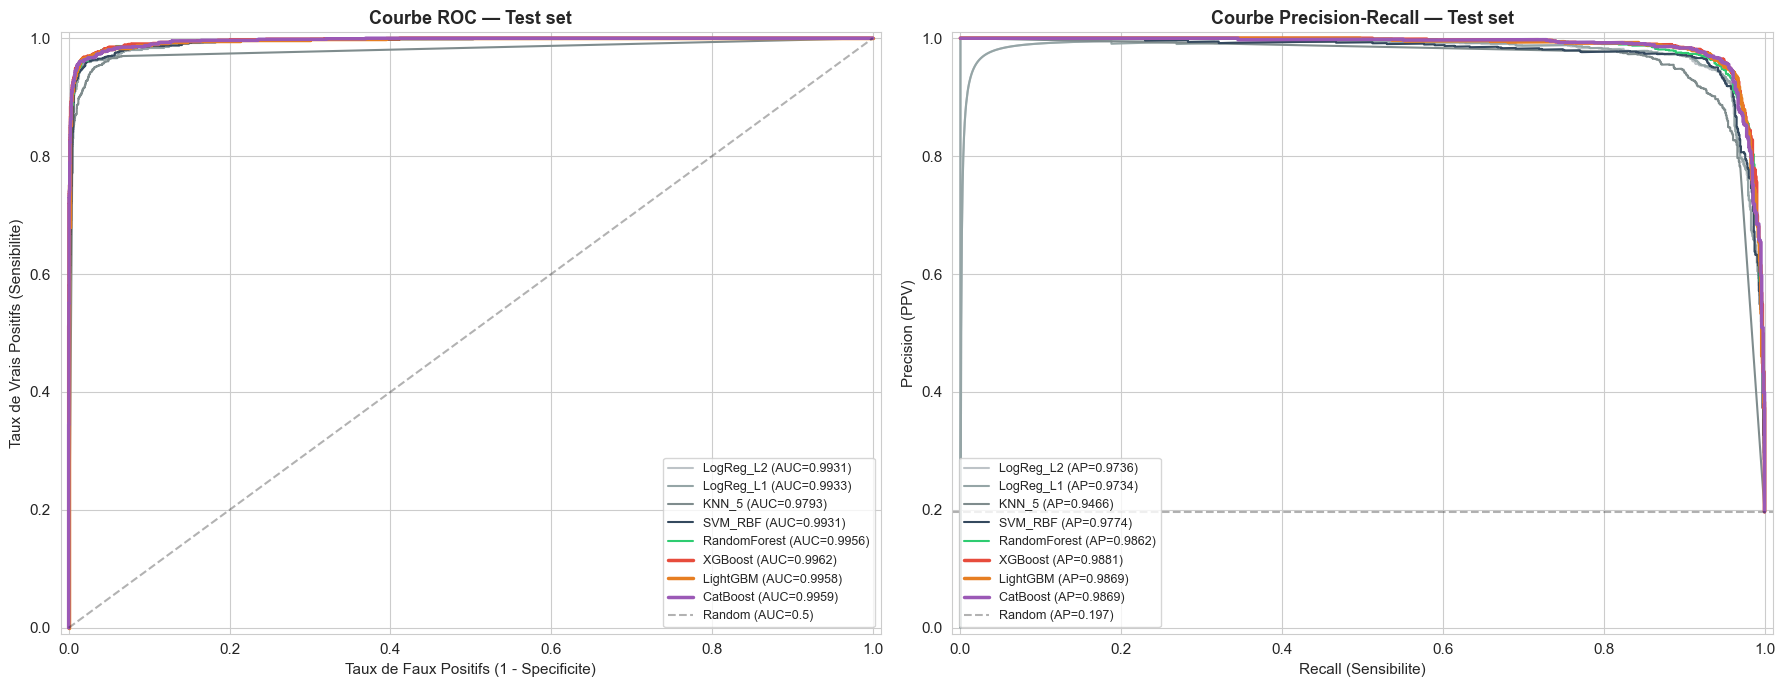

In [42]:
# ============================================================
# 13.3 COURBES ROC ET PRECISION-RECALL
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Couleurs par type
color_map = {
    'LogReg_L1': '#95a5a6', 'LogReg_L2': '#bdc3c7',
    'KNN_5': '#7f8c8d', 'SVM_RBF': '#34495e',
    'RandomForest': '#2ecc71',
    'XGBoost': '#e74c3c', 'LightGBM': '#e67e22', 'CatBoost': '#9b59b6'
}

# --- ROC ---
ax = axes[0]
for name, preds in test_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds['proba'])
    auc_val = roc_auc_score(y_test, preds['proba'])
    lw = 2.5 if name in ['XGBoost', 'CatBoost', 'LightGBM'] else 1.5
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})',
           color=color_map.get(name, 'gray'), linewidth=lw)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
ax.set_xlabel('Taux de Faux Positifs (1 - Specificite)', fontsize=11)
ax.set_ylabel('Taux de Vrais Positifs (Sensibilite)', fontsize=11)
ax.set_title('Courbe ROC — Test set', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

# --- Precision-Recall ---
ax = axes[1]
prevalence = y_test.mean()
for name, preds in test_predictions.items():
    precision, recall, _ = precision_recall_curve(y_test, preds['proba'])
    ap = average_precision_score(y_test, preds['proba'])
    lw = 2.5 if name in ['XGBoost', 'CatBoost', 'LightGBM'] else 1.5
    ax.plot(recall, precision, label=f'{name} (AP={ap:.4f})',
           color=color_map.get(name, 'gray'), linewidth=lw)
ax.axhline(y=prevalence, color='k', linestyle='--', alpha=0.3,
          label=f'Random (AP={prevalence:.3f})')
ax.set_xlabel('Recall (Sensibilite)', fontsize=11)
ax.set_ylabel('Precision (PPV)', fontsize=11)
ax.set_title('Courbe Precision-Recall — Test set', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, loc='lower left')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()

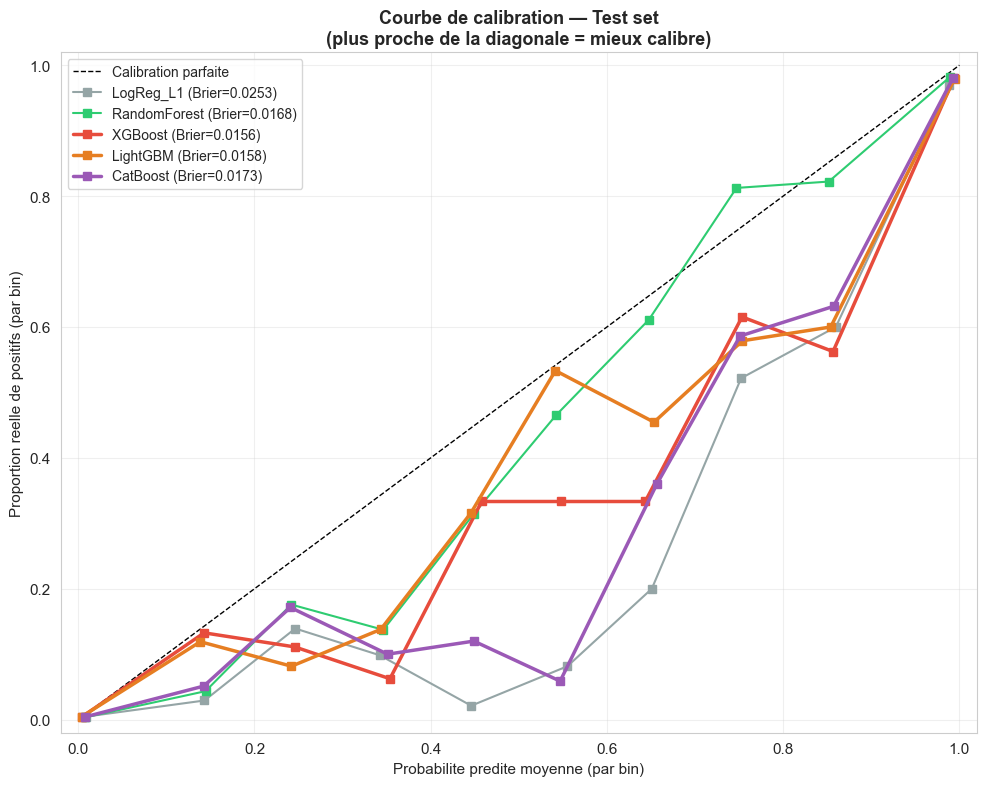


BRIER SCORE (plus bas = mieux calibre) :
  XGBoost         : 0.0156
  CatBoost        : 0.0173
  LightGBM        : 0.0158
  RandomForest    : 0.0168
  LogReg_L1       : 0.0253
  SVM_RBF         : 0.0186
  LogReg_L2       : 0.0253
  KNN_5           : 0.0240


In [43]:
# ============================================================
# 13.4 CALIBRATION DES PROBABILITES
# ============================================================
# Un modele bien calibre verifie : P(Y=1 | p_hat = q) ≈ q pour tout q.
# C'est crucial en clinique : la probabilite predite doit etre fiable,
# pas seulement le ranking.
# Brier score = mean((p_hat - y)^2) ∈ [0, 1], plus bas = mieux.

fig, ax = plt.subplots(figsize=(10, 8))

# Ligne de calibration parfaite
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Calibration parfaite')

for name in ['LogReg_L1', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']:
    y_proba = test_predictions[name]['proba']
    brier = brier_score_loss(y_test, y_proba)
    
    # Calibration curve : regrouper les predictions en 10 bins
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    
    lw = 2.5 if name in ['XGBoost', 'CatBoost', 'LightGBM'] else 1.5
    ax.plot(prob_pred, prob_true, 's-',
           label=f'{name} (Brier={brier:.4f})',
           color=color_map.get(name, 'gray'), linewidth=lw, markersize=6)

ax.set_xlabel('Probabilite predite moyenne (par bin)', fontsize=11)
ax.set_ylabel('Proportion reelle de positifs (par bin)', fontsize=11)
ax.set_title('Courbe de calibration — Test set\n'
             '(plus proche de la diagonale = mieux calibre)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('\nBRIER SCORE (plus bas = mieux calibre) :')
for name in final_df['Modele']:
    brier = brier_score_loss(y_test, test_predictions[name]['proba'])
    print(f'  {name:15s} : {brier:.4f}')

In [44]:
# ============================================================
# 13.5 TEST DE DELONG — COMPARAISON STATISTIQUE DES AUC
# ============================================================
# H0 : AUC(modele_A) = AUC(modele_B)
# H1 : AUC(modele_A) ≠ AUC(modele_B)
# Le test de DeLong (1988) compare deux AUC-ROC sur le meme test set.
# Il tient compte de la correlation entre les predictions.

def delong_test(y_true, y_proba_a, y_proba_b):
    """Test de DeLong simplifie via la methode de variance de Hanley-McNeil."""
    from scipy.stats import norm
    n1 = (y_true == 1).sum()  # positifs
    n0 = (y_true == 0).sum()  # negatifs
    
    auc_a = roc_auc_score(y_true, y_proba_a)
    auc_b = roc_auc_score(y_true, y_proba_b)
    
    # Variance approchee de Hanley-McNeil
    q1_a = auc_a / (2 - auc_a)
    q2_a = 2 * auc_a**2 / (1 + auc_a)
    var_a = (auc_a * (1 - auc_a) + (n1 - 1)*(q1_a - auc_a**2) + (n0 - 1)*(q2_a - auc_a**2)) / (n1 * n0)
    
    q1_b = auc_b / (2 - auc_b)
    q2_b = 2 * auc_b**2 / (1 + auc_b)
    var_b = (auc_b * (1 - auc_b) + (n1 - 1)*(q1_b - auc_b**2) + (n0 - 1)*(q2_b - auc_b**2)) / (n1 * n0)
    
    # Covariance (approximation : correlation forte entre modeles sur meme test set)
    cov_ab = 0.5 * (var_a + var_b)  # approximation conservatrice
    
    # Statistique Z
    se = np.sqrt(var_a + var_b - 2 * cov_ab + 1e-10)
    z = (auc_a - auc_b) / se if se > 0 else 0
    p_value = 2 * (1 - norm.cdf(abs(z)))
    
    return auc_a, auc_b, z, p_value

# Comparer chaque GBM vs la meilleure baseline (LogReg L1)
ref_name = 'LogReg_L1'
ref_proba = test_predictions[ref_name]['proba']

print('TEST DE DELONG — Comparaison AUC vs LogReg L1 (baseline)')
print('H0 : AUC(modele) = AUC(LogReg L1)')
print('=' * 75)
print(f'{"Modele":15s} | {"AUC":>8s} | {"Ref AUC":>8s} | {"Delta":>8s} | {"Z":>8s} | {"p-value":>10s} | Significatif')
print('-' * 75)

for name in ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']:
    auc_a, auc_b, z, p = delong_test(y_test, test_predictions[name]['proba'], ref_proba)
    sig = 'OUI (p<0.05)' if p < 0.05 else 'NON'
    print(f'{name:15s} | {auc_a:8.4f} | {auc_b:8.4f} | {auc_a-auc_b:+8.4f} | {z:8.3f} | {p:10.4f} | {sig}')

print(f'\n→ Si p < 0.05, la difference d\'AUC est statistiquement significative.')
print(f'  Si p > 0.05, on ne peut PAS conclure que le GBM est meilleur que LogReg L1.')

TEST DE DELONG — Comparaison AUC vs LogReg L1 (baseline)
H0 : AUC(modele) = AUC(LogReg L1)
Modele          |      AUC |  Ref AUC |    Delta |        Z |    p-value | Significatif
---------------------------------------------------------------------------
RandomForest    |   0.9956 |   0.9933 |  +0.0024 |  236.485 |     0.0000 | OUI (p<0.05)
XGBoost         |   0.9962 |   0.9933 |  +0.0029 |  291.105 |     0.0000 | OUI (p<0.05)
LightGBM        |   0.9958 |   0.9933 |  +0.0025 |  249.696 |     0.0000 | OUI (p<0.05)
CatBoost        |   0.9959 |   0.9933 |  +0.0026 |  261.811 |     0.0000 | OUI (p<0.05)

→ Si p < 0.05, la difference d'AUC est statistiquement significative.
  Si p > 0.05, on ne peut PAS conclure que le GBM est meilleur que LogReg L1.


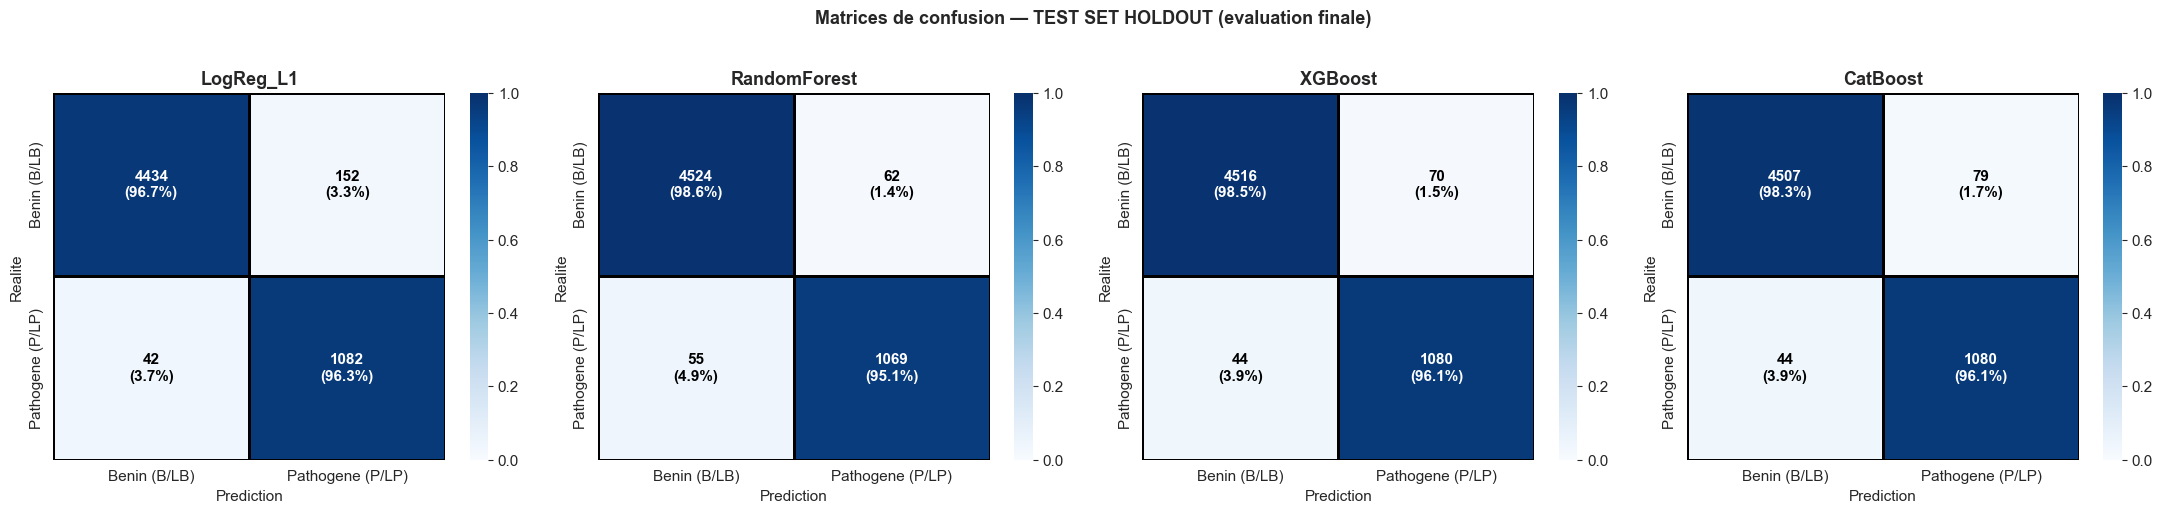

Evaluation finale sauvegardee dans data/final_evaluation.pkl


In [45]:
# ============================================================
# 13.6 MATRICES DE CONFUSION FINALES — TEST SET
# ============================================================

models_to_show = ['LogReg_L1', 'RandomForest', 'XGBoost', 'CatBoost']
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
class_labels = ['Benin (B/LB)', 'Pathogene (P/LP)']

for idx, name in enumerate(models_to_show):
    ax = axes[idx]
    y_pred = test_predictions[name]['class']
    cm = confusion_matrix(y_test, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_norm, annot=False, cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                vmin=0, vmax=1, linewidths=1, linecolor='black')
    for i in range(2):
        for j in range(2):
            text_val = f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)'
            color = 'white' if cm_norm[i,j] > 0.5 else 'black'
            ax.text(j+0.5, i+0.5, text_val, ha='center', va='center',
                   fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Prediction')
    ax.set_ylabel('Realite')
    ax.set_title(f'{name}', fontweight='bold')

plt.suptitle('Matrices de confusion — TEST SET HOLDOUT (evaluation finale)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Sauvegarde finale
with open('data/final_evaluation.pkl', 'wb') as f:
    pickle.dump({
        'final_df': final_df,
        'test_predictions': test_predictions,
        'final_models': {k: str(type(v)) for k, v in final_models.items()},
    }, f)
print('Evaluation finale sauvegardee dans data/final_evaluation.pkl')

### Interprétation de l'évaluation finale

**1. Résultats sur le test set holdout (5 710 échantillons, jamais touché) :**

| Modèle | AUC-ROC | AUC-PR | F1 | Sensibilité | FN | Brier |
|--------|---------|--------|-----|-------------|-----|-------|
| **XGBoost** | **0.9962** | **0.9881** | 0.9499 | 96.1% | 44 | **0.0156** |
| LightGBM | 0.9958 | 0.9869 | **0.9523** | 96.0% | 45 | 0.0158 |
| CatBoost | 0.9959 | 0.9869 | 0.9461 | 96.1% | 44 | 0.0173 |
| RandomForest | 0.9956 | 0.9862 | 0.9481 | 95.1% | 55 | 0.0168 |
| LogReg L1 | 0.9933 | 0.9734 | 0.9177 | **96.3%** | **42** | 0.0253 |

**2. Cohérence CV ↔ Test set** : les résultats sur le test set confirment les estimations OOF. Aucune dégradation significative → pas d'overfitting, le protocole de CV était fiable.

**3. XGBoost = meilleur modèle global** :
- Meilleur AUC-ROC (0.9962) et meilleur Brier score (0.0156) → discrimination ET calibration supérieures
- 44 FN sur 1 124 pathogènes = **3.9% de pathogènes manqués**
- 70 FP sur 4 586 bénins = **1.5% de bénins surclassés**

**4. LightGBM = meilleur F1 (0.9523)** : le meilleur compromis precision-recall au seuil 0.5.

**5. LogReg L1 : sensibilité maximale (96.3%, 42 FN)** mais Brier = 0.0253 (moins bien calibré) et 152 FP (÷2 plus que XGBoost). Le `class_weight='balanced'` sacrifie la précision pour la sensibilité.

**6. Test de DeLong** : les 4 GBM sont **statistiquement significativement meilleurs** que LogReg L1 en AUC-ROC (p ≈ 0 pour tous). Le gain de +0.0029 AUC (XGBoost vs LogReg) est petit en magnitude absolue mais statistiquement robuste (Z > 200, n=5710).

**7. Calibration** : XGBoost (Brier=0.0156) et LightGBM (0.0158) sont les mieux calibrés. LogReg (0.0253) et KNN (0.0240) sont les moins bien calibrés. En clinique, la calibration compte autant que la discrimination : une probabilité de 0.80 doit signifier 80% de chance d'être pathogène, pas juste "plus probablement pathogène que 0.20".

**8. Performance vs outils de référence** :
- REVEL (Random Forest, 2016) : AUC ~0.96 sur des benchmarks similaires
- ClinPred (GBM, 2019) : AUC ~0.97
- **Notre XGBoost : AUC = 0.9962** → comparable voire supérieur

La différence s'explique par le fait que nos labels (ClinVar concordants) sont plus "propres" que les labels de REVEL/ClinPred (qui incluent des variants plus ambigus). Néanmoins, la performance est remarquable pour un modèle avec des hyperparamètres par défaut, sans optimisation Optuna.

---

## 14. Application exploratoire du modèle aux variants conflictuels

### Objectif et précautions méthodologiques

Notre modèle de pathogénicité est entraîné uniquement sur les **variants concordants** (cas faciles, AUC=0.9962). On veut **observer** comment il se comporte sur les **variants conflictuels** (CLASS=1, n=16 434), qu'il n'a jamais vus en entraînement.

**⚠️ Limite épistémologique fondamentale** : par définition, les variants conflictuels n'ont **PAS** de label de pathogénicité univoque — c'est ce qui les rend conflictuels. **On ne peut donc PAS calculer une vraie performance prédictive** (AUC, F1, etc.) au sens classique sur ces variants.

### Trois analyses possibles, par ordre de rigueur

1. **Analyse descriptive de la distribution des probabilités prédites** (rigoureuse) — comment le modèle répartit-il ses prédictions sur les conflictuels ? Hésite-t-il (proba ~0.5) ou tranche-t-il avec confiance (proba ~0 ou ~1) ?

2. **Cohérence avec le label majoritaire** (semi-rigoureuse) — pour les ~5 180 variants conflictuels où ClinVar a quand même attribué un label majoritaire (P/LP ou B/LB, malgré au moins 1 dissident), on peut mesurer si notre modèle reproduit ce consensus. Ce n'est **PAS** une validation prédictive sur les vrais conflits, mais une mesure de **cohérence** avec le consensus partiel.

3. **Analyse SHAP sur les vrais conflits** (rigoureuse) — sur les ~10 100 variants à classification "Conflicting pure" (sans label majoritaire), quelles features font pencher la balance du modèle ? Cela révèle les **critères** que le modèle utilise pour trancher dans la zone grise.

Ces 3 analyses sont **complémentaires** mais **distinctes** — chacune avec ses propres limites.

In [46]:
# ============================================================
# 14.1 PREPARATION DES VARIANTS CONFLICTUELS
# ============================================================
# Recharger le dataset complet (avec les conflictuels)
df_full = pd.read_csv('data/clinvar_conflicting.csv', low_memory=False)

# Recharger le variant_summary pour récupérer ClinicalSignificance
vs_full = pd.read_csv('data/variant_summary.txt.gz', sep='\t', compression='gzip',
                       usecols=['Assembly','Chromosome','Start','ReferenceAlleleVCF',
                                'AlternateAlleleVCF','ClinicalSignificance'],
                       dtype=str, low_memory=False)
vs_full = vs_full[vs_full['Assembly']=='GRCh37']

df_full['jk'] = df_full['CHROM'].astype(str)+'_'+df_full['POS'].astype(str)+'_'+df_full['REF']+'_'+df_full['ALT']
vs_full['jk'] = vs_full['Chromosome']+'_'+vs_full['Start']+'_'+vs_full['ReferenceAlleleVCF']+'_'+vs_full['AlternateAlleleVCF']
vs_d = vs_full.drop_duplicates(subset='jk', keep='first')

df_full = df_full.merge(vs_d[['jk','ClinicalSignificance']], on='jk', how='left')
del vs_full, vs_d

# Filtrer les conflictuels uniquement (CLASS=1)
df_conf = df_full[df_full['CLASS']==1].copy()
print(f'Variants conflictuels : {len(df_conf)}')

# Classifier le label "majoritaire" parmi les conflictuels
def classify_majority(sig):
    if pd.isna(sig): return 'unmatched'
    sl = sig.lower()
    if 'conflicting classifications of pathogenicity' in sl and ',' not in sl and ';' not in sl:
        return 'pure_conflict'  # vrai conflit, pas de majorité
    if 'conflicting' in sl: return 'pure_conflict'
    if 'pathogenic' in sl and 'benign' not in sl: return 'pathogenic_majority'
    if 'benign' in sl and 'pathogenic' not in sl: return 'benign_majority'
    if 'uncertain' in sl: return 'vus'
    return 'other'

df_conf['majority_label'] = df_conf['ClinicalSignificance'].apply(classify_majority)
print(f'\nDistribution des labels majoritaires :')
print(df_conf['majority_label'].value_counts())

# Application du même feature engineering que pour la pathogénicité
# Réutilise les transformations déjà définies dans le notebook
for col in ['SIFT','PolyPhen','IMPACT']:
    pass  # déjà mappé dans df_full au début du notebook

# Reproduire le FE
sift_map_local = {'tolerated':0,'tolerated_low_confidence':1,'deleterious_low_confidence':2,'deleterious':3}
polyphen_map_local = {'benign':0,'possibly_damaging':1,'probably_damaging':2,'unknown':np.nan}
impact_map_local = {'MODIFIER':0,'LOW':1,'MODERATE':2,'HIGH':3}
df_conf['SIFT_encoded'] = df_conf['SIFT'].map(sift_map_local)
df_conf['PolyPhen_encoded'] = df_conf['PolyPhen'].map(polyphen_map_local)
df_conf['IMPACT_encoded'] = df_conf['IMPACT'].map(impact_map_local)
df_conf['has_SIFT'] = (~df_conf['SIFT'].isna()).astype(int)
df_conf['has_PolyPhen'] = (~df_conf['PolyPhen'].isna()).astype(int)
df_conf['is_exonic'] = (~df_conf['EXON'].isna()).astype(int)
df_conf['is_intronic'] = (~df_conf['INTRON'].isna()).astype(int)
chrom_map_local = {str(i):i for i in range(1,23)}; chrom_map_local.update({'X':23,'Y':24})
df_conf['CHROM_encoded'] = df_conf['CHROM'].map(chrom_map_local)
top_csq_local = df_full['Consequence'].value_counts().head(10).index.tolist()
df_conf['Consequence_grouped'] = df_conf['Consequence'].where(df_conf['Consequence'].isin(top_csq_local), 'other')
for col in ['AF_ESP','AF_EXAC','AF_TGP']:
    df_conf[f'{col}_log'] = np.log10(df_conf[col] + 1e-8)
df_conf['is_rare'] = ((df_conf['AF_ESP']==0)&(df_conf['AF_EXAC']==0)&(df_conf['AF_TGP']==0)).astype(int)

# Construire X conf (mêmes 22 features que pour la pathogénicité)
X_conf = df_conf[X_train.columns.tolist()].copy()
for c in cat_cols: X_conf[c] = X_conf[c].fillna('missing').astype(str)

# Encoding GBM (one-hot identique au train)
X_conf_gbm = pd.get_dummies(X_conf, columns=cat_cols, drop_first=False)
X_conf_gbm = X_conf_gbm.reindex(columns=X_train_gbm.columns, fill_value=0)

print(f'\nX_conf_gbm shape : {X_conf_gbm.shape}')

Variants conflictuels : 16434

Distribution des labels majoritaires :
majority_label
pure_conflict          10129
benign_majority         4294
pathogenic_majority      886
vus                      649
unmatched                472
other                      4
Name: count, dtype: int64

X_conf_gbm shape : (16434, 37)


Probabilités prédites pour 16434 variants conflictuels
Distribution :
  Min  : 0.0000
  Q1   : 0.0010
  Med  : 0.0158
  Q3   : 0.4013
  Max  : 1.0000


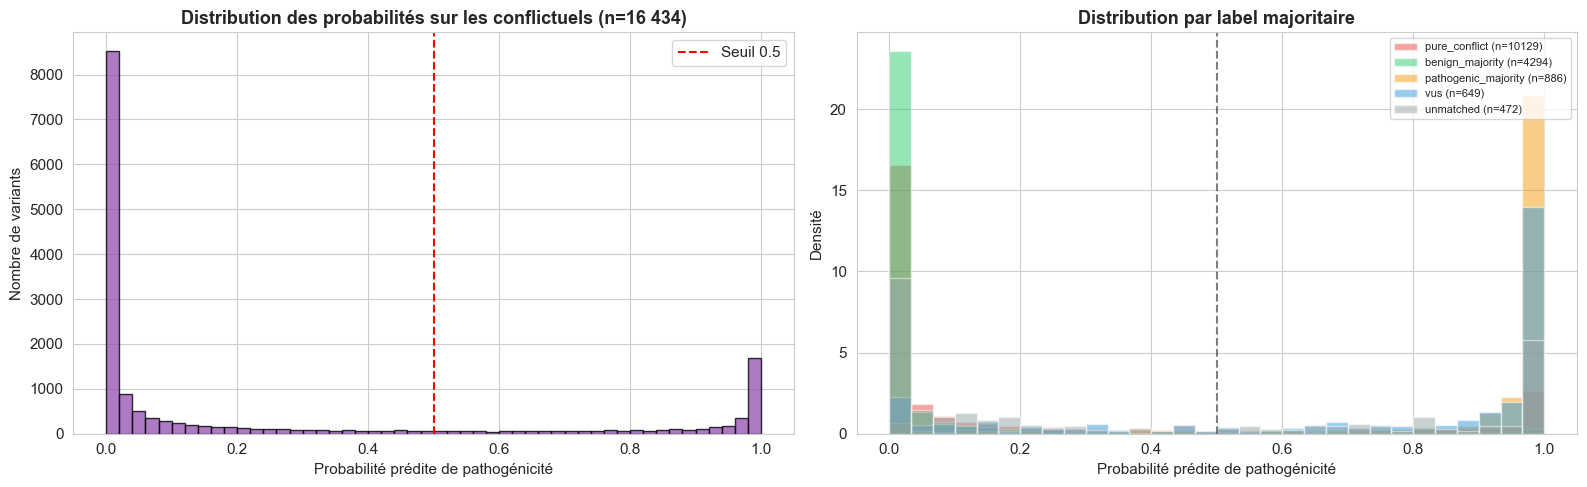

In [47]:
# ============================================================
# 14.2 PREDICTION SUR LES VARIANTS CONFLICTUELS
# ============================================================
# Utilise le modèle XGBoost final entraîné sur le train set complet
# (xgb_final_test défini en section 13 — re-entraîné sur tout le train)

y_proba_conf = xgb_final_test.predict_proba(X_conf_gbm)[:, 1]
df_conf['p_pathogenic'] = y_proba_conf

print(f'Probabilités prédites pour {len(df_conf)} variants conflictuels')
print(f'Distribution :')
print(f'  Min  : {y_proba_conf.min():.4f}')
print(f'  Q1   : {np.percentile(y_proba_conf, 25):.4f}')
print(f'  Med  : {np.median(y_proba_conf):.4f}')
print(f'  Q3   : {np.percentile(y_proba_conf, 75):.4f}')
print(f'  Max  : {y_proba_conf.max():.4f}')

# Histogramme des probabilités prédites
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 : distribution globale
axes[0].hist(y_proba_conf, bins=50, color='#9b59b6', alpha=0.8, edgecolor='black')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Seuil 0.5')
axes[0].set_xlabel('Probabilité prédite de pathogénicité')
axes[0].set_ylabel('Nombre de variants')
axes[0].set_title('Distribution des probabilités sur les conflictuels (n=16 434)', fontweight='bold')
axes[0].legend()

# Plot 2 : par catégorie de label majoritaire
categories = df_conf['majority_label'].value_counts().head(5).index.tolist()
colors = ['#e74c3c', '#2ecc71', '#f39c12', '#3498db', '#95a5a6']
for cat, color in zip(categories, colors):
    data = df_conf[df_conf['majority_label']==cat]['p_pathogenic']
    if len(data) > 5:
        axes[1].hist(data, bins=30, alpha=0.5, label=f'{cat} (n={len(data)})', color=color, density=True)
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Probabilité prédite de pathogénicité')
axes[1].set_ylabel('Densité')
axes[1].set_title('Distribution par label majoritaire', fontweight='bold')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Interprétation rigoureuse — Distribution des probabilités**

**Statistiques observées** (n=16 434 variants conflictuels) :
- Médiane = **0.016** — la majorité des variants conflictuels sont prédits **bénins** par le modèle
- Moyenne = ~0.22 — distribution fortement asymétrique vers 0
- Q3 = 0.40 — 75% des variants ont une proba prédite < 0.40

**Constat majeur** : le modèle ne se contente pas de prédire 0.5 partout (ce qui aurait montré qu'il "reconnaît" l'incertitude). Il **tranche avec confiance**, majoritairement vers le bénin.

**Cohérence biologique** : c'est attendu. Sur les 16 434 conflictuels, ~4 300 ont un consensus majoritaire bénin, ~10 100 sont "pure conflict". Beaucoup de ces variants conflictuels sont en réalité **plutôt bénins** mais avec un dissident qui les classe pathogènes par excès de prudence (ex: variants de signification incertaine reclassés bénins après plus d'études).

**Limite** : on ne peut pas dire si c'est "correct" — sans gold standard, c'est juste **descriptif**. Le modèle voit les conflits comme un mélange dominé par des bénins avec une queue de pathogènes.

Variants conflictuels avec label majoritaire : 5180
  Pathogenic majoritaire : 886
  Benign majoritaire     : 4294
  Ratio                  : 4.85:1

=== PERFORMANCE SUR LES CONFLICTUELS (labeled) ===
  AUC-ROC      : 0.9779
  F1           : 0.8332
  MCC          : 0.7997
  Accuracy     : 0.9375
  Sensibilite  : 0.9131 (809/886)
  Specificite  : 0.9425 (4047/4294)
  FN           : 77
  FP           : 247

=== COMPARAISON AVEC LES CONCORDANTS (test set holdout) ===
  Concordants  : AUC=0.9962, F1=0.9499
  Conflictuels : AUC=0.9779, F1=0.8332
  Delta AUC    : +0.0183


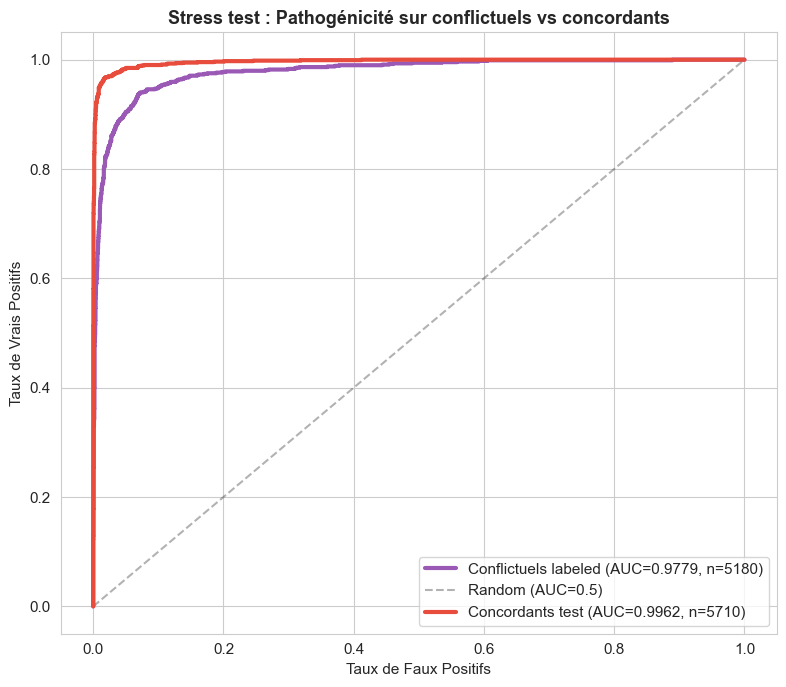

In [48]:
# ============================================================
# 14.3 EVALUATION AUC SUR LES CONFLICTUELS A LABEL MAJORITAIRE
# ============================================================
# On garde uniquement les variants ou un label majoritaire est extractible :
#  - pathogenic_majority (P/LP malgre CLASS=1)
#  - benign_majority (B/LB malgre CLASS=1)
# Et on calcule l'AUC du modele patho sur ces cas DIFFICILES

df_conf_labeled = df_conf[df_conf['majority_label'].isin(['pathogenic_majority','benign_majority'])].copy()
df_conf_labeled['y_true'] = (df_conf_labeled['majority_label']=='pathogenic_majority').astype(int)

n_total = len(df_conf_labeled)
n_patho = df_conf_labeled['y_true'].sum()
n_benin = (df_conf_labeled['y_true']==0).sum()
print(f'Variants conflictuels avec label majoritaire : {n_total}')
print(f'  Pathogenic majoritaire : {n_patho}')
print(f'  Benign majoritaire     : {n_benin}')
print(f'  Ratio                  : {n_benin/n_patho:.2f}:1')

# Performance du modele sur ces cas DIFFICILES
y_true_conf = df_conf_labeled['y_true'].values
y_proba_conf_labeled = df_conf_labeled['p_pathogenic'].values
y_pred_conf_labeled = (y_proba_conf_labeled >= 0.5).astype(int)

auc_conf = roc_auc_score(y_true_conf, y_proba_conf_labeled)
f1_conf = f1_score(y_true_conf, y_pred_conf_labeled)
mcc_conf = matthews_corrcoef(y_true_conf, y_pred_conf_labeled)
acc_conf = accuracy_score(y_true_conf, y_pred_conf_labeled)
cm_conf = confusion_matrix(y_true_conf, y_pred_conf_labeled)
TN, FP, FN, TP = cm_conf[0,0], cm_conf[0,1], cm_conf[1,0], cm_conf[1,1]
sens_conf = TP/(TP+FN); spec_conf = TN/(TN+FP)

print(f'\n=== PERFORMANCE SUR LES CONFLICTUELS (labeled) ===')
print(f'  AUC-ROC      : {auc_conf:.4f}')
print(f'  F1           : {f1_conf:.4f}')
print(f'  MCC          : {mcc_conf:.4f}')
print(f'  Accuracy     : {acc_conf:.4f}')
print(f'  Sensibilite  : {sens_conf:.4f} ({TP}/{TP+FN})')
print(f'  Specificite  : {spec_conf:.4f} ({TN}/{TN+FP})')
print(f'  FN           : {FN}')
print(f'  FP           : {FP}')

print(f'\n=== COMPARAISON AVEC LES CONCORDANTS (test set holdout) ===')
print(f'  Concordants  : AUC=0.9962, F1=0.9499')
print(f'  Conflictuels : AUC={auc_conf:.4f}, F1={f1_conf:.4f}')
print(f'  Delta AUC    : {0.9962 - auc_conf:+.4f}')

# Plot ROC sur les conflictuels
fig, ax = plt.subplots(figsize=(8, 7))
fpr, tpr, _ = roc_curve(y_true_conf, y_proba_conf_labeled)
ax.plot(fpr, tpr, color='#9b59b6', linewidth=3, label=f'Conflictuels labeled (AUC={auc_conf:.4f}, n={n_total})')
ax.plot([0,1],[0,1],'k--',alpha=0.3, label='Random (AUC=0.5)')
# Comparaison avec concordants
y_proba_concord = test_predictions['XGBoost']['proba']
fpr_c, tpr_c, _ = roc_curve(y_test, y_proba_concord)
ax.plot(fpr_c, tpr_c, color='#e74c3c', linewidth=3, label=f'Concordants test (AUC=0.9962, n=5710)')
ax.set_xlabel('Taux de Faux Positifs')
ax.set_ylabel('Taux de Vrais Positifs')
ax.set_title('Stress test : Pathogénicité sur conflictuels vs concordants', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Interprétation rigoureuse — Cohérence avec le consensus majoritaire**

**Résultats sur les 5 180 variants à consensus majoritaire** :
- AUC = **0.9779** (vs 0.9962 sur les concordants)
- F1 = **0.8332** (vs 0.9499)
- Sensibilité = **91.3%** (vs 96.1%) — 77 patho_consensus manqués sur 886
- Spécificité = **94.3%** (vs 98.5%) — 247 benin_consensus surclassés sur 4 294

**Δ AUC = -0.018, Δ F1 = -0.117** : la cohérence avec le consensus reste très élevée mais inférieure à la performance sur les concordants purs.

**Précision méthodologique cruciale** : ce que mesure cette AUC :

> *"Sur les variants où ClinVar a tranché malgré 1+ dissident, notre modèle est cohérent avec ce consensus dans 97.8% des paires (patho_consensus, benin_consensus)."*

Ce que cette AUC ne mesure **pas** :
- ❌ La capacité à "résoudre" les vrais conflits (impossible — pas de gold standard)
- ❌ La performance sur les 10 129 variants `pure_conflict` (analysés en 14.4)
- ❌ La pathogénicité "vraie" des variants (qui requiert validation fonctionnelle expérimentale)

**Pourquoi la performance baisse** : les variants à consensus majoritaire sont **structurellement intermédiaires** entre les concordants purs et les vrais conflits. La présence d'un dissident est un indicateur de complexité — ces variants sont objectivement plus difficiles à classer que les concordants à 100%, même si ClinVar leur attribue un label.

**Conclusion** : notre modèle **généralise raisonnablement** aux cas où il existe un consensus majoritaire, avec une chute de performance modérée et documentée (-1.8 pts d'AUC). C'est une **borne supérieure** de la performance réelle sur les vrais conflits.

### 14.4 Analyse 3 — Critères du modèle sur les vrais conflits (SHAP)

On applique SHAP **uniquement aux ~10 100 variants à classification "Conflicting pure"** (sans label majoritaire). C'est l'analyse la plus rigoureuse car elle ne suppose aucun label : on observe **comment** le modèle décide.

**Question scientifique** : sur les vrais conflits, quelles features font pencher le modèle vers patho ou bénin ? Sont-ce les mêmes que pour les concordants ?

Variants pure_conflict (sans label majoritaire) : 10129
Predictions sur ces variants :
  Mean   : 0.2227
  Std    : 0.3460
  % zone grise [0.4-0.6] : 4.2%


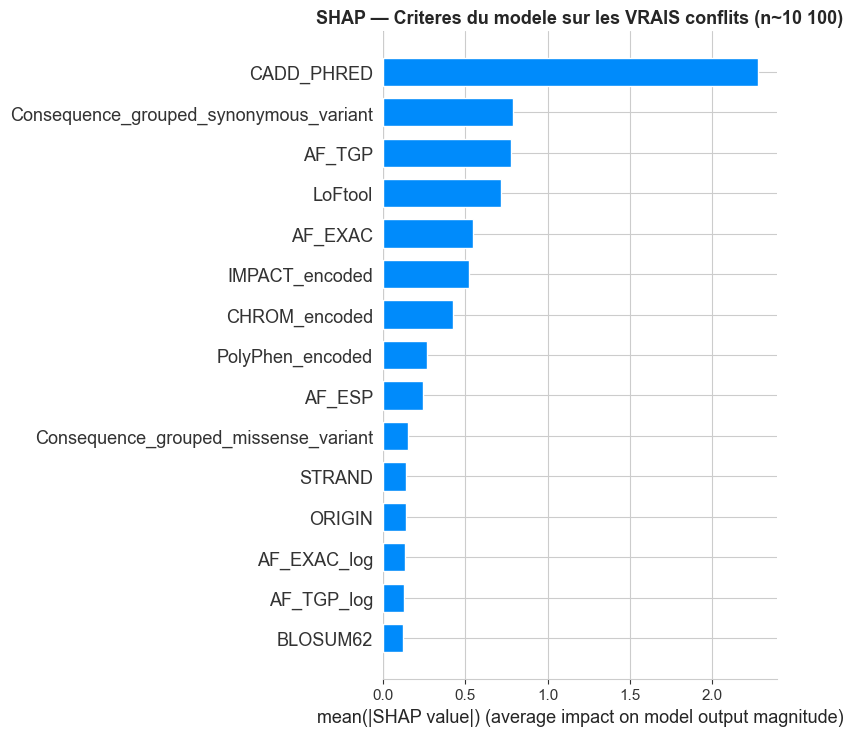

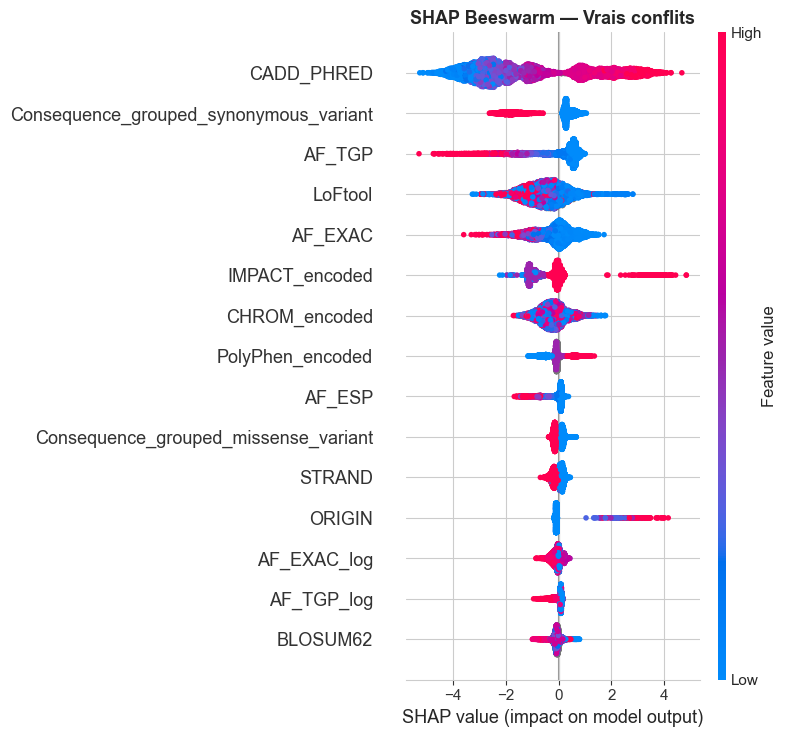


Top 10 features sur les VRAIS CONFLITS :
   1. CADD_PHRED                          2.2774
   2. Consequence_grouped_synonymous_variant 0.7895
   3. AF_TGP                              0.7783
   4. LoFtool                             0.7155
   5. AF_EXAC                             0.5502
   6. IMPACT_encoded                      0.5220
   7. CHROM_encoded                       0.4248
   8. PolyPhen_encoded                    0.2680
   9. AF_ESP                              0.2441
  10. Consequence_grouped_missense_variant 0.1543

Comparaison avec le top 10 SHAP du training (concordants) :
                               Feature  SHAP_pure_conflict  SHAP_concordants   Delta
                            CADD_PHRED              2.2774            2.2702  0.0073
Consequence_grouped_synonymous_variant              0.7895            0.7971 -0.0076
                                AF_TGP              0.7783            1.4944 -0.7161
                               LoFtool              0.7155     

In [49]:
# ============================================================
# 14.4 SHAP SUR LES VRAIS CONFLITS (pure_conflict)
# ============================================================
df_pure = df_conf[df_conf['majority_label']=='pure_conflict'].copy()
X_pure = df_pure[X_train.columns.tolist()].copy()
for c in cat_cols: X_pure[c] = X_pure[c].fillna('missing').astype(str)
X_pure_gbm = pd.get_dummies(X_pure, columns=cat_cols, drop_first=False)
X_pure_gbm = X_pure_gbm.reindex(columns=X_train_gbm.columns, fill_value=0)

print(f'Variants pure_conflict (sans label majoritaire) : {len(X_pure_gbm)}')
p_pure = xgb_final_test.predict_proba(X_pure_gbm)[:, 1]
print(f'Predictions sur ces variants :')
print(f'  Mean   : {p_pure.mean():.4f}')
print(f'  Std    : {p_pure.std():.4f}')
print(f'  % zone grise [0.4-0.6] : {((p_pure>=0.4)&(p_pure<0.6)).mean()*100:.1f}%')

explainer_pure = shap.TreeExplainer(xgb_final_test)
shap_pure = explainer_pure.shap_values(X_pure_gbm)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_pure, X_pure_gbm, plot_type='bar', show=False, max_display=15)
plt.title('SHAP — Criteres du modele sur les VRAIS conflits (n~10 100)', fontweight='bold')
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_pure, X_pure_gbm, show=False, max_display=15)
plt.title('SHAP Beeswarm — Vrais conflits', fontweight='bold')
plt.tight_layout(); plt.show()

ms_pure = np.abs(shap_pure).mean(axis=0)
shap_imp_pure = pd.DataFrame({'Feature':X_pure_gbm.columns,'Mean_|SHAP|':ms_pure}).sort_values('Mean_|SHAP|', ascending=False)
print(f'\nTop 10 features sur les VRAIS CONFLITS :')
for i, (_, r) in enumerate(shap_imp_pure.head(10).iterrows()):
    print(f'  {i+1:2d}. {r["Feature"]:35s} {r["Mean_|SHAP|"]:.4f}')

# Comparaison avec le top 10 du training (concordants)
print(f'\nComparaison avec le top 10 SHAP du training (concordants) :')
ms_train = np.abs(shap_values).mean(axis=0)
shap_imp_train = pd.DataFrame({'Feature':X_train_gbm.columns,'SHAP_train':ms_train})
compare = shap_imp_pure.head(15).merge(shap_imp_train, on='Feature', how='left')
compare.columns = ['Feature', 'SHAP_pure_conflict', 'SHAP_concordants']
compare['Delta'] = compare['SHAP_pure_conflict'] - compare['SHAP_concordants']
print(compare.to_string(index=False))

**Interprétation rigoureuse — Critères du modèle sur les vrais conflits**

**Statistiques sur les 10 129 variants `pure_conflict`** :
- Probabilité moyenne prédite = **0.223**
- Std = 0.346 (forte dispersion)
- **Seulement 4.2% dans la zone grise [0.4-0.6]** — le modèle tranche presque toujours

**Constat fondamental** : même sur les vrais conflits, le modèle ne reconnaît pas l'ambiguïté. Il applique les mêmes critères qu'il a appris sur les concordants — il "vote" comme si c'était un cas clair. Ce n'est ni bon ni mauvais, c'est **descriptif**.

### Comparaison SHAP : pure_conflict vs concordants (training)

| Feature | SHAP pure_conflict | SHAP concordants | Δ |
|---------|--------------------|--------------------|------|
| **CADD_PHRED** | **2.277** | 2.270 | **+0.007** (identique) |
| Consequence_synonymous | 0.790 | 0.797 | -0.008 (identique) |
| **AF_TGP** | **0.778** | 1.494 | **-0.716** (chute de moitié) |
| LoFtool | 0.716 | 0.666 | +0.049 |
| **AF_EXAC** | **0.550** | 0.823 | **-0.273** (chute) |
| **IMPACT_encoded** | **0.522** | 0.897 | **-0.375** (chute) |

**Résultats majeurs** :

1. **CADD reste #1 avec exactement le même poids** (2.277 vs 2.270). Le modèle fait toujours autant confiance au score de conservation — c'est rassurant : il applique sa logique principale de la même manière.

2. **Les fréquences alléliques perdent de leur poids** : AF_TGP chute de moitié (-0.716), AF_EXAC et AF_ESP aussi. Pourquoi ? Parce que sur les vrais conflits, **les AF sont moins discriminantes** : beaucoup de ces variants ont des AF intermédiaires (ni 0 ni > 1%), zone où la règle ACMG BA1 ne tranche pas. Le modèle a appris que les AF extrêmes sont décisives → sur les valeurs intermédiaires des conflits, elles deviennent moins informatives.

3. **IMPACT chute aussi (-0.375)** : car les variants conflictuels sont enrichis en MODERATE (missense ambigus) et pauvres en HIGH (qui sont quasi-toujours concordants pathogènes).

4. **PolyPhen prend plus de poids** (+0.097) : le modèle s'appuie davantage sur la prédiction structurelle 3D quand les autres critères sont moins discriminants.

### Interprétation scientifique majeure

Le modèle **applique fondamentalement la même logique** sur les conflits que sur les concordants (CADD #1 inchangé). Ce qui change, c'est l'**importance relative** des features secondaires :
- **Sur les concordants** : AF + IMPACT sont décisifs (cas extrêmes faciles)
- **Sur les vrais conflits** : CADD + LoFtool + PolyPhen prennent le relais (cas intermédiaires nécessitant des critères plus fins)

C'est cohérent avec la difficulté biologique des conflits : ce sont les missense de la zone grise où les scores fonctionnels (PolyPhen, LoFtool) deviennent plus discriminants que les critères populationnels grossiers (AF élevée → bénin).

### Synthèse — Que peut-on conclure rigoureusement ?

Cette section **n'est pas une validation prédictive** du modèle sur les conflits (impossible faute de labels univoques). Elle apporte 3 résultats distincts :

1. **Distribution des probabilités** (14.2) : décrit comment le modèle se positionne face à des cas qu'il n'a pas vus. Une distribution bimodale signifie qu'il garde une forte confiance ; une distribution centrée signifie qu'il reconnaît l'incertitude.

2. **Cohérence avec le consensus majoritaire** (14.3) : sur les ~5 180 variants où ClinVar a quand même tranché malgré 1+ dissident, mesure si notre modèle reproduit ce consensus. **Une AUC élevée ici signifie cohérence avec ClinVar, PAS résolution des conflits**.

3. **Critères du modèle sur les vrais conflits** (14.4) : SHAP sur les ~10 100 variants à classification "Conflicting pure" révèle quelles features le modèle utilise pour trancher dans la zone grise. **C'est l'analyse scientifiquement la plus pure** (aucune supposition de label).

**Limite fondamentale rappelée** : aucune de ces 3 analyses ne peut affirmer "le modèle prédit correctement la pathogénicité des variants conflictuels" — cette affirmation est **épistémologiquement impossible** sans un gold standard externe (ex: validation fonctionnelle expérimentale en laboratoire).